In [77]:
import eos
import os
import numpy as np
import matplotlib.pyplot as plt
from wquantiles import quantile_1D
import ast
import cmath

colors = eos.figure.ItemColorCycler()._colors

resample = False

In [78]:
BASE_DIRECTORY = os.getcwd()
if not os.path.exists(BASE_DIRECTORY):
    os.makedirs(os.path.abspath(BASE_DIRECTORY), exist_ok=True)

In [79]:
def wstd(samples, weights=None, axis=0):
    mean_w = np.average(samples, weights=weights, axis=axis)
    return np.sqrt(np.average((samples - mean_w)**2, weights=weights, axis=axis))

def get_gof(analysis, param_array):
    parameter_list = []

    for param in analysis.init_args['priors']:
        if param['type'] == 'transform':
            parameter_list += param['parameters']
        else:
            parameter_list.append(param['parameter'])

    for i, param in enumerate(parameter_list):
        analysis.parameters.set(param, param_array[i])

    return analysis.goodness_of_fit()

In [80]:
colors = eos.figure.ItemColorCycler()._colors

experiment_colors = {
    "Belle": colors[0],
    "CLEO": colors[1],
    "ALEPH": colors[2],
    "OPAL": colors[4],
}

EXPERIMENTS = tuple(experiment_colors)

fit_results = {}

In [81]:
def prepare_fit(order, experiment, resample, refit=False):
    posterior = f"FF-fp-I1-order{order}-{experiment}"
    analysis = af.analysis(posterior)

    fit_directory = os.path.join(
        BASE_DIRECTORY, "data", posterior
    )

    # Generate new samples only when requested.
    if resample:
        eos.tasks.sample_nested(
            af,
            posterior,
            base_directory=BASE_DIRECTORY,
            bound="multi",
            nlive=200,
        )

    f = eos.data.ImportanceSamples(
        os.path.join(fit_directory, "samples")
    )

    mode_path = os.path.join(fit_directory, "mode-default")

    # Refit when requested, after resampling, or if no mode is saved.
    if refit or resample or not os.path.exists(mode_path):
        bfp, gof = eos.tasks.find_mode(
            af,
            posterior,
            importance_samples=True,
            base_directory=BASE_DIRECTORY,
            optimizations=100,
        )
    else:
        mode = eos.data.Mode(mode_path)
        gof = get_gof(analysis, mode.mode)
        bfp = eos.BestFitPoint(analysis, mode.mode)

    return {
        "posterior": posterior,
        "analysis": analysis,
        "f": f,
        "bfp": bfp,
        "gof": gof,
    }

In [82]:
def show_fit_rotation(result):
    fit = result["f"]
    samples = fit.samples
    weights = fit.weights
    size = samples.shape[1]

    parameter_names = [
        parameter.name()
        for parameter in result["analysis"].varied_parameters
    ]

    cov = np.atleast_2d(
        np.cov(samples, rowvar=False, aweights=weights)
    )

    if not np.isfinite(cov).all():
        raise ValueError("The weighted covariance contains non-finite values.")

    try:
        chol = np.linalg.cholesky(np.linalg.inv(cov))
    except np.linalg.LinAlgError as error:
        raise ValueError(
            "Cannot compute the rotation: the covariance must be "
            "positive definite. Check for constant or linearly dependent "
            "parameters, or too few independent samples."
        ) from error

    corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))

    # Same uncentred transformation as in your original code.
    decorrelated_samples = samples @ chol

    # For column vectors: original_parameters = transform @ z.
    # This is equivalent to np.linalg.inv(chol.T).
    transform = np.linalg.solve(chol.T, np.eye(size))

    means = np.average(
        decorrelated_samples, weights=weights, axis=0
    )
    stds = wstd(
        decorrelated_samples, weights=weights, axis=0
    )

    decorrelated_min = means - 5 * stds
    decorrelated_max = means + 5 * stds

    decorrelated_bfp = np.asarray(result["bfp"].point) @ chol

    print(f"{result['posterior']}: rotation diagnostics")
    print("Original parameter order:")
    for index, name in enumerate(parameter_names, start=1):
        print(f"p{index}: {name}")

    # Correlation matrix in the original basis.
    correlation_figure, ax = plt.subplots(figsize=(6, 5))

    image = ax.imshow(
        corr,
        vmin=-1,
        vmax=1,
        cmap="coolwarm",
    )

    labels = [f"p{i + 1}" for i in range(size)]
    ax.set_xticks(range(size), labels=labels)
    ax.set_yticks(range(size), labels=labels)
    ax.set_title("Weighted correlation matrix")

    correlation_figure.colorbar(image, ax=ax)
    correlation_figure.tight_layout()
    plt.show()

    print("Transformation back to original parameters:")
    display(transform)

    print("Shift: zero, matching your original convention.")
    print("Lower bounds in transformed coordinates:")
    display(decorrelated_min)

    print("Upper bounds in transformed coordinates:")
    display(decorrelated_max)

    print("Best-fit point in transformed coordinates:")
    display(decorrelated_bfp)

    # Prepare the bin edges once for each transformed coordinate.
    bins = [
        np.linspace(lower, upper, 100)
        for lower, upper in zip(decorrelated_min, decorrelated_max)
    ]

    corner_figure, axes = plt.subplots(
        size,
        size,
        figsize=(3.0 * size, 3.0 * size),
        dpi=100,
        squeeze=False,
    )

    for i in range(size):
        for j in range(size):
            ax = axes[i, j]

            if j < i:
                ax.set_axis_off()
                continue

            if i == j:
                ax.hist(
                    decorrelated_samples[:, i],
                    weights=weights,
                    bins=bins[i],
                    density=True,
                    alpha=0.5,
                    color="C1",
                )
            else:
                ax.hist2d(
                    decorrelated_samples[:, j],
                    decorrelated_samples[:, i],
                    weights=weights,
                    bins=[bins[j], bins[i]],
                    cmap="Greys",
                    rasterized=True,
                )

                ax.plot(
                    decorrelated_bfp[j],
                    decorrelated_bfp[i],
                    marker="*",
                    linestyle="none",
                    markersize=12,
                    color="tab:red",
                )

                ax.set_ylim(decorrelated_min[i], decorrelated_max[i])
                ax.set_ylabel(rf"$z_{{{i + 1}}}$")

            ax.set_xlim(decorrelated_min[j], decorrelated_max[j])
            ax.set_xlabel(rf"$z_{{{j + 1}}}$")
            ax.set_box_aspect(1)

    corner_figure.tight_layout()
    plt.show()

    result["rotation"] = {
        "parameters": parameter_names,
        "covariance": cov,
        "correlation": corr,
        "chol": chol,
        "transform": transform,
        "shift": np.zeros(size),
        "samples": decorrelated_samples,
        "min": decorrelated_min,
        "max": decorrelated_max,
        "bfp": decorrelated_bfp,
        "figures": {
            "correlation": correlation_figure,
            "corner": corner_figure,
        },
    }

    return result["rotation"]

In [83]:
def show_fit(result, rotate=False):
    posterior = result["posterior"]
    analysis = result["analysis"]
    fit = result["f"]

    print(posterior)
    print(f"Collected {len(fit.samples)} samples")

    display(result["gof"])
    display(result["bfp"].point)

    means = np.average(
        fit.samples, weights=fit.weights, axis=0
    )
    stds = wstd(
        fit.samples, weights=fit.weights, axis=0
    )

    for parameter, mean, std in zip(
        analysis.varied_parameters, means, stds
    ):
        print(
            f"      - {{ 'parameter': '{parameter.name()}', "
            f"'min': {mean - 5*std:.5f}, "
            f"'max': {mean + 5*std:.5f}, "
            f"'type': 'uniform'}}"
        )

    eos.tasks.corner_plot(
        af,
        posterior,
        base_directory=BASE_DIRECTORY,
    )
    plt.show()

    if rotate:
        show_fit_rotation(result)

In [84]:
def show_dispersive_bound(order, recompute=False):
    prediction_name = "FF-fp-I1-dispersive-bound"

    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        posterior = result["posterior"]

        prediction_path = os.path.join(
            BASE_DIRECTORY,
            "data",
            posterior,
            f"pred-{prediction_name}",
        )

        # Compute missing predictions or update them when requested.
        if recompute or not os.path.exists(prediction_path):
            eos.tasks.predict_observables(
                af,
                posterior,
                prediction_name,
                base_directory=BASE_DIRECTORY,
            )

        preds = eos.data.Prediction(prediction_path)
        values = preds.samples[:, 0]

        mean = np.average(values, weights=preds.weights)
        std = wstd(values, weights=preds.weights)

        result["dispersive_bound"] = {
            "prediction": preds,
            "values": values,
            "mean": mean,
            "std": std,
        }

        print(
            f"{experiment} dispersive bound is "
            f"{mean:.4f} ± {std:.4f}"
        )

In [85]:
def plot_dispersive_bound_histogram(order, bins):
    figure, ax = plt.subplots(figsize=(8, 5))

    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]["dispersive_bound"]

        ax.hist(
            result["values"],
            weights=result["prediction"].weights,
            bins=bins,
            histtype="step",
            linewidth=2,
            color=experiment_colors[experiment],
            label=experiment,
        )

    ax.set_xlabel("Dispersive bound")
    ax.set_ylabel("Sum of weights")
    ax.legend()

    figure.tight_layout()
    plt.show()

    return figure

In [86]:
def get_ff_data_item(result, experiment):
    analysis = result["analysis"]

    constraint_names = list(analysis.init_args["likelihood"])
    constraint_names.extend(
        (analysis.init_args.get("manual_constraints") or {}).keys()
    )

    prefix = f"0->pipi::Abs{{f_+}}^2@{experiment}:"

    matches = sorted({
        str(name)
        for name in constraint_names
        if str(name).startswith(prefix)
    })

    if len(matches) != 1:
        raise ValueError(
            f"{experiment}: expected one constraint starting with "
            f"{prefix!r}, but found {matches}."
        )

    constraint_name = matches[0]
    entry = eos.Constraints()[constraint_name]

    observable_names = sorted({
        str(name)
        for name in entry.observables()
        if str(name).startswith("0->pipi::Abs{f_+}^2(")
    })

    if len(observable_names) != 1:
        raise ValueError(
            f"{constraint_name}: expected one form-factor observable, "
            f"but found {observable_names}."
        )

    year = constraint_name.split("@", 1)[1].split(":", 1)[1][:4]

    return {
        "type": "constraint",
        "label": f"{experiment} {year}",
        "color": experiment_colors[experiment],
        "variable": "q2",
        "observable": observable_names[0],
        "constraints": constraint_name,
    }

In [87]:
def plot_form_factor_squared(order, experiment, recompute=False):
    result = fit_results[order][experiment]
    posterior = result["posterior"]

    data_item = get_ff_data_item(result, experiment)

    prediction_name = "FF-fp2-I1-all"
    prediction_path = os.path.join(
        BASE_DIRECTORY,
        "data",
        posterior,
        f"pred-{prediction_name}",
    )

    # Both plots use this same prediction file.
    if recompute or not os.path.exists(prediction_path):
        eos.tasks.predict_observables(
            af,
            posterior,
            prediction_name,
            base_directory=BASE_DIRECTORY,
        )

    prediction_item = {
        "type": "uncertainty",
        "label": f"N = {order} fit",
        "color": colors[5],
        "variable": "q2",
        "range": [-1.2, 2.0],
        "interpolation": "cubic",
        "datafile": prediction_path,
        "resolution": 300,
    }

    na7_item = {
        "type": "constraint",
        "label": "NA7 1986",
        "color": colors[3],
        "variable": "q2",
        "observable": "0->pipi::Abs{f_+}^2(q2)",
        "constraints": "0->pipi::Abs{f_+}^2@NA7:1986A",
    }

    views = {
        "full": {
            "xrange": [-1.2, 2.0],
            "yrange": [0.1, 100.0],
            "watermark": "lower right",
            "legend": "upper left",
        },
        "zoom": {
            "xrange": [0.4, 0.8],
            "yrange": [10.0, 60.0],
            "watermark": "upper right",
            "legend": "lower center",
        },
    }

    figures = {}

    for view_name, settings in views.items():
        items = [data_item.copy()]

        if view_name == "full":
            items.append(na7_item.copy())

        items.append(prediction_item.copy())

        if view_name == "full":
            # Shade the entire plot height above sIn.
            items.append({
                "type": "band",
                "color": "gray",
                "alpha": 0.25,
                "x": [sIn, 2.0],
            })

        figure_args = {
            "watermark": {
                "position": settings["watermark"],
            },
            "plot": {
                "xaxis": {
                    "label": r"$s$",
                    "unit": r"$\mathrm{GeV}^2$",
                    "range": settings["xrange"],
                },
                "yaxis": {
                    "label": r"$|F^{I=1}_\pi|^2$",
                    "range": settings["yrange"],
                    "scale": "log",
                },
                "legend": {
                    "position": settings["legend"],
                },
                "items": items,
            },
        }

        print(f"{experiment}, order {order}: {view_name}")

        figure = eos.figure.FigureFactory.from_dict(**figure_args)
        figure.draw()
        plt.show()

        figures[view_name] = figure

    result["form_factor_squared"] = {
        "prediction_path": prediction_path,
        "figures": figures,
    }

    return figures

In [88]:
def plot_form_factor_residuals(order, experiment):
    result = fit_results[order][experiment]
    analysis = result["analysis"]

    # Copy all parameter values, including fixed parameters.
    param_dict = {
        parameter.name(): parameter.evaluate()
        for parameter in analysis.parameters
    }

    # Insert the saved best-fit values of the varied parameters.
    # This does not require another goodness-of-fit calculation.
    for parameter, value in zip(
        analysis.varied_parameters,
        result["bfp"].point,
    ):
        param_dict[parameter.name()] = float(value)

    # Use the model options from this fit.
    fit_options = dict(
        analysis.init_args.get("global_options") or {}
    )
    fit_options.setdefault("form-factors", "BHKMNR2026")

    # Reuse the constraint lookup from the previous plotting block.
    residual_item = get_ff_data_item(result, experiment)

    residual_item.update({
        "type": "constraint-residue",
        "parameters": param_dict,
        "options": fit_options,
        "style": "delta",
    })

    figure_args = {
        "watermark": {"position": "lower right"},
        "plot": {
            "xaxis": {
                "label": r"$s$",
                "unit": r"$\mathrm{GeV}^2$",
                "range": [0.2, sIn],
            },
            "yaxis": {
                "label": (
                    r"$|F_\pi|^2_{\mathrm{data}}"
                    r" - |F_\pi|^2_{\mathrm{fit}}$"
                ),
                "range": [-1.5, 2.0],
                "scale": "linear",
            },
            "legend": {"position": "upper left"},
            "items": [residual_item],
        },
    }

    print(f"{experiment}, order {order}: residuals at the BFP")

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    plt.show()

    result["form_factor_residuals"] = figure

    return figure

In [89]:
def plot_psi_phase(order, experiment, resolution=200):
    result = fit_results[order][experiment]
    analysis = result["analysis"]

    # Copy all parameters, including fixed parameters.
    param_dict = {
        parameter.name(): parameter.evaluate()
        for parameter in analysis.parameters
    }

    # Insert the saved best-fit values.
    for parameter, value in zip(
        analysis.varied_parameters,
        result["bfp"].point,
    ):
        param_dict[parameter.name()] = float(value)

    fit_options = dict(
        analysis.init_args.get("global_options") or {}
    )
    fit_options.setdefault("form-factors", "BHKMNR2026")

    figure_args = {
        "plot": {
            "xaxis": {
                "label": r"$\mathrm{Re}(\psi)$",
                "range": [-1.1, 1.1],
            },
            "yaxis": {
                "label": r"$\mathrm{Im}(\psi)$",
                "range": [-1.1, 1.1],
            },
            "items": [
                {
                    "type": "complex-plane",
                    "ranges": (
                        (-1.1, 1.1),
                        (-1.1, 1.1),
                    ),
                    "variables": ["Re{psi}", "Im{psi}"],
                    "observable": (
                        "0->pipi::Arg{f_+}(Re{psi},Im{psi})"
                        "@BHKMNR2026"
                    ),
                    "fixed_parameters": param_dict,
                    "options": fit_options,
                    "resolution": resolution,
                },
            ],
        },
    }

    print(f"{experiment}, order {order}: phase in the psi plane")

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()

    ax = figure._ax

    # Apply the same phase color scale to every experiment.
    for artist in list(ax.images) + list(ax.collections):
        artist.set_cmap("hsv")
        artist.set_clim(-np.pi, np.pi)

    # Draw the unit circle.
    circle = plt.Circle(
        (0, 0),
        1.0,
        color="black",
        fill=False,
        linewidth=1.5,
        zorder=10,
    )
    ax.add_patch(circle)

    ax.set_aspect("equal", adjustable="box")

    plt.show()

    result["psi_phase"] = figure

    return figure

In [90]:
def plot_timelike_phase(order, recompute=False):
    prediction_name = "FF-arg-fp-I1-timelike"

    # Load the CHS comparison data.
    q2_over_mpisquared, phase, err = np.loadtxt(
        os.path.join(BASE_DIRECTORY, "scripts", "d11-central.txt"),
        skiprows=1,
        unpack=True,
    )
    q2 = q2_over_mpisquared * mpi**2

    items = []

    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        posterior = result["posterior"]

        prediction_path = os.path.join(
            BASE_DIRECTORY,
            "data",
            posterior,
            f"pred-{prediction_name}",
        )

        # Reuse saved predictions unless recomputation is requested.
        if recompute or not os.path.exists(prediction_path):
            eos.tasks.predict_observables(
                af,
                posterior,
                prediction_name,
                base_directory=BASE_DIRECTORY,
            )

        items.append({
            "type": "uncertainty",
            "label": experiment,
            "color": experiment_colors[experiment],
            "interpolation": "cubic",
            "resolution": 250,
            "variable": "q2",
            "datafile": prediction_path,
        })

    items.extend([
        {
            "type": "band",
            "color": "gray",
            "alpha": 0.25,
            "x": [sIn, 2.5],
            "y": [0.0, 3.5],
        },
        {
            "type": "expression",
            "expression": "np.pi",
            "range": [0.0, 2.5],
            "color": "black",
        },
    ])

    figure_args = {
        "watermark": {"position": "lower right"},
        "plot": {
            "xaxis": {
                "label": r"$s$",
                "unit": r"$\mathrm{GeV}^2$",
                "range": [0.0, 2.5],
            },
            "yaxis": {
                "label": r"$\arg F^{I=1}_\pi$",
                "range": [0.0, 3.5],
            },
            "legend": {"position": "lower center"},
            "items": items,
        },
    }

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    ax = figure._ax

    # Preserve the experiment entries from the EOS legend.
    legend = ax.get_legend()
    handles = list(legend.legend_handles)
    labels = [text.get_text() for text in legend.get_texts()]

    chs_band = ax.fill_between(
        q2,
        phase - err,
        phase + err,
        label="CHS 2018",
        alpha=0.5,
        color=colors[5],
    )

    threshold_line = ax.axvline(
        x=sPlus,
        color="black",
        linestyle=":",
        linewidth=1.0,
        label=r"$s_+$",
    )

    ax.legend(
        handles=handles + [chs_band, threshold_line],
        labels=labels + ["CHS 2018", r"$s_+$"],
        loc="lower center",
    )

    plt.show()
    return figure

In [91]:
mpi    = eos.Parameters()["mass::pi^+"].evaluate()
sPlus  = 4 * mpi**2
sMinus = 0.0
sIn    = 0.850509 #pi-omega threshold

In [92]:
def a11_calculator(sl_params):
    r2, r3, _, _ = sl_params

    coefficient = (
        -0.36294823212268046 * r2
        +0.06946304407045559 * r3
    )

    return sPlus * coefficient.real


def b11_calculator(sl_params):
    r2, r3, r4, r5 = sl_params

    coefficient = (
         0.03311321577857029   * r2
        -0.23706596387010614   * r2**2
        -0.14455309077802547   * r3
        +0.04537099795088154   * r2*r3
        +0.07902198795670203   * r4
        -0.00453709979508815   * r5
    )

    return sPlus**2 * coefficient.real

def calculate_sl_values(sl_params):
    samples = np.asarray(sl_params.samples)

    if samples.ndim != 2 or samples.shape[1] != 4:
        raise ValueError(
            "Expected four sample columns in order: r2, r3, r4, r5."
        )

    # Give each calculator the four complete sample columns.
    sample_columns = samples.T

    a11_values = a11_calculator(sample_columns)
    b11_values = b11_calculator(sample_columns)

    return a11_values, b11_values

def summarize_sl_values(name, a11_values, b11_values, weights):
    a11_mean = np.average(a11_values, weights=weights)
    a11_std  = wstd(a11_values, weights=weights)

    b11_mean = np.average(b11_values, weights=weights)
    b11_std  = wstd(b11_values, weights=weights)

    print(f"{name} a11 = {a11_mean:.4f} ± {a11_std:.4f}")
    print(f"{name} b11 = {b11_mean:.4f} ± {b11_std:.4f}")

    return a11_mean, a11_std, b11_mean, b11_std

sl_parameters = eos.Parameters()

a11_parameter = sl_parameters.declare_and_insert(
    'derived::a11',
    r'a_{11}',
    eos.Unit.Unity(),
    0.0,
    -100.0,
    100.0
)

b11_parameter = sl_parameters.declare_and_insert(
    'derived::b11',
    r'b_{11}',
    eos.Unit.Unity(),
    0.0,
    -100.0,
    100.0
)


def save_sl_samples(posterior, a11_values, b11_values, weights):
    sl_values = np.column_stack((
        a11_values,
        b11_values
    ))

    output_path = os.path.join(
        BASE_DIRECTORY,
        'data',
        posterior,
        'scattering-lengths',
        'samples'
    )

    os.makedirs(
        os.path.dirname(output_path),
        exist_ok=True
    )

    eos.data.ImportanceSamples.create(
        output_path,
        [a11_parameter, b11_parameter],
        sl_values,
        weights
    )

    return output_path


def show_scattering_lengths(order, recompute=False):
    prediction_name = "FF-fp-I1-scattering-length-params"

    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        posterior = result["posterior"]

        prediction_path = os.path.join(
            BASE_DIRECTORY,
            "data",
            posterior,
            f"pred-{prediction_name}",
        )

        if recompute or not os.path.exists(prediction_path):
            eos.tasks.predict_observables(
                af,
                posterior,
                prediction_name,
                base_directory=BASE_DIRECTORY,
            )

        sl_params = eos.data.Prediction(prediction_path)

        # Calculate a11 and b11 for every sample before averaging.
        a11_values, b11_values = calculate_sl_values(sl_params)

        a11_mean, a11_std, b11_mean, b11_std = summarize_sl_values(
            experiment,
            a11_values,
            b11_values,
            sl_params.weights,
        )

        # Save paired samples with their original weights.
        samples_path = save_sl_samples(
            posterior,
            a11_values,
            b11_values,
            sl_params.weights,
        )

        result["scattering_lengths"] = {
            "prediction": sl_params,
            "a11_values": a11_values,
            "b11_values": b11_values,
            "a11_mean": a11_mean,
            "a11_std": a11_std,
            "b11_mean": b11_mean,
            "b11_std": b11_std,
            "samples_path": samples_path,
        }

[parameters.declare_and_insert] Parameter 'derived::a11' is already declared, returning existing instance; check your code for conflicting duplicate declarations
[parameters.declare_and_insert] Parameter 'derived::b11' is already declared, returning existing instance; check your code for conflicting duplicate declarations


In [93]:
# Theory a11 and b11 plot
# Sample independent Gaussian literature values (these values are from table 2 of arxiv:hep-ph/013088v1).
rng = np.random.default_rng(42)
n_samples = 2000

a11_theory = rng.normal(0.0379, 0.0005, n_samples)
b11_theory = rng.normal(0.00567, 0.00013, n_samples)

# All sampled curves have equal weight.
theory_weights = np.full(n_samples, 1.0 / n_samples)

# Physical s values, from threshold to 0.2 GeV^2.
s_theory = np.linspace(sPlus, 0.2, 200)
eps = s_theory - sPlus

# Each row is one complete curve from one sampled (a11, b11) pair.
t_theory_samples = eps[None, :] / sPlus * ( a11_theory[:, None] + b11_theory[:, None] * eps[None, :] / sPlus)

# Save the parameter samples, curve samples, grid, and weights.
theory_path = os.path.join(BASE_DIRECTORY, 'data', 'theory', 't11-threshold-samples.npz')
os.makedirs(os.path.dirname(theory_path), exist_ok=True)

np.savez_compressed(theory_path, s=s_theory, a11=a11_theory, b11=b11_theory, t11=t_theory_samples, weights=theory_weights)

with np.load(theory_path) as saved:
    s_theory = saved["s"]
    t_theory_samples = saved["t11"]

# Pointwise central 68.27% band for your equally weighted theory samples.
t_lower, t_median, t_upper = np.quantile(
    t_theory_samples,
    [0.15865, 0.5, 0.84135],
    axis=0,
)

partial_wave_theory = {
    "s": s_theory,
    "lower": t_lower,
    "median": t_median,
    "upper": t_upper,
}

In [94]:
def plot_partial_waves(order, experiment, theory_band, recompute=False):
    result = fit_results[order][experiment]
    posterior = result["posterior"]

    parts = ("real", "imag")
    prediction_paths = {}

    # Prepare the two predictions, shared by all three plots.
    for part in parts:
        prediction_name = f"{part}-partial-wave-I1"

        prediction_path = os.path.join(
            BASE_DIRECTORY,
            "data",
            posterior,
            f"pred-{prediction_name}",
        )

        if recompute or not os.path.exists(prediction_path):
            eos.tasks.predict_observables(
                af,
                posterior,
                prediction_name,
                base_directory=BASE_DIRECTORY,
            )

        prediction_paths[part] = prediction_path

    # Each entry contains: name, x range, y range, interpolation resolution.
    views = [
        ("full", [-2.5, 2.5], [-0.7, 1.1], 250),
        ("near_zero", [-sPlus, 0.1], [-0.5, 0.5], 3000),
        ("threshold", [0.0, 0.2], [-0.15, 0.15], 3000),
    ]

    figures = {}

    for view, x_range, y_range, resolution in views:
        items = [
            {
                "type": "uncertainty",
                "label": f"{part} part",
                "color": colors[index],
                "interpolation": "cubic",
                "resolution": resolution,
                "variable": "q2",
                "range": x_range,
                "datafile": prediction_paths[part],
            }
            for index, part in enumerate(parts)
        ]

        figure_args = {
            "watermark": {"position": "lower right"},
            "plot": {
                "xaxis": {
                    "label": r"$s$",
                    "unit": r"$\mathrm{GeV}^2$",
                    "range": x_range,
                },
                "yaxis": {
                    "label": rf"{experiment} $t_1^1$",
                    "range": y_range,
                },
                "legend": {"position": "upper left"},
                "items": items,
            },
        }

        print(f"{experiment}, order {order}: {view.replace('_', ' ')}")

        figure = eos.figure.FigureFactory.from_dict(**figure_args)
        figure.draw()
        ax = figure._ax

        if view != "full":
            # Preserve the real/imaginary entries from the EOS legend.
            legend = ax.get_legend()
            handles = list(legend.legend_handles)
            labels = [text.get_text() for text in legend.get_texts()]

            # Add the theory comparison only to the threshold plot.
            if view == "threshold":
                theory_handle = ax.fill_between(
                    theory_band["s"],
                    theory_band["lower"],
                    theory_band["upper"],
                    color="red",
                    alpha=0.3,
                    label="CGL 2001",
                )

                ax.plot(
                    theory_band["s"],
                    theory_band["median"],
                    color="red",
                    linewidth=1.5,
                )

                handles.append(theory_handle)
                labels.append("CGL 2001")

            # Reference lines for both zoomed plots.
            ax.axhline(0.0, color="black", linewidth=1.0)
            ax.axvline(0.0, color="black", linewidth=1.0)

            threshold_handle = ax.axvline(
                sPlus,
                color="black",
                linestyle=":",
                linewidth=1.0,
                label=r"$s_+$",
            )

            handles.append(threshold_handle)
            labels.append(r"$s_+$")

            ax.legend(
                handles=handles,
                labels=labels,
                loc="upper left",
            )

        figures[view] = figure
        plt.show()

    result["partial_waves"] = {
        "prediction_paths": prediction_paths,
        "figures": figures,
    }

    return figures

In [95]:
def plot_scattering_lengths(
    order,
    xrange=(0.03, 0.1),
    yrange=(-0.02, 0.015),
):
    items = []

    for experiment in EXPERIMENTS:
        sl_result = fit_results[order][experiment]["scattering_lengths"]

        items.append({
            "type": "kde2D",
            "label": experiment,
            "color": experiment_colors[experiment],
            "levels": [68],
            "contours": ["lines"],
            "bandwidth": 1.0,
            "datafile": sl_result["samples_path"],
            "xrange": xrange,
            "yrange": yrange,
            "variables": ["derived::a11", "derived::b11"],
        })

    items.append({
        "type": "errorbars",
        "positions": [[0.0379, 0.00567]],
        "xerrors": [0.0005],
        "yerrors": [0.00013],
        "label": "CGL 2001",
        "color": "black",
    })

    figure_args = {
        "watermark": {"position": "lower left"},
        "plot": {
            "xaxis": {
                "label": r"$a_1^1$",
                "range": xrange,
            },
            "yaxis": {
                "label": r"$b_1^1$",
                "range": yrange,
            },
            "legend": {"position": "upper right"},
            "items": items,
        },
    }

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    plt.show()

    return figure

In [96]:
def charge_radius_squared_calculator(fprime_values):
    # 6 * df/dpsi at psi(0) * dpsi/ds at s=0 * (hbar c)^2
    return 6 * fprime_values * (-1.31241754914090000000) * (0.19732697178003900000)**2 #fm^2

def show_charge_radius(order, recompute=False):
    prediction_name = "FF-fp-I1-pion-charge-radius-param"

    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        posterior = result["posterior"]

        prediction_path = os.path.join(
            BASE_DIRECTORY,
            "data",
            posterior,
            f"pred-{prediction_name}",
        )

        if recompute or not os.path.exists(prediction_path):
            eos.tasks.predict_observables(
                af,
                posterior,
                prediction_name,
                base_directory=BASE_DIRECTORY,
            )

        preds = eos.data.Prediction(prediction_path)

        # Calculate <r^2> for all samples at once.
        values = charge_radius_squared_calculator(
            preds.samples[:, 0]
        )

        mean = np.average(values, weights=preds.weights)
        std = wstd(values, weights=preds.weights)

        result["charge_radius_squared"] = {
            "prediction": preds,
            "values": values,
            "mean": mean,
            "std": std,
        }

        print(
            f"{experiment} <r^2> = "
            f"{mean:.4f} ± {std:.4f} fm^2"
        )

In [97]:
def show_rho_mass_width(order):
    items = []

    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        f = result["f"]
        color = experiment_colors[experiment]

        # Columns: mass, width.
        rho_samples = f.samples[:, :2]

        means = np.average(
            rho_samples, weights=f.weights, axis=0
        )
        stds = wstd(
            rho_samples, weights=f.weights, axis=0
        )

        print(
            f"{experiment} rho mass  = "
            f"{means[0]:.4f} ± {stds[0]:.4f} GeV"
        )
        print(
            f"{experiment} rho width = "
            f"{means[1]:.4f} ± {stds[1]:.4f} GeV"
        )

        items.append({
            "type": "kde2D",
            "label": experiment,
            "color": color,
            "levels": [68, 95],
            "contours": ["lines", "labels"],
            "datafile": os.path.join(
                BASE_DIRECTORY,
                "data",
                result["posterior"],
                "samples",
            ),
            "variables": [
                "0->pipi::M_(+,1,0)@BHKMNR2026",
                "0->pipi::Gamma_(+,1,0)@BHKMNR2026",
            ],
        })

    items.append({
        "type": "errorbars",
        "positions": [[0.763, 0.145]],
        "xerrors": [0.002],
        "yerrors": [0.003],
        "label": "PDG 2026",
        "color": "black",
    })

    figure_args = {
        "watermark": {"position": "lower right"},
        "plot": {
            "xaxis": {
                "label": r"$M_\rho$",
                "unit": r"$\mathrm{GeV}$",
                "range": [0.75, 0.78],
            },
            "yaxis": {
                "label": r"$\Gamma_\rho$",
                "unit": r"$\mathrm{GeV}$",
                "range": [0.13, 0.17],
            },
            "legend": {"position": "lower right"},
            "items": items,
        },
    }

    figure = eos.figure.FigureFactory.from_dict(**figure_args)
    figure.draw()
    plt.show()

    return figure

In [98]:
def get_f_rho_samples(samples, ana):
    parameter_names = []

    for prior in ana.init_args["priors"]:
        if prior["type"] == "transform":
            parameter_names.extend(prior["parameters"])
        else:
            parameter_names.append(prior["parameter"])

    if samples.shape[1] != len(parameter_names):
        raise ValueError(
            "Sample columns do not match the parameter list."
        )

    kinematics = eos.Kinematics({
        "Re{q2}": 0.0,
        "Im{q2}": 0.0,
    })

    options = eos.Options({
        "form-factors": "BHKMNR2026",
        "n-resonances": "1",
    })

    obs_re = eos.Observable.make(
        "0->pipi::Re{f_+}(Re{q2},Im{q2})",
        ana.parameters,
        kinematics,
        options,
    )

    obs_im = eos.Observable.make(
        "0->pipi::Im{f_+}(Re{q2},Im{q2})",
        ana.parameters,
        kinematics,
        options,
    )

    values = np.empty((len(samples), 2))

    for index, sample in enumerate(samples):
        # Update parameters without computing goodness of fit.
        for name, value in zip(parameter_names, sample):
            ana.parameters.set(name, float(value))

        s_rho = (sample[0] - 1j * sample[1] / 2)**2

        kinematics["Re{q2}"].set(float(s_rho.real))
        kinematics["Im{q2}"].set(float(s_rho.imag))

        values[index, 0] = obs_re.evaluate()
        values[index, 1] = obs_im.evaluate()

    return values

In [99]:
def export_rho_residues_psi(order, recompute=False):
    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        posterior = result["posterior"]
        fit = result["f"]

        residue_parts = []

        for part in ("re", "im"):
            prediction_name = f"{part}-rho-residue-psi"

            prediction_path = os.path.join(
                BASE_DIRECTORY,
                "data",
                posterior,
                f"pred-{prediction_name}",
            )

            if recompute or not os.path.exists(prediction_path):
                eos.tasks.predict_observables(
                    af,
                    posterior,
                    prediction_name,
                    base_directory=BASE_DIRECTORY,
                )

            prediction = eos.data.Prediction(prediction_path)
            residue_parts.append(prediction.samples[:, 0])

        # Columns: Re(residue_psi), Im(residue_psi), M, Gamma.
        # All columns must contain the same number of samples.
        data = np.column_stack((
            residue_parts[0],
            residue_parts[1],
            fit.samples[:, 0],
            fit.samples[:, 1],
        ))

        if not np.isfinite(data).all():
            raise ValueError(
                f"{experiment}: non-finite values in the residue export."
            )

        # Write valid Mathematica scientific notation directly.
        body = ",\n".join(
            f"{{{r:.17g}, {i:.17g}, {m:.17g}, {g:.17g}}}"
            for r, i, m, g in data
        ).replace("e", "*^")

        output_path = os.path.join(
            BASE_DIRECTORY,
            f"residues_psi_{experiment}{order}.wl",
        )

        with open(output_path, "w", encoding="utf-8") as file:
            file.write("{\n" + body + "\n}")

        rho = result.setdefault("rho", {})
        rho["res_psi"] = data[:, 0] + 1j * data[:, 1]
        rho["psi_path"] = output_path

        print(f"{experiment}: exported {len(data)} samples to {output_path}")

In [100]:
def show_rho_couplings(order):
    for experiment in EXPERIMENTS:
        result = fit_results[order][experiment]
        fit = result["f"]
        analysis = result["analysis"]

        residue_path = os.path.join(
            BASE_DIRECTORY,
            f"residues_s_{experiment}{order}.csv",
        )

        residue_data = np.loadtxt(
            residue_path,
            delimiter=",",
            ndmin=2,
        )

        if residue_data.shape != (len(fit.samples), 2):
            raise ValueError(
                f"{experiment}: expected {len(fit.samples)} rows "
                f"and 2 columns; got {residue_data.shape}."
            )

        if not np.isfinite(residue_data).all():
            raise ValueError(
                f"{experiment}: the CSV contains non-finite residues."
            )

        res_s = residue_data[:, 0] + 1j * residue_data[:, 1]

        M = fit.samples[:, 0]
        Gamma = fit.samples[:, 1]
        s_rho = (M - 1j * Gamma / 2)**2

        # Evaluate the first-sheet form factor at each sample's pole.
        f_components = get_f_rho_samples(fit.samples, analysis)
        F_I = f_components[:, 0] + 1j * f_components[:, 1]

        sigma = np.sqrt(1 - sPlus / s_rho)

        g_rho_gamma = np.sqrt(
            24j * np.pi * s_rho
            / (F_I * res_s * sigma**3)
        )

        g_rho_pi_pi = -(res_s / s_rho) * g_rho_gamma

        quantities = {
            "g_rho_gamma": g_rho_gamma,
            "g_rho_pi_pi": g_rho_pi_pi,
        }

        rho = result.setdefault("rho", {})
        rho.update({
            "s_path": residue_path,
            "s_rho": s_rho,
            "res_s": res_s,
            "F_I": F_I,
            **quantities,
        })

        rho["summaries"] = {}

        # Summarize and print only the two couplings.
        for quantity, values in quantities.items():
            mean = np.average(values, weights=fit.weights)
            std_re = wstd(values.real, weights=fit.weights)
            std_im = wstd(values.imag, weights=fit.weights)

            rho["summaries"][quantity] = {
                "mean": mean,
                "std_re": std_re,
                "std_im": std_im,
            }

            print(
                f"{experiment}: {quantity} = "
                f"({mean.real:.4f} ± {std_re:.4f}) "
                f"+ i * ({mean.imag:.4f} ± {std_im:.4f})"
            )

In [101]:
af = eos.AnalysisFile(os.path.join(os.getcwd(), 'analysis.yaml'))

## order 6

Creating analysis with 5 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order6-Belle
Collected 15031 samples


[0.7635268905504264,
 0.14241373225252235,
 0.16645258541348462,
 0.036363537626892734,
 0.08932719678572598]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.76045, 'max': 0.76667, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.13882, 'max': 0.14605, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.10084, 'max': 0.44174, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.06827, 'max': 0.14541, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.04286, 'max': 0.22483, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-Be…

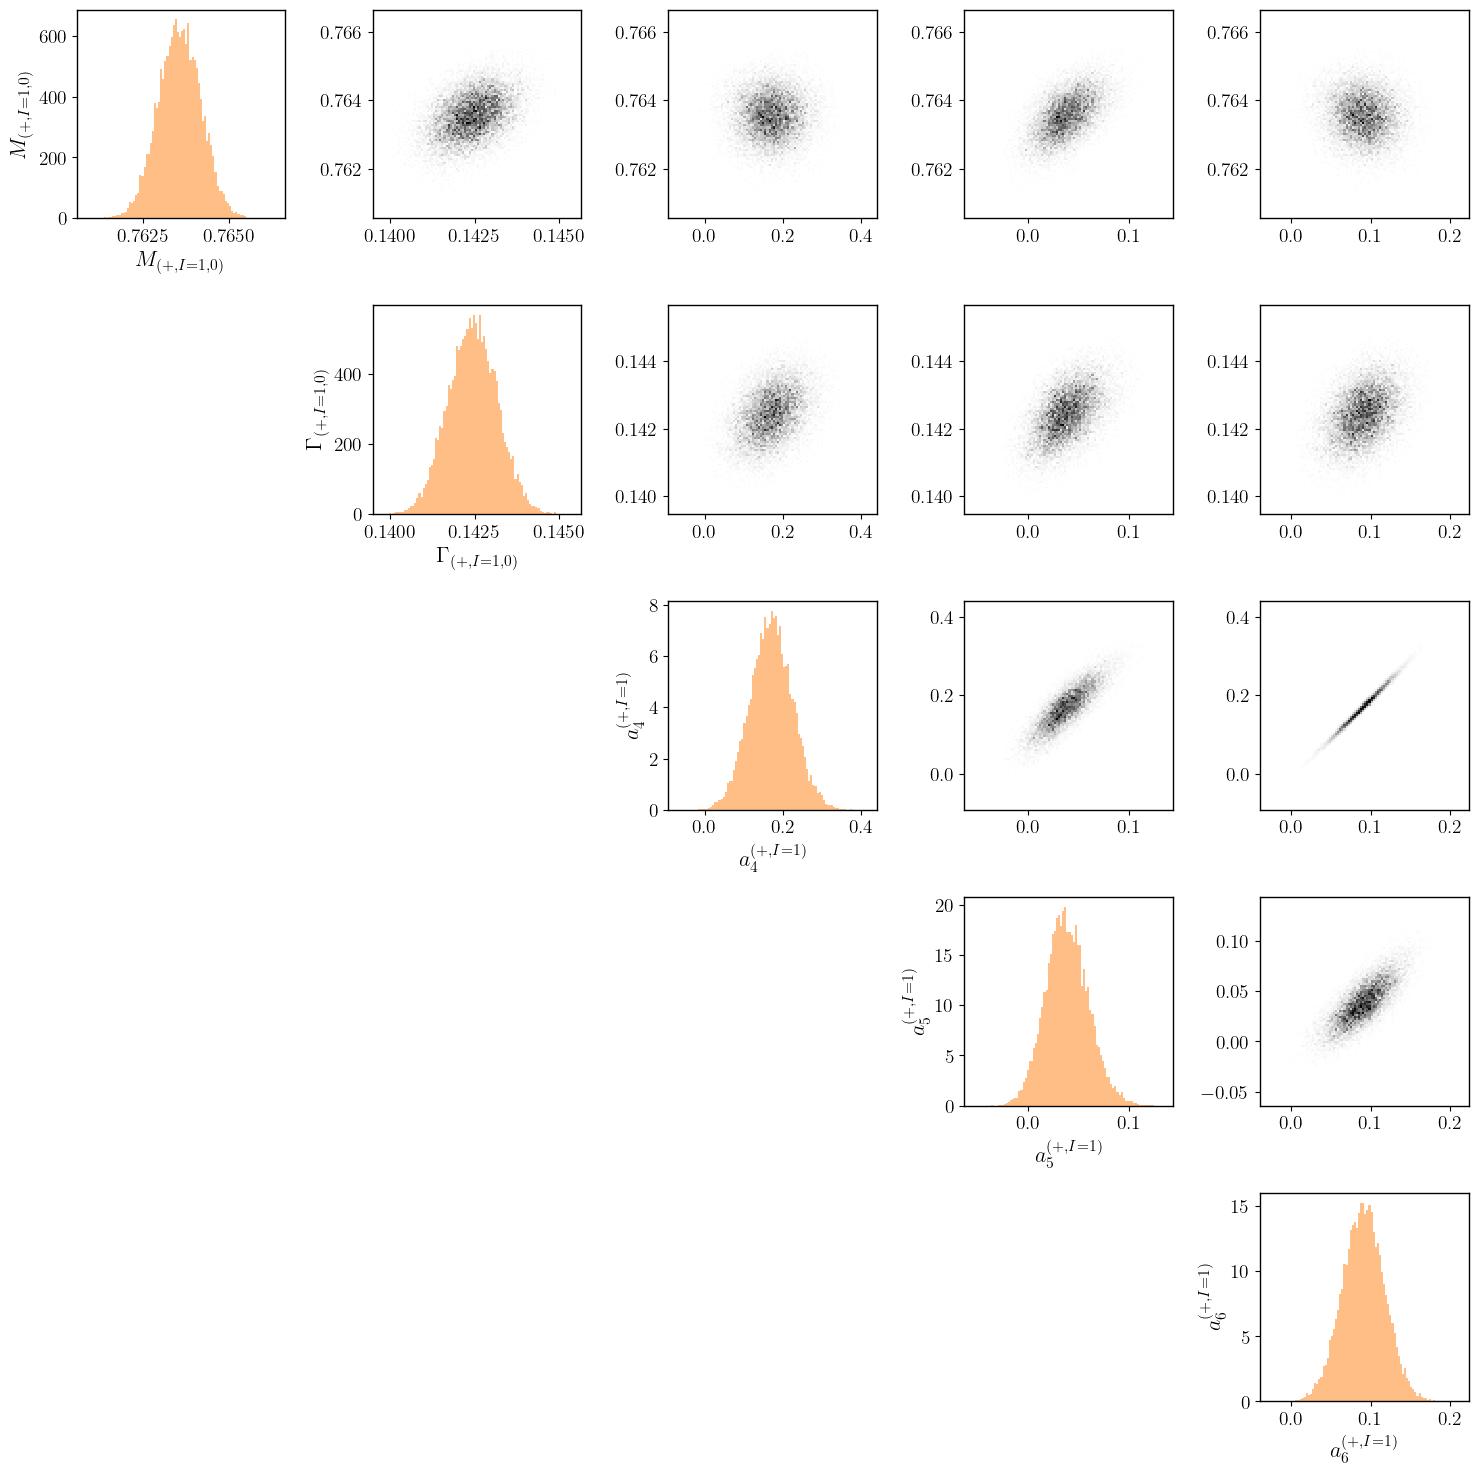

Creating analysis with 5 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order6-CLEO
Collected 14993 samples


[0.7617389798825177,
 0.1431899143423447,
 0.09109873751067976,
 -0.013780958814028257,
 0.05946900000486971]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75810, 'max': 0.76539, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.13812, 'max': 0.15165, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.20342, 'max': 0.45420, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.13805, 'max': 0.13924, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.08437, 'max': 0.23959, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-CL…

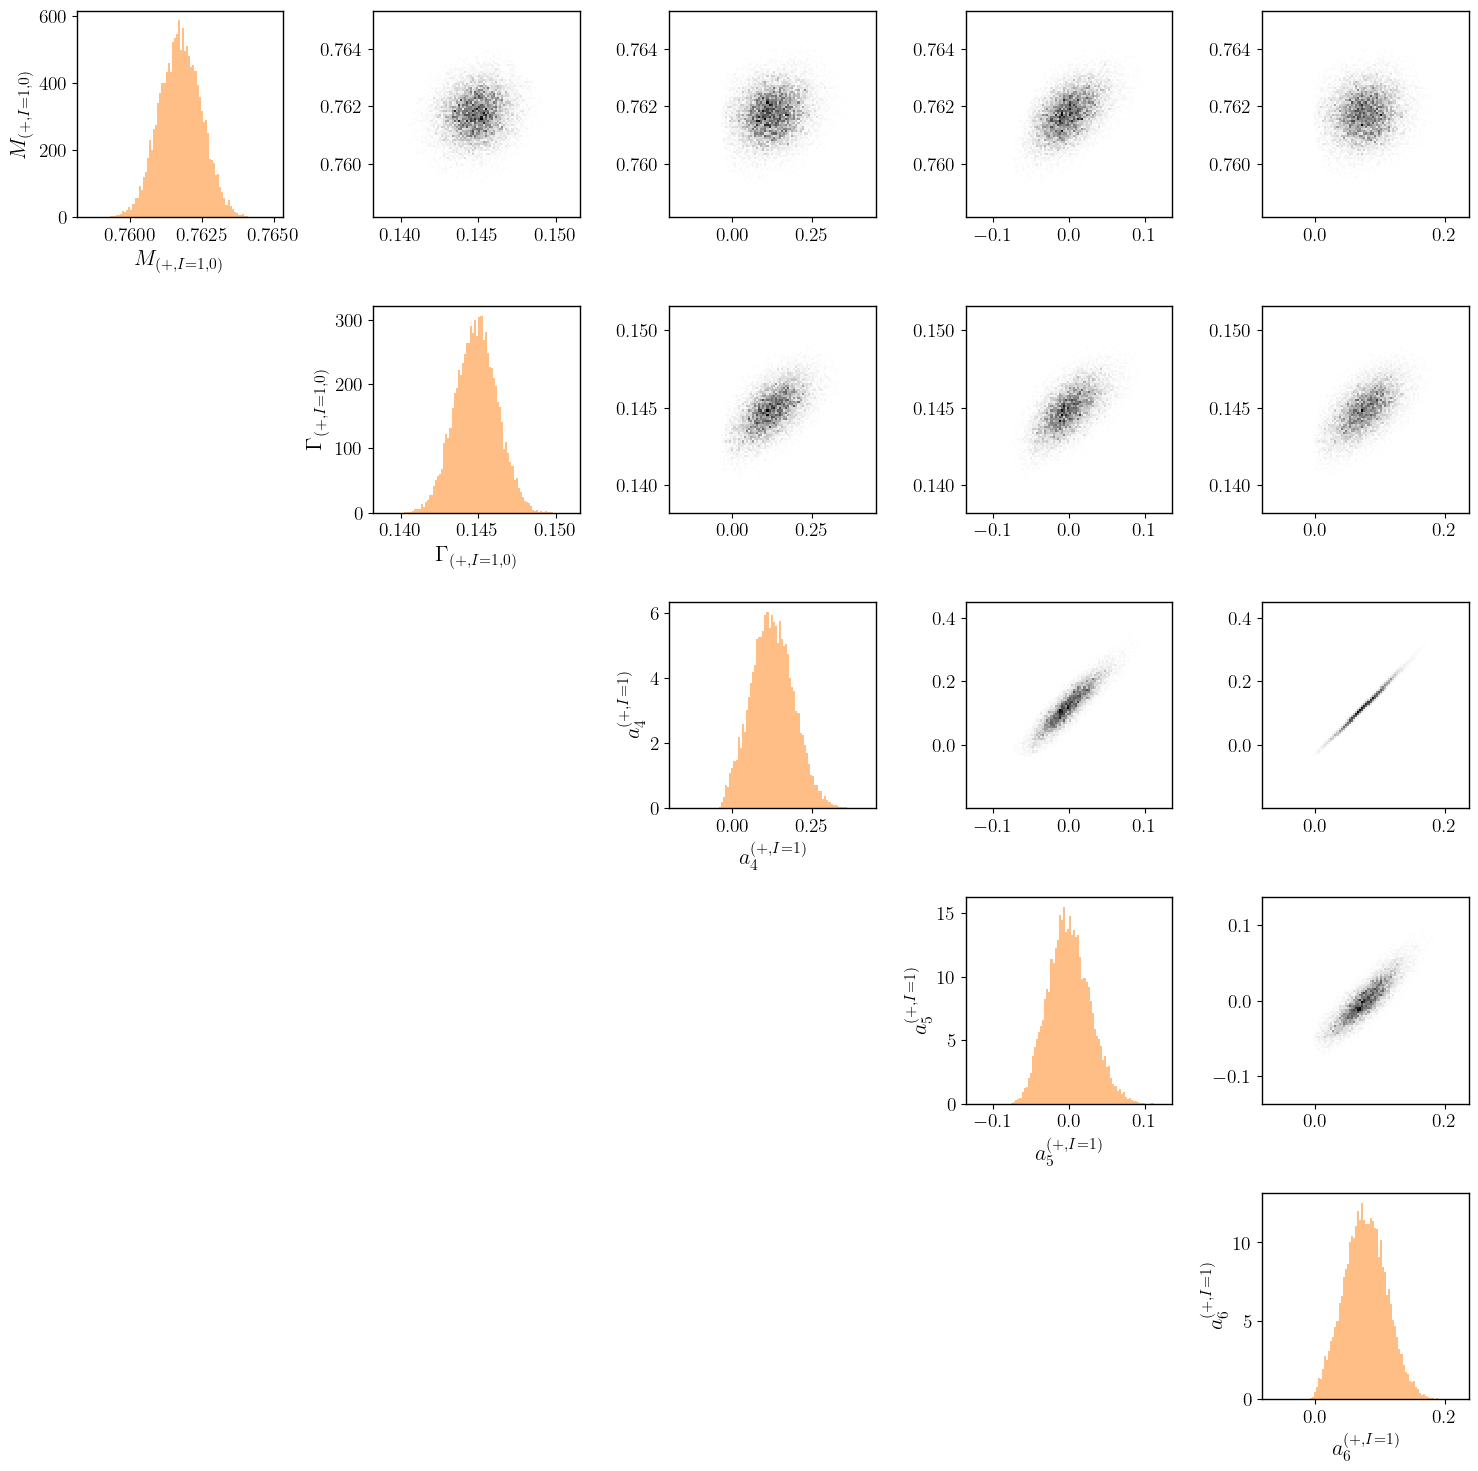

Creating analysis with 5 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order6-ALEPH
Collected 13483 samples


[0.7605022258264944,
 0.1424521515040677,
 -0.0024582611569751167,
 -0.06901634280930423,
 0.01742234640680254]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75364, 'max': 0.76768, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.13256, 'max': 0.15554, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.22757, 'max': 0.34302, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.18004, 'max': 0.09221, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.09615, 'max': 0.19177, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-AL…

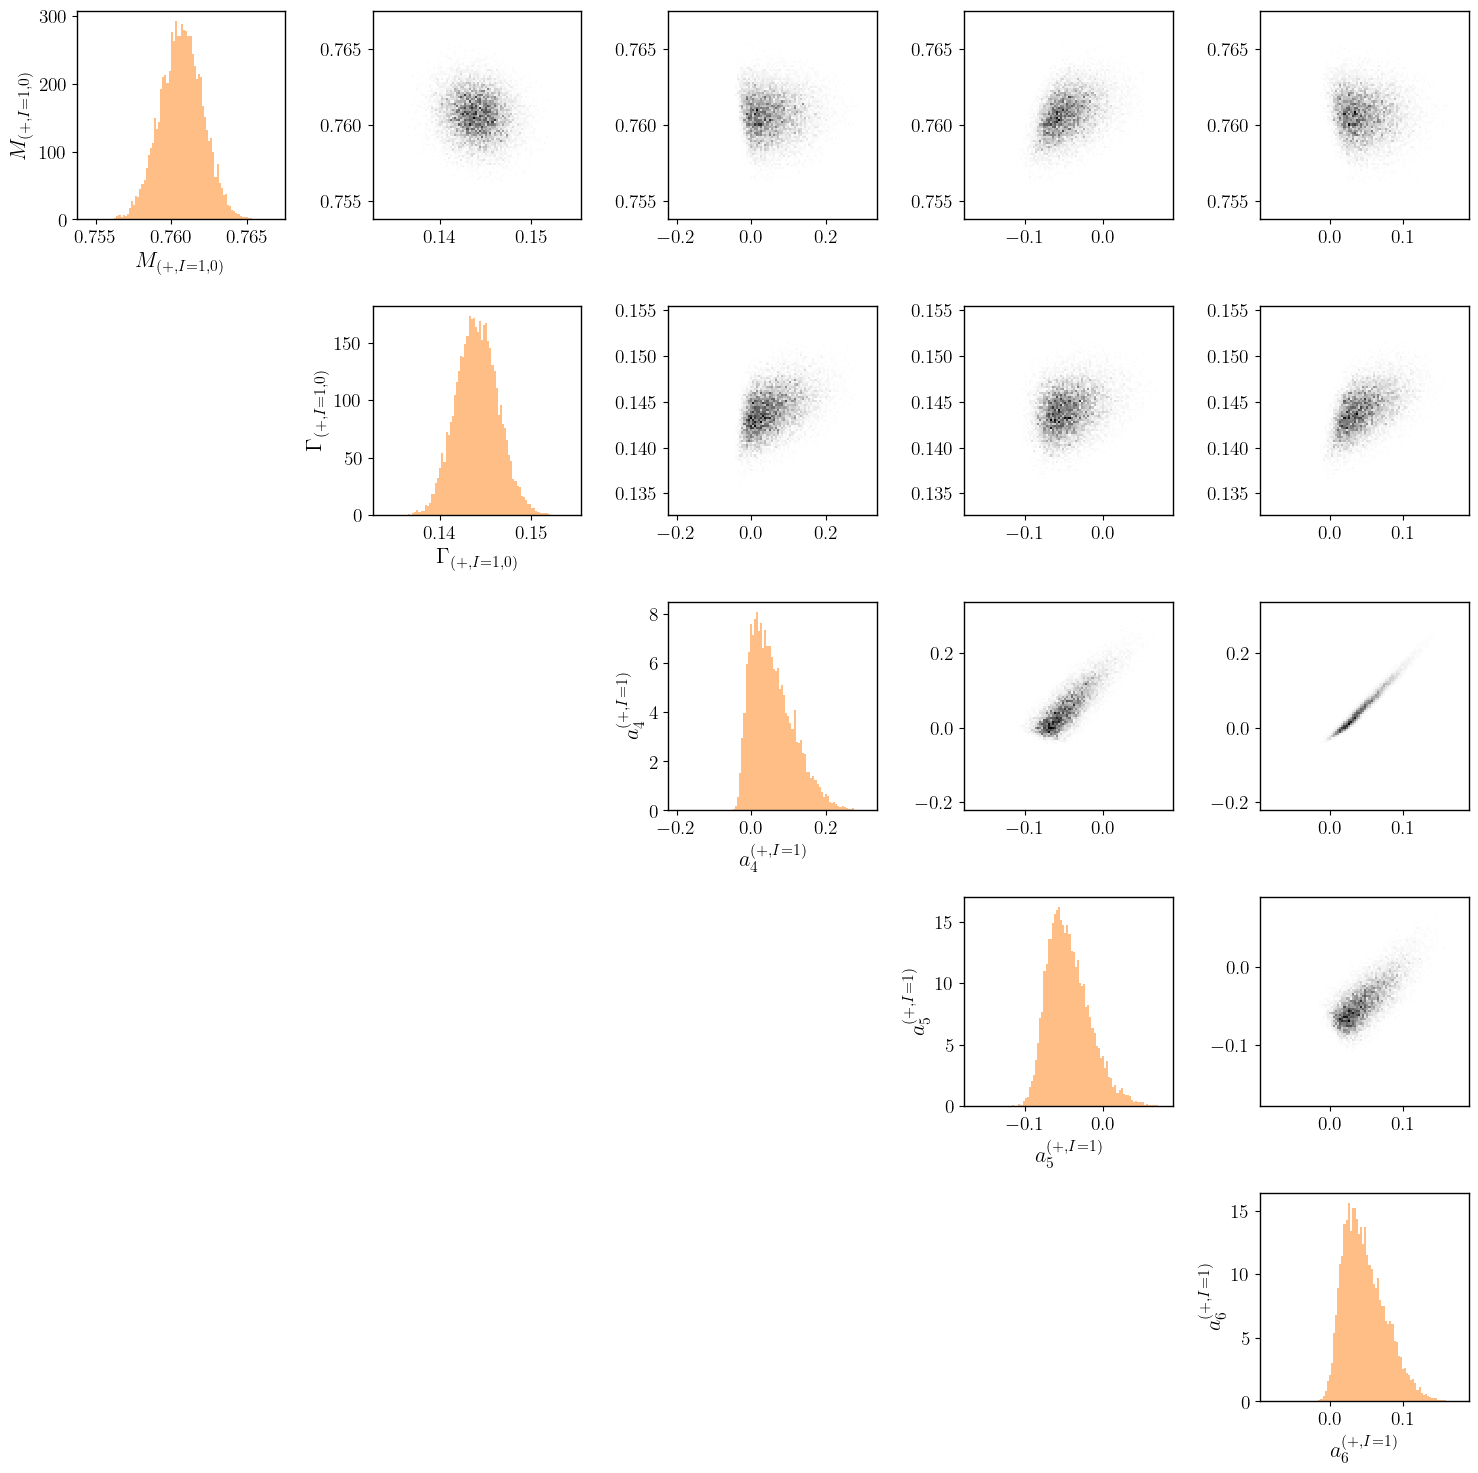

Creating analysis with 5 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 21 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order6-OPAL
Collected 14537 samples


[0.7616048209901046,
 0.148887835040798,
 0.09637467703933783,
 -0.015119387913309662,
 0.06908291076580306]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.74644, 'max': 0.77724, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.12974, 'max': 0.17321, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.30513, 'max': 0.58677, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.22884, 'max': 0.24069, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.13106, 'max': 0.31613, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order6-OP…

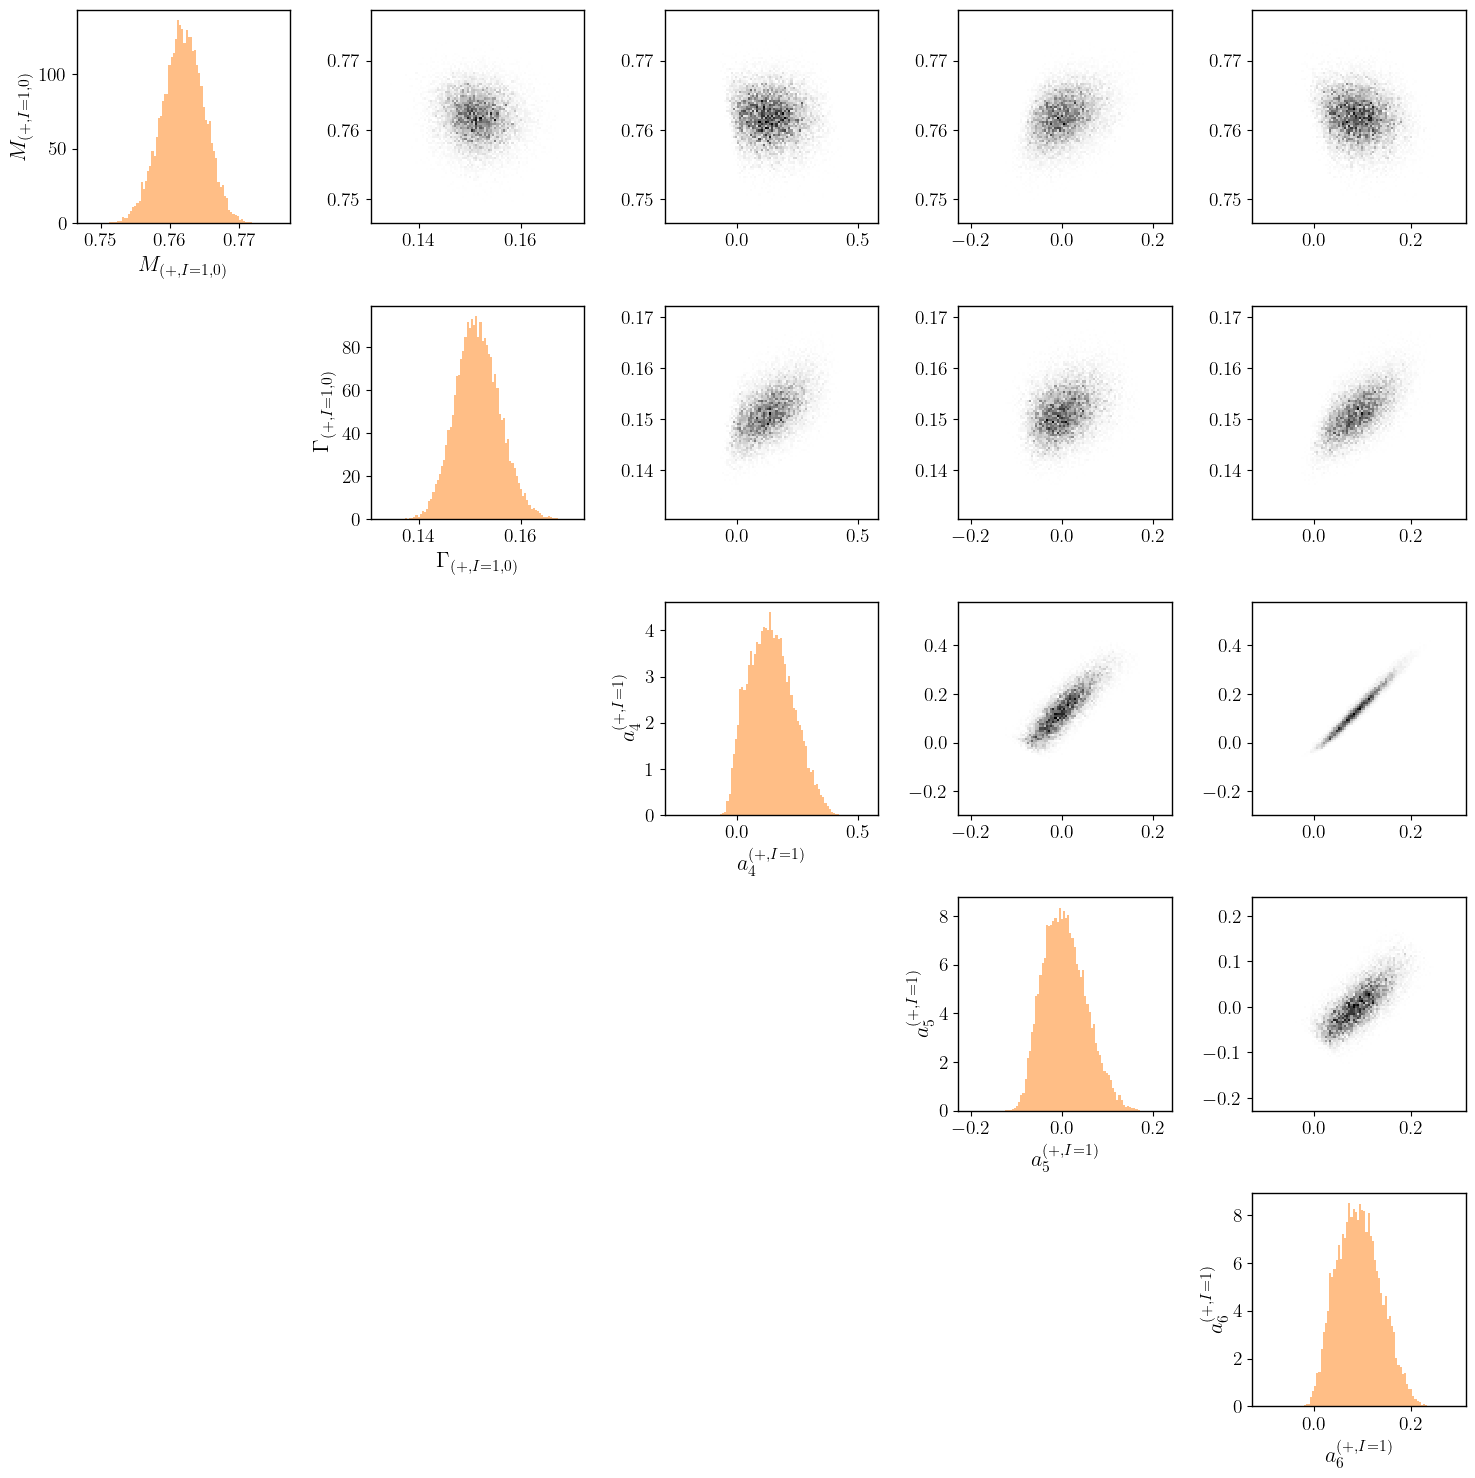

In [25]:
order = 6

fit_results.setdefault(order, {})

for experiment in EXPERIMENTS:
    fit_results[order][experiment] = prepare_fit(
        order,
        experiment,
        resample=resample,
        refit=False,
    )

    show_fit(fit_results[order][experiment])

Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


Belle rho mass  = 0.7636 ± 0.0006 GeV
Belle rho width = 0.1424 ± 0.0007 GeV
CLEO rho mass  = 0.7617 ± 0.0007 GeV
CLEO rho width = 0.1449 ± 0.0014 GeV
ALEPH rho mass  = 0.7607 ± 0.0014 GeV
ALEPH rho width = 0.1441 ± 0.0023 GeV
OPAL rho mass  = 0.7618 ± 0.0031 GeV
OPAL rho width = 0.1515 ± 0.0043 GeV


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


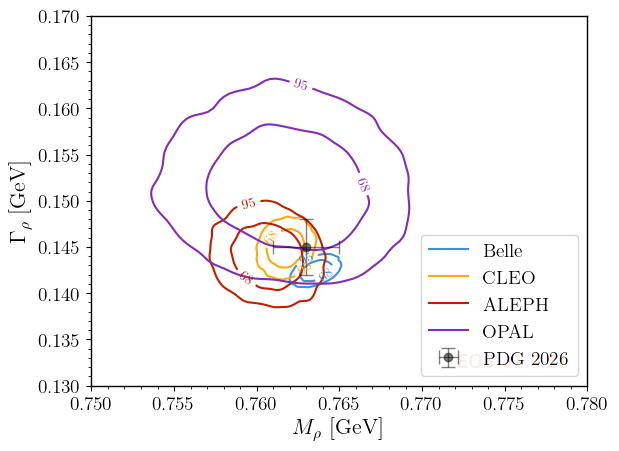

In [26]:
rho_figure_order6 = show_rho_mass_width(order)

Belle dispersive bound is 0.4509 ± 0.0041
CLEO dispersive bound is 0.4567 ± 0.0064
ALEPH dispersive bound is 0.4636 ± 0.0072
OPAL dispersive bound is 0.4523 ± 0.0091


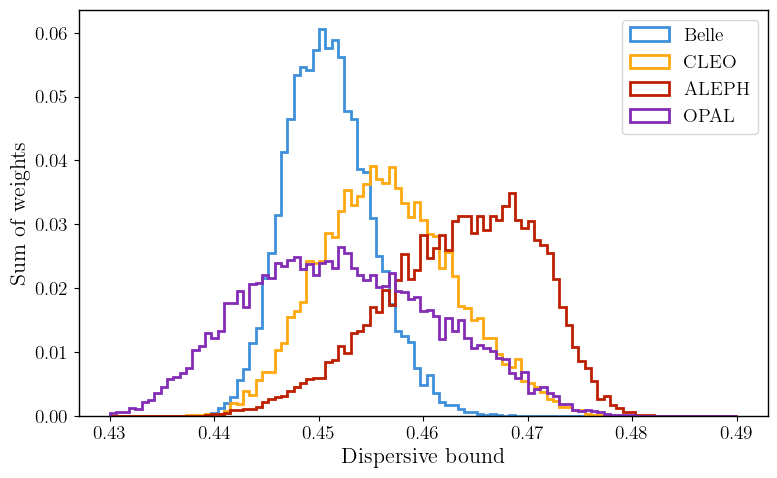

In [27]:
# Use recompute=True if the saved predictions need updating
# after changing samples or prediction definitions.
show_dispersive_bound(6, recompute=resample)

bins = np.linspace(0.43, 0.49, 100)

disp_hist_order6 = plot_dispersive_bound_histogram(
    order=6,
    bins=bins,
)

Belle, order 6: full


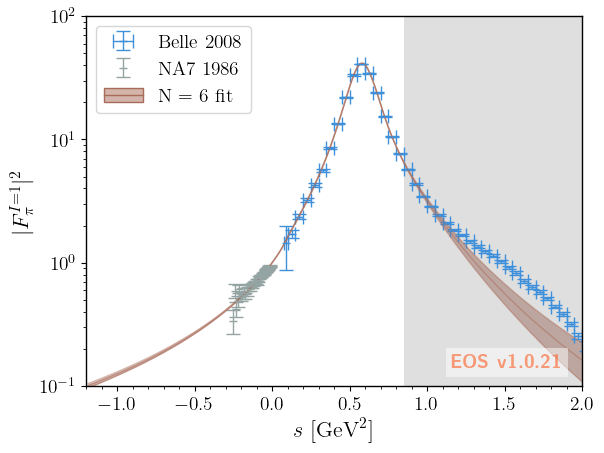

Belle, order 6: zoom


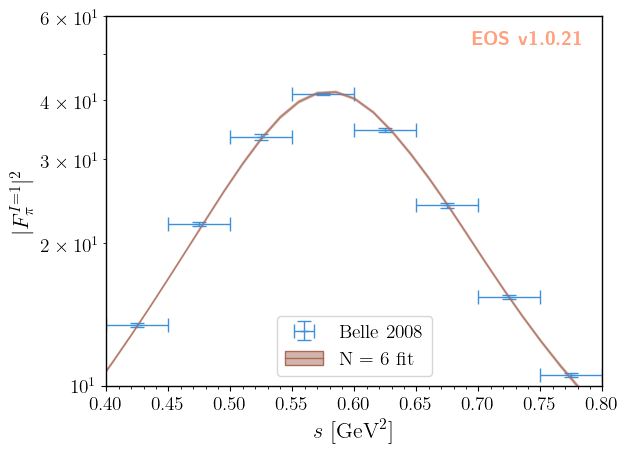

CLEO, order 6: full


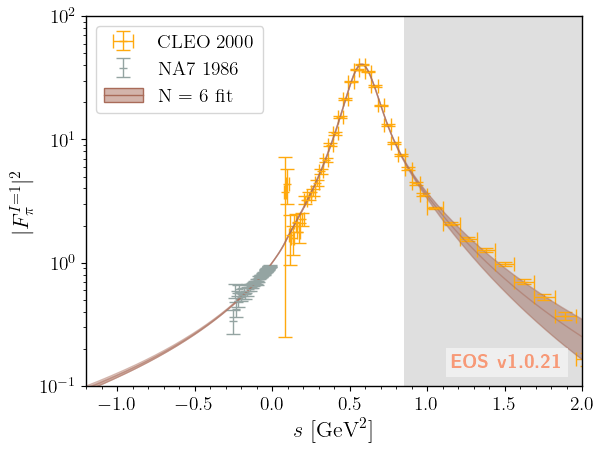

CLEO, order 6: zoom


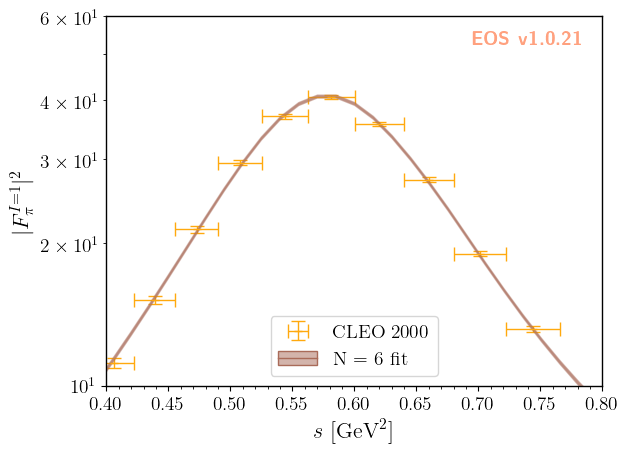

ALEPH, order 6: full


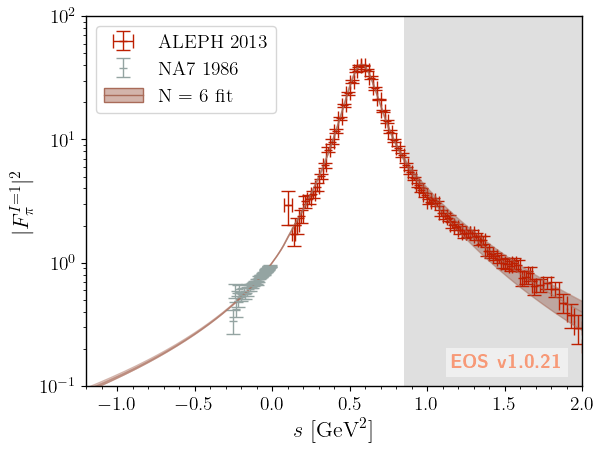

ALEPH, order 6: zoom


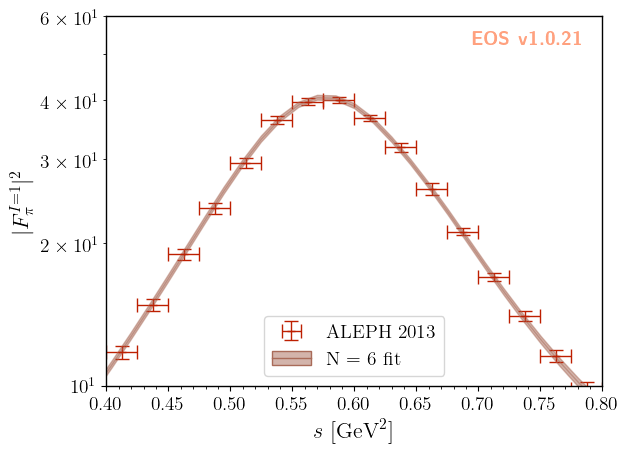

OPAL, order 6: full


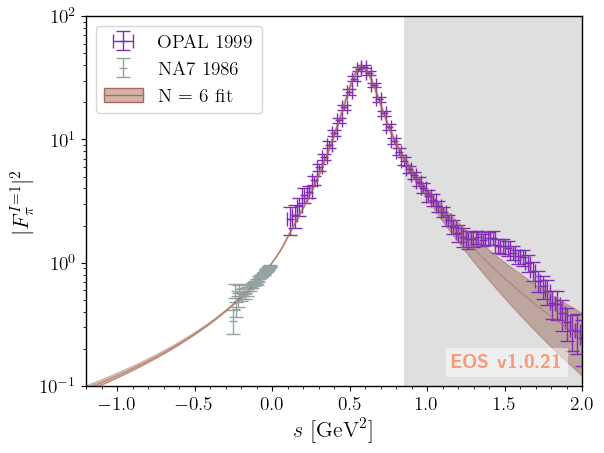

OPAL, order 6: zoom


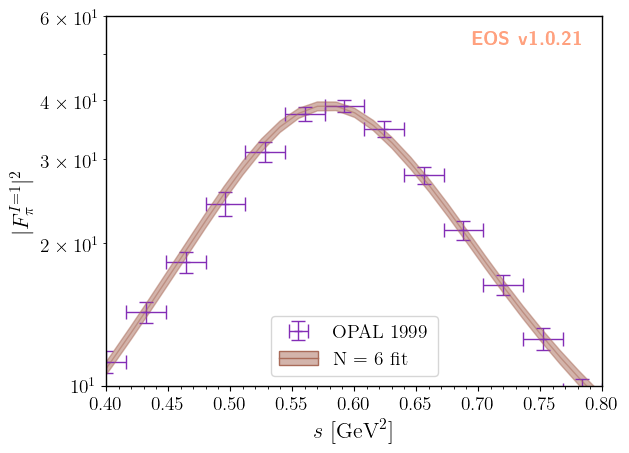

In [28]:
for experiment in EXPERIMENTS:
    plot_form_factor_squared(
        order=6,
        experiment=experiment,
        recompute=resample,
    )

Belle, order 6: residuals at the BFP


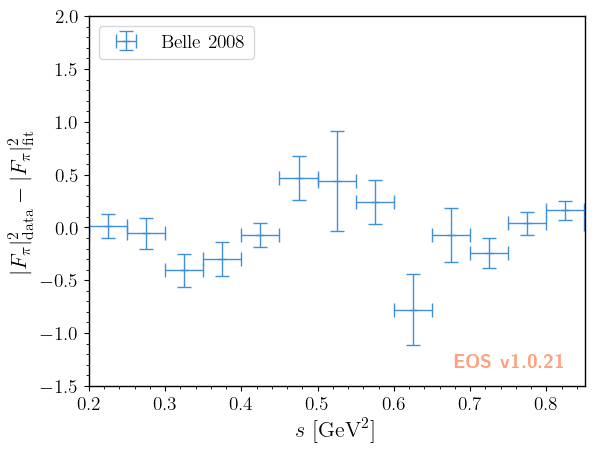

CLEO, order 6: residuals at the BFP


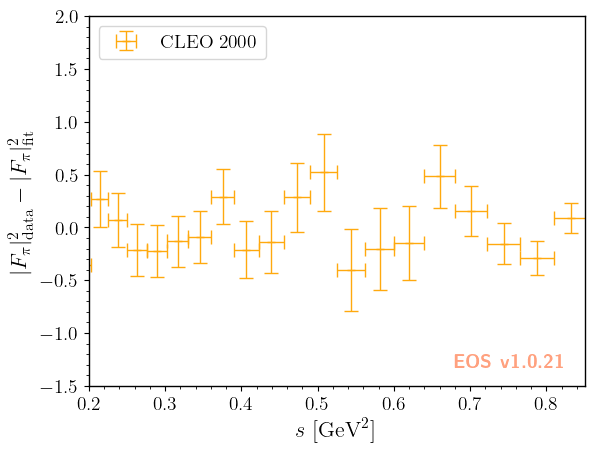

ALEPH, order 6: residuals at the BFP


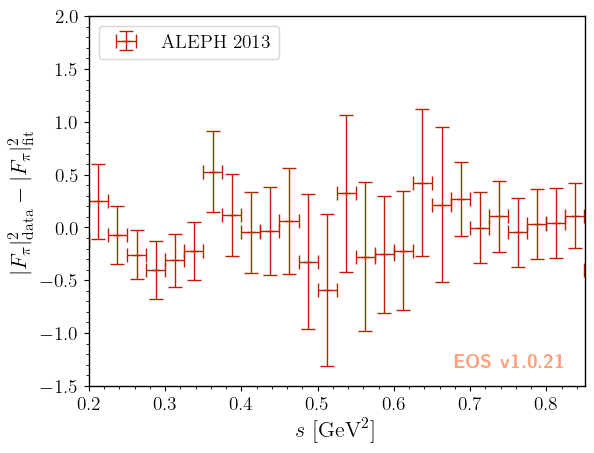

OPAL, order 6: residuals at the BFP


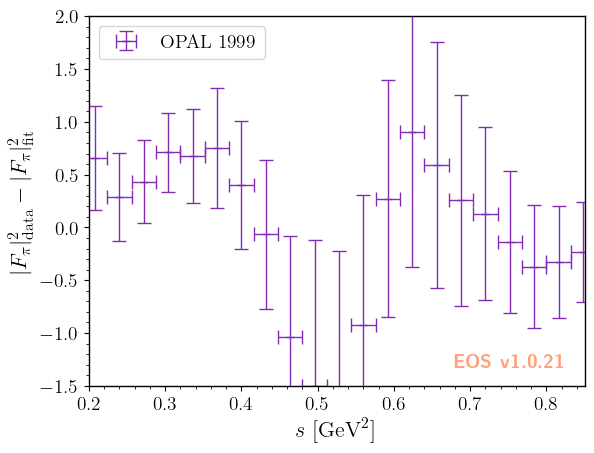

In [29]:
for experiment in EXPERIMENTS:
    plot_form_factor_residuals(
        order=order,
        experiment=experiment,
    )

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


Belle, order 6: phase in the psi plane


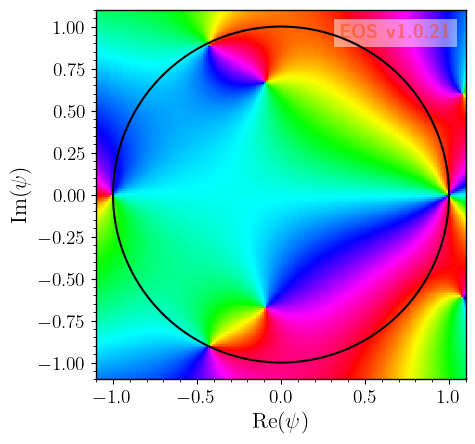

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


CLEO, order 6: phase in the psi plane


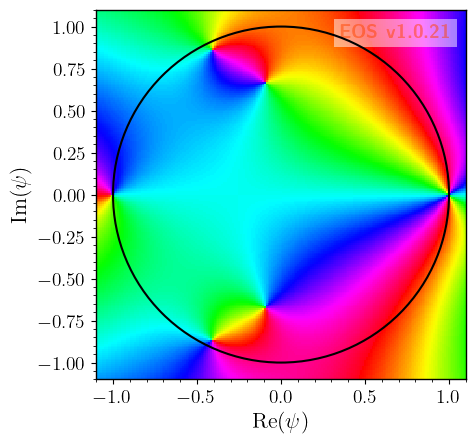

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


ALEPH, order 6: phase in the psi plane


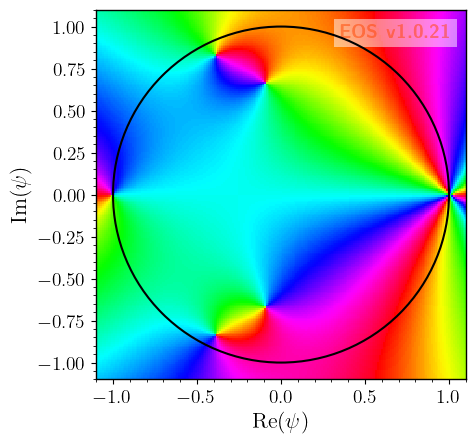

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


OPAL, order 6: phase in the psi plane


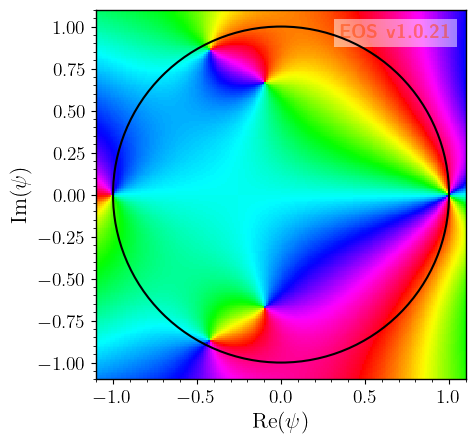

In [30]:
for experiment in EXPERIMENTS:
    plot_psi_phase(
        order=6,
        experiment=experiment,
        resolution=200,
    )

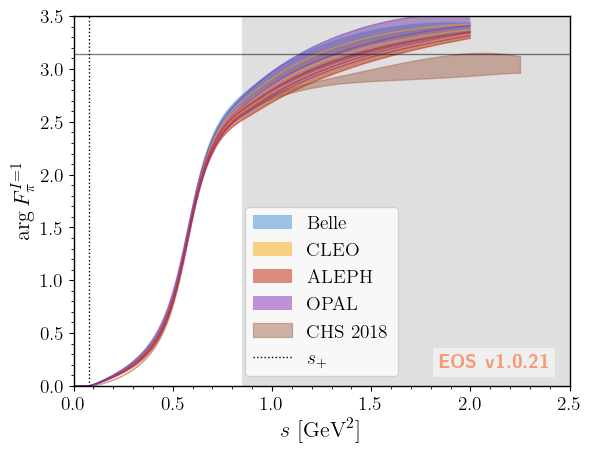

In [31]:
phase_figure_order6 = plot_timelike_phase(
    order=6,
    recompute=resample,
)

Belle, order 6: full


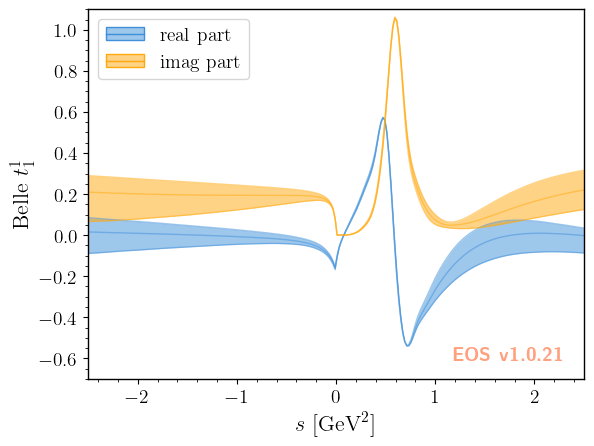

Belle, order 6: near zero


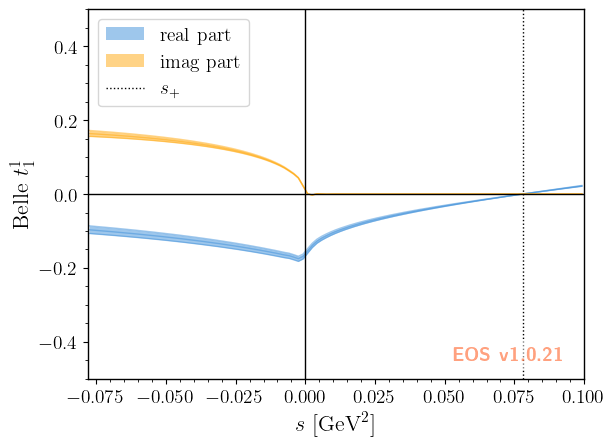

Belle, order 6: threshold


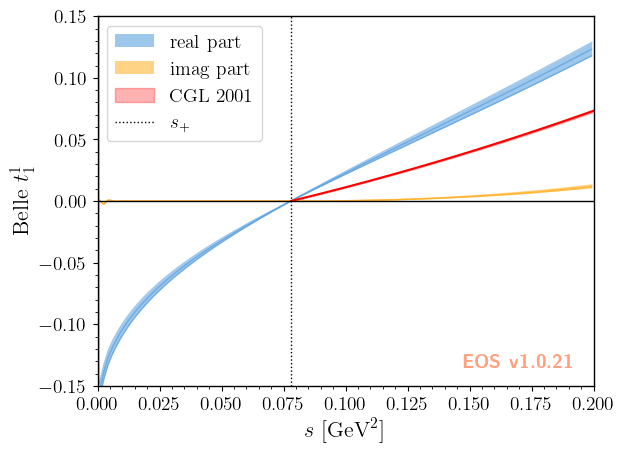

CLEO, order 6: full


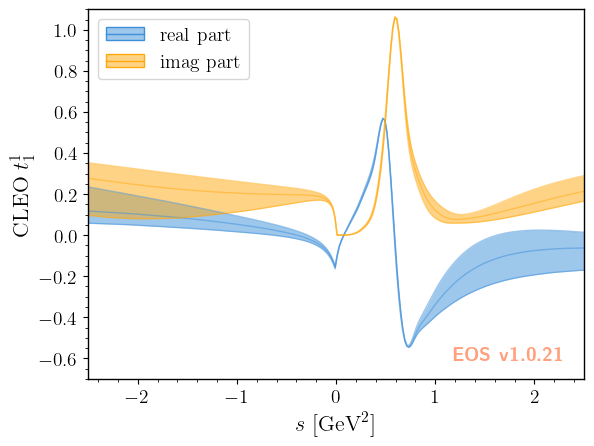

CLEO, order 6: near zero


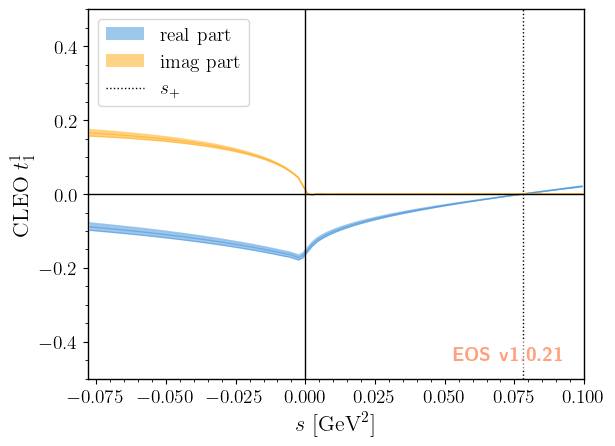

CLEO, order 6: threshold


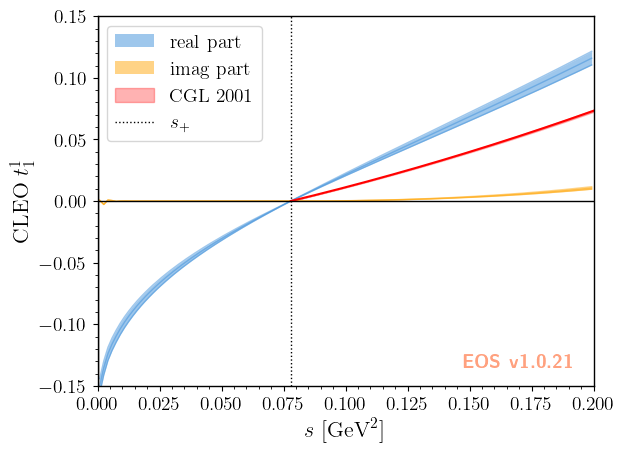

ALEPH, order 6: full


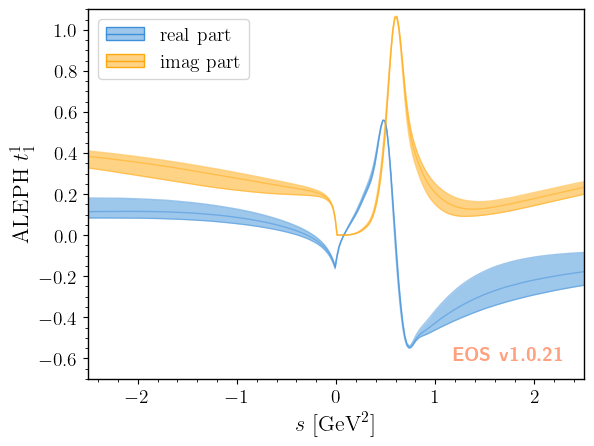

ALEPH, order 6: near zero


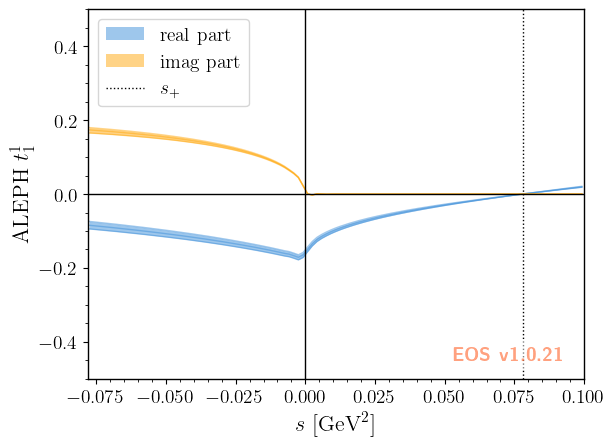

ALEPH, order 6: threshold


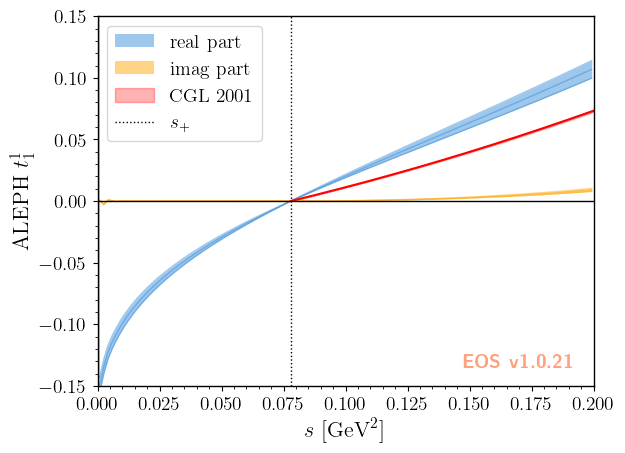

OPAL, order 6: full


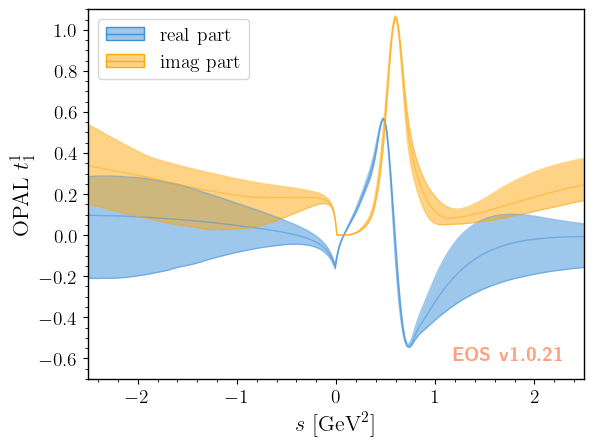

OPAL, order 6: near zero


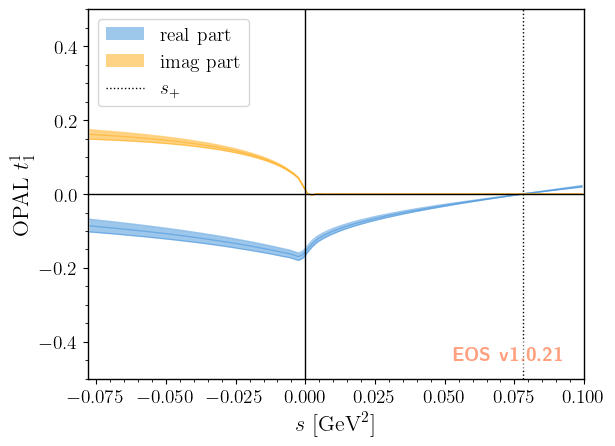

OPAL, order 6: threshold


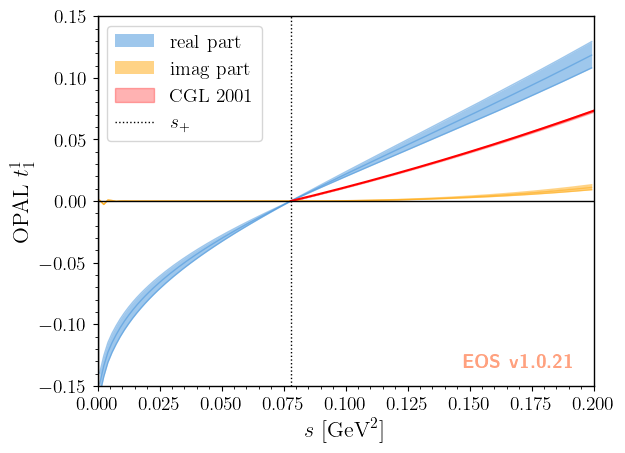

In [32]:
order = 6

for experiment in EXPERIMENTS:
    plot_partial_waves(
        order=order,
        experiment=experiment,
        theory_band=partial_wave_theory,
        recompute=resample,
    )

Belle a11 = 0.0829 ± 0.0041
Belle b11 = -0.0090 ± 0.0010
CLEO a11 = 0.0785 ± 0.0039
CLEO b11 = -0.0097 ± 0.0014
ALEPH a11 = 0.0745 ± 0.0047
ALEPH b11 = -0.0116 ± 0.0013


Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


OPAL a11 = 0.0788 ± 0.0069
OPAL b11 = -0.0086 ± 0.0022


Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


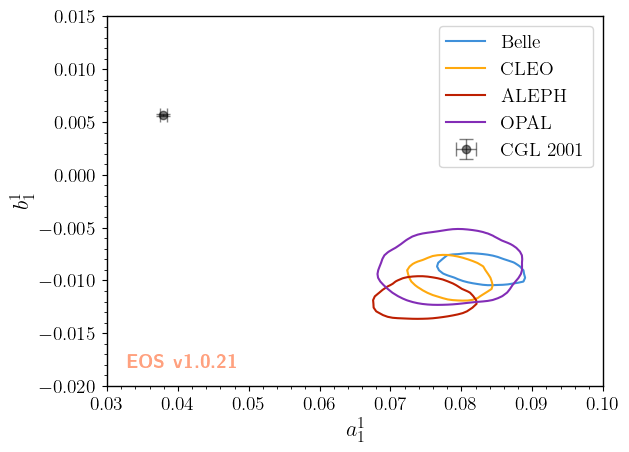

In [33]:
show_scattering_lengths(
    order=order,
    recompute=resample,
)

sl_figure_order6 = plot_scattering_lengths(
    order=order,
    xrange=(0.03, 0.1),
    yrange=(-0.02, 0.015),
)

In [34]:
show_charge_radius(
    order=order,
    recompute=resample,
)

Belle <r^2> = 0.4433 ± 0.0047 fm^2
CLEO <r^2> = 0.4427 ± 0.0045 fm^2
ALEPH <r^2> = 0.4386 ± 0.0050 fm^2
OPAL <r^2> = 0.4454 ± 0.0058 fm^2


In [35]:
export_rho_residues_psi(
    order=order,
    recompute=resample,
)

Belle: exported 15031 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_Belle6.wl
CLEO: exported 14993 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_CLEO6.wl
ALEPH: exported 13483 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_ALEPH6.wl
OPAL: exported 14537 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_OPAL6.wl


In [36]:
show_rho_couplings(order=order)

Belle: g_rho_gamma = (4.9080 ± 0.0081) + i * (-0.2742 ± 0.0143)
Belle: g_rho_pi_pi = (5.9758 ± 0.0474) + i * (0.1028 ± 0.1226)
CLEO: g_rho_gamma = (4.9186 ± 0.0180) + i * (-0.2419 ± 0.0160)
CLEO: g_rho_pi_pi = (5.9811 ± 0.0788) + i * (-0.1407 ± 0.1500)
ALEPH: g_rho_gamma = (4.9568 ± 0.0202) + i * (-0.2139 ± 0.0243)
ALEPH: g_rho_pi_pi = (5.8700 ± 0.0928) + i * (-0.4281 ± 0.1725)
OPAL: g_rho_gamma = (4.9245 ± 0.0341) + i * (-0.2380 ± 0.0378)
OPAL: g_rho_pi_pi = (6.1448 ± 0.1644) + i * (-0.1076 ± 0.2966)


##  order 7

Creating analysis with 6 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 20 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order7-Belle
Collected 14716 samples


[0.7627383687688432,
 0.14282140897938272,
 0.05141036072957278,
 -0.1509669884684109,
 0.045780002993518844,
 -0.07357298445518604]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75958, 'max': 0.76663, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.13884, 'max': 0.14668, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.16910, 'max': 0.40741, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.44000, 'max': 0.31213, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.05665, 'max': 0.20361, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.19444, 'max': 0.11081, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-Be…

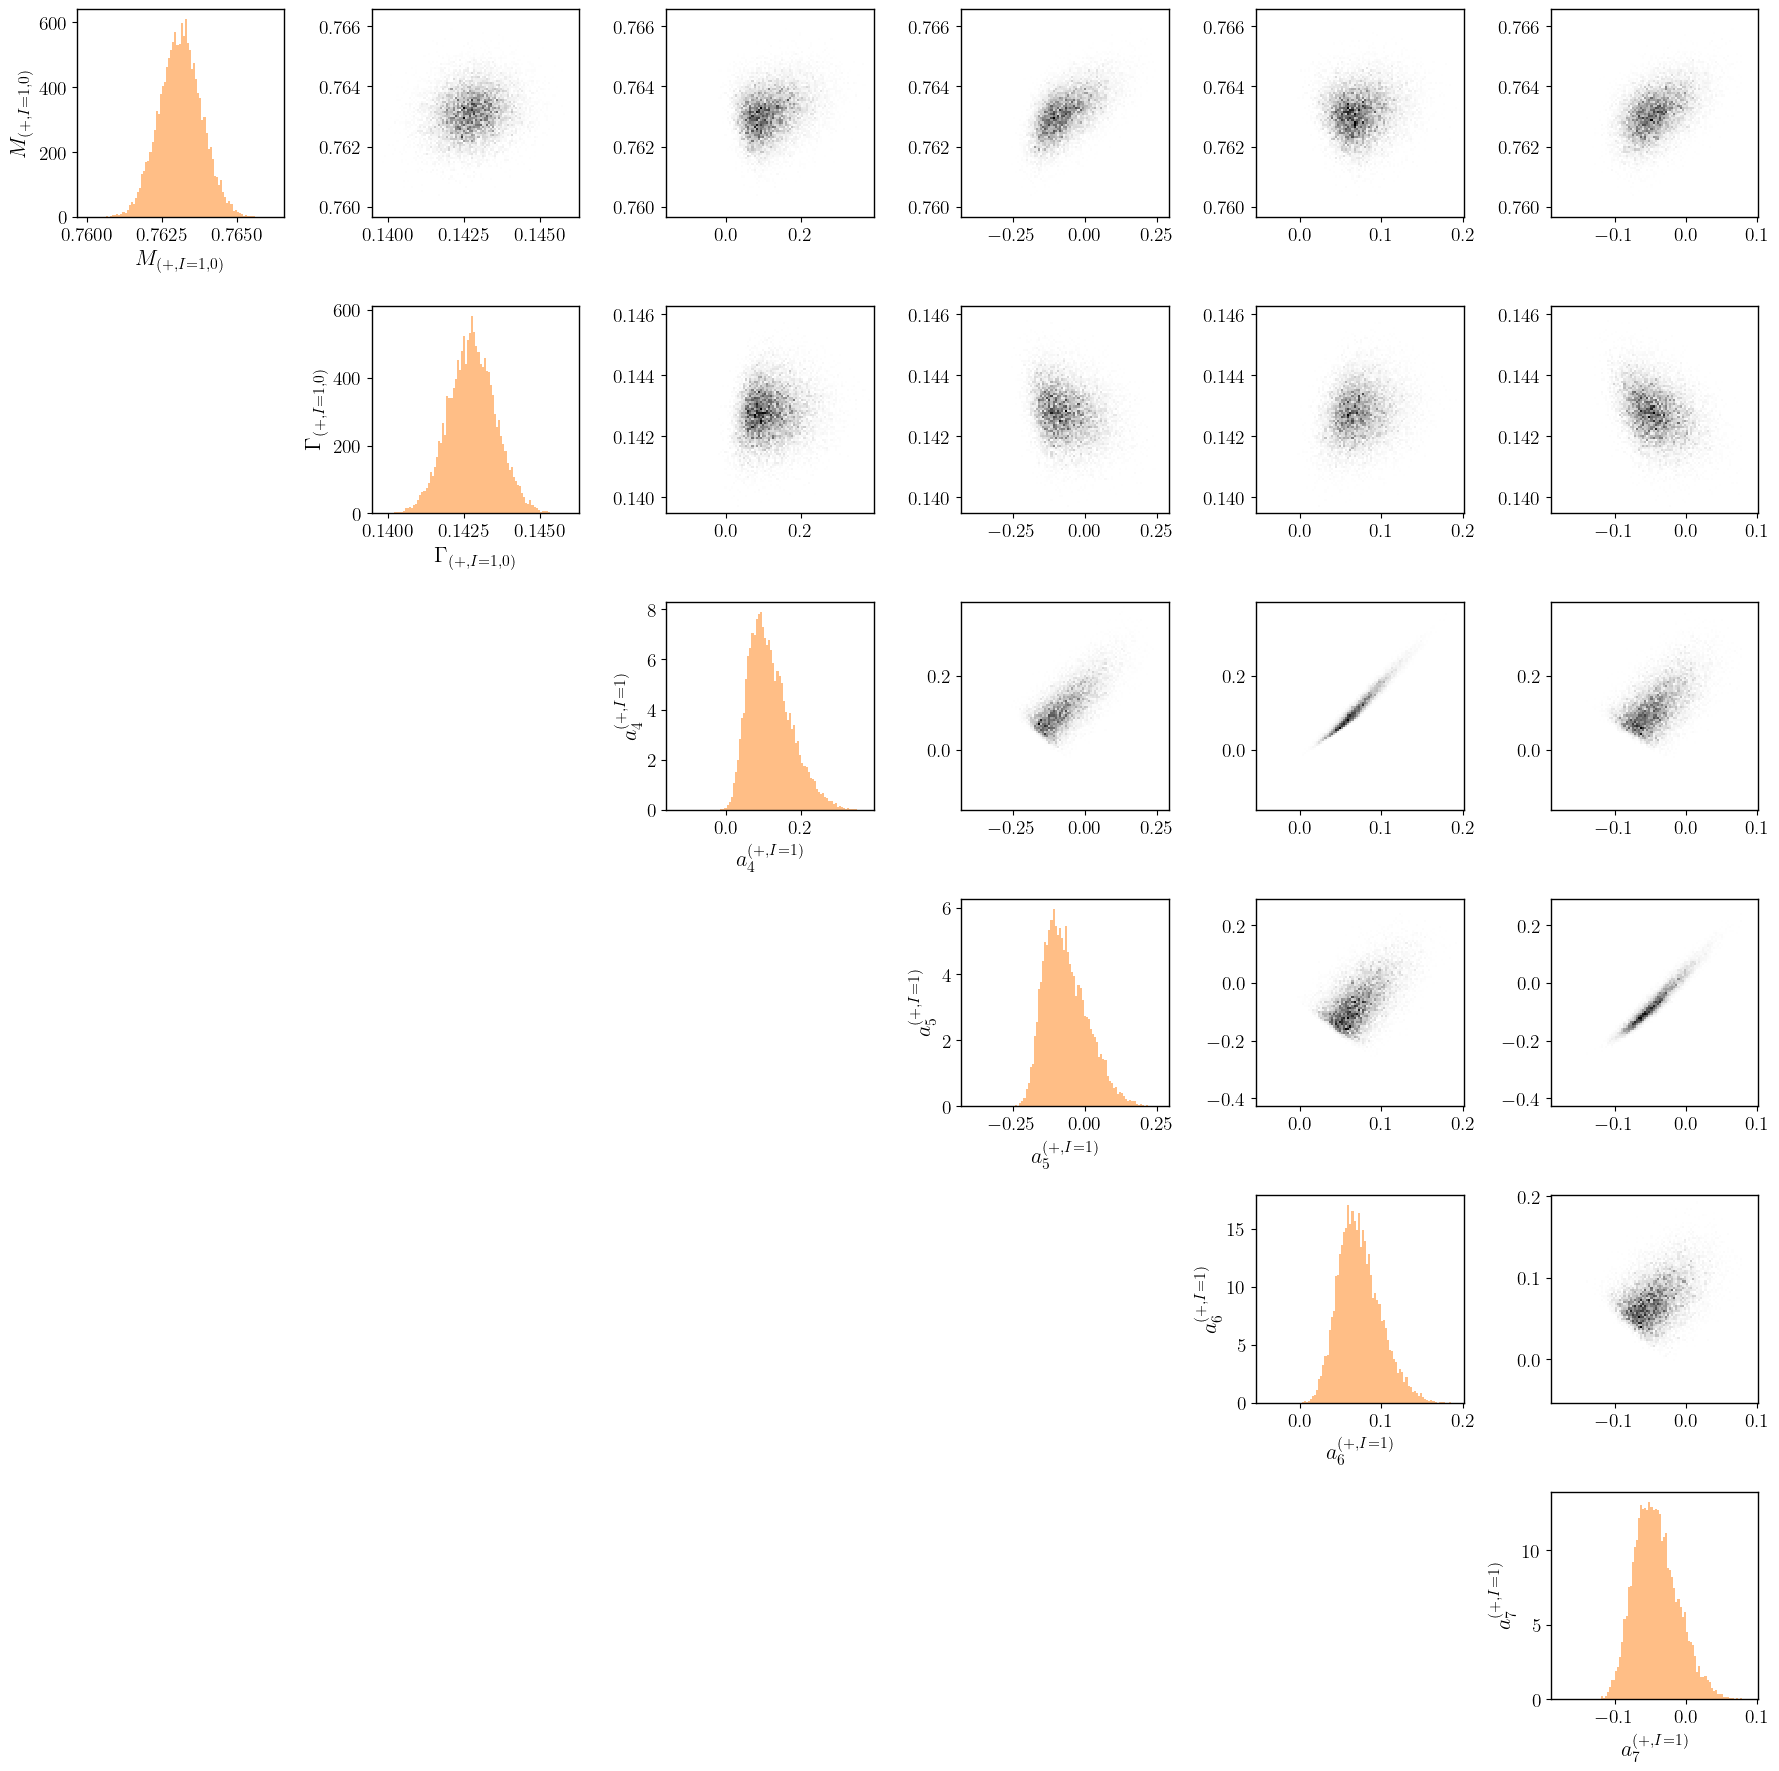

Creating analysis with 6 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 20 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order7-CLEO
Collected 14350 samples


[0.7616923800413606,
 0.14365025242965165,
 0.06229178588367468,
 -0.07745478510868087,
 0.04935675326610142,
 -0.029220009993368296]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75826, 'max': 0.76537, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.13500, 'max': 0.15202, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.20498, 'max': 0.42376, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.47637, 'max': 0.45696, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.08068, 'max': 0.21756, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.23081, 'max': 0.22642, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-CL…

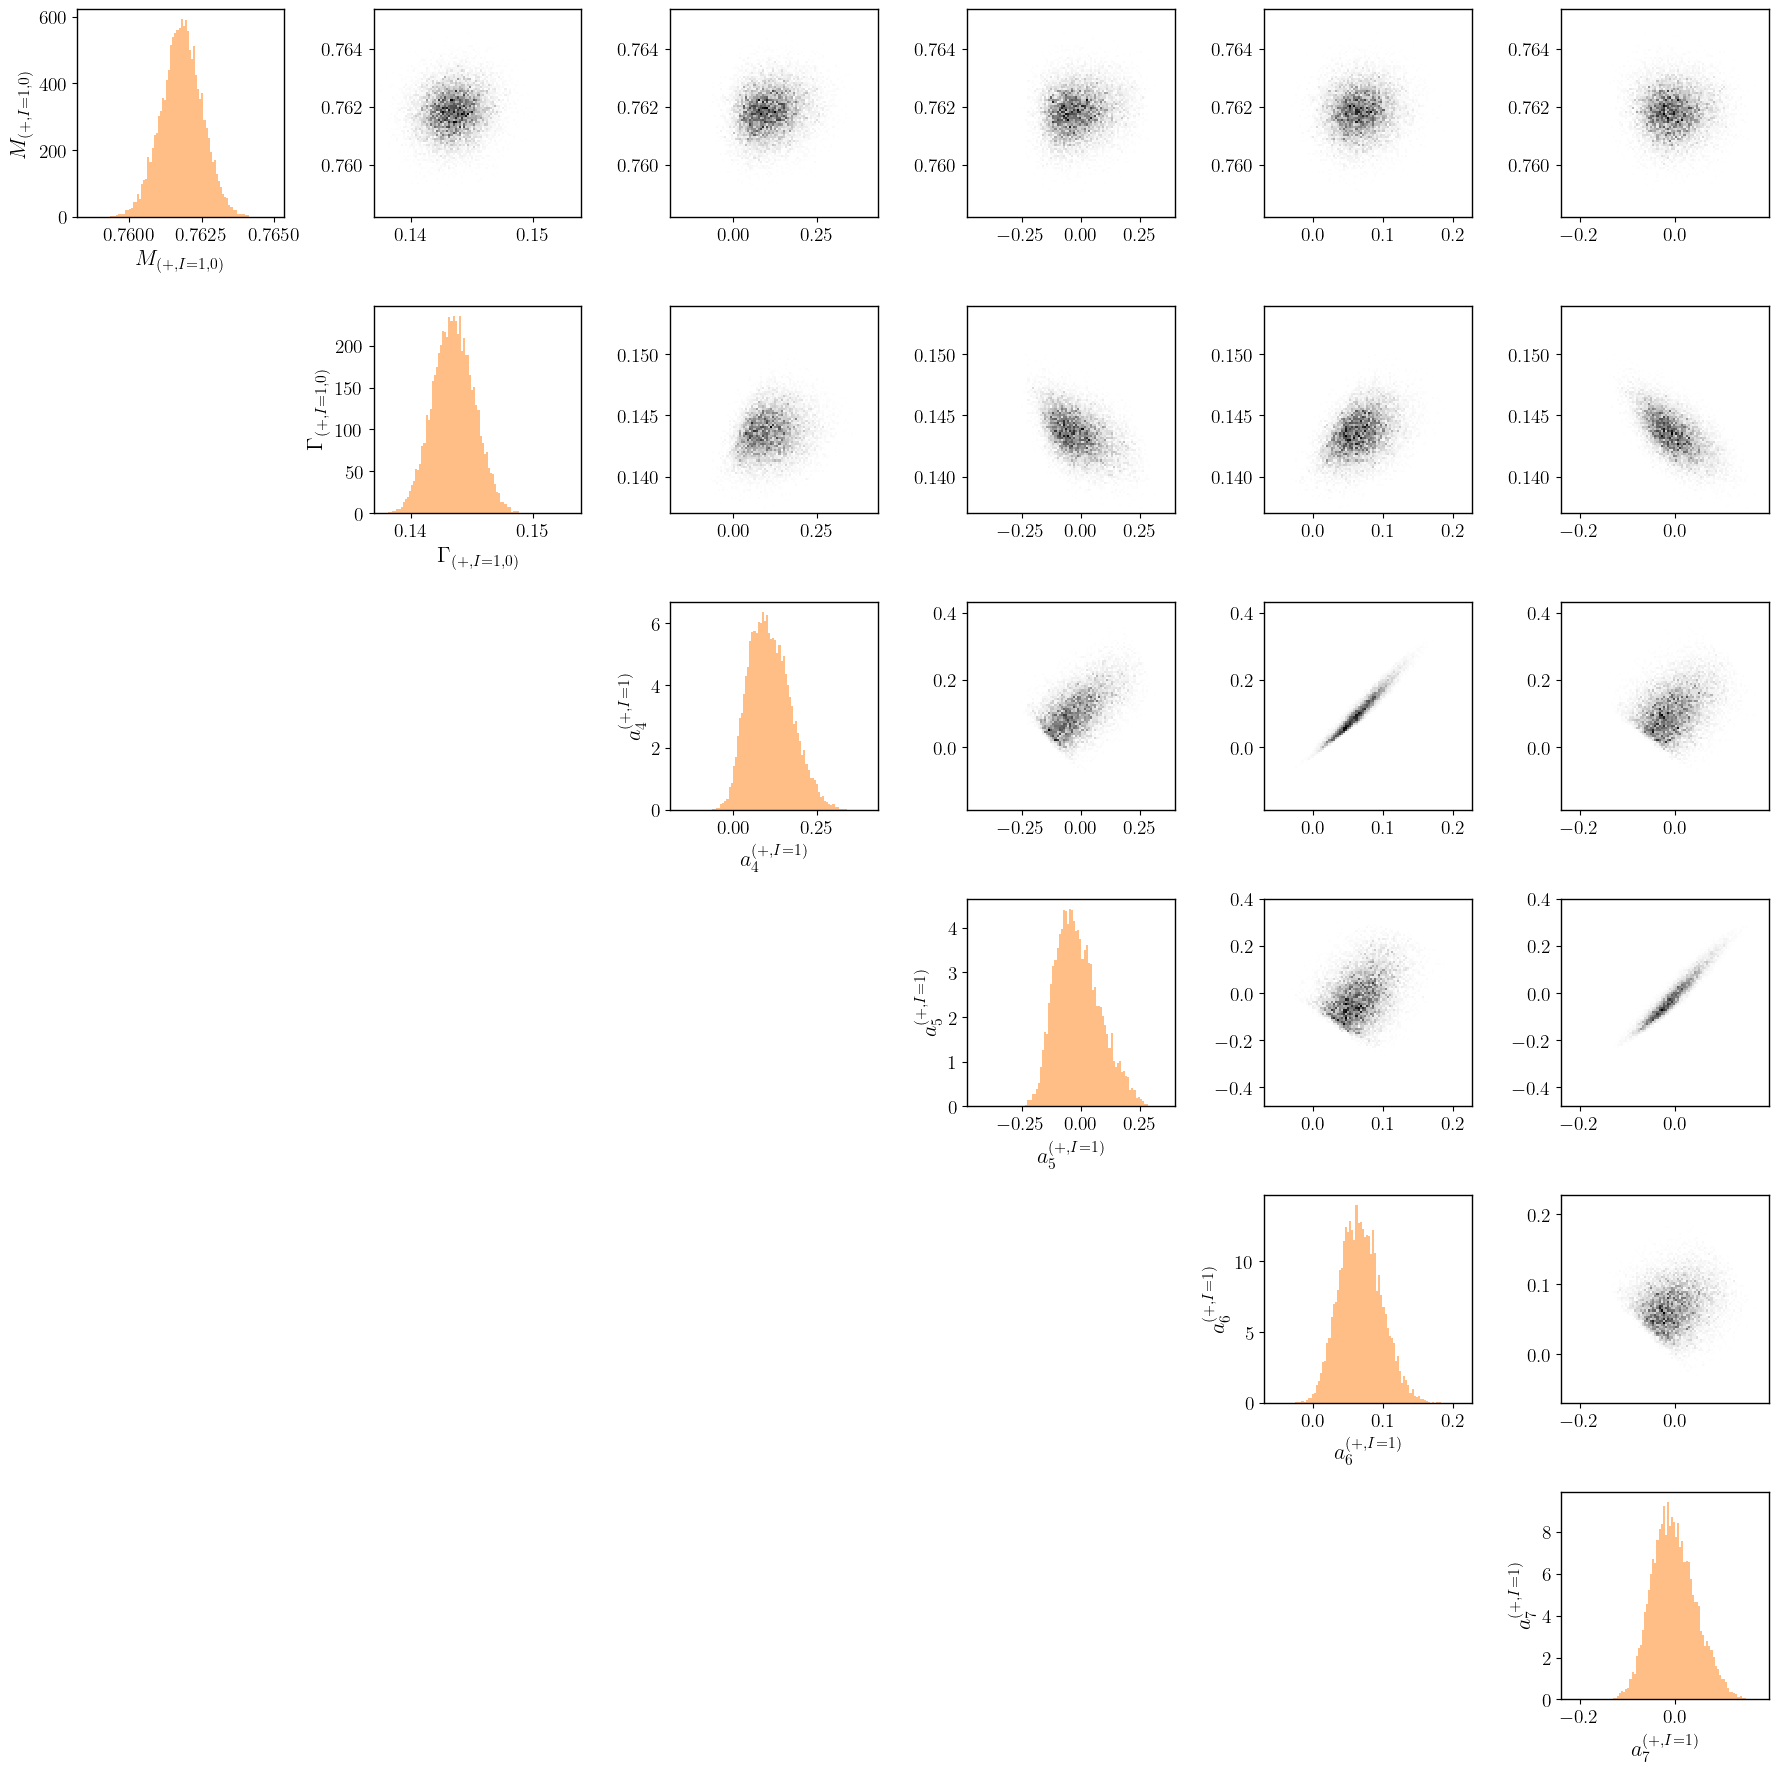

Creating analysis with 6 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 20 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order7-ALEPH
Collected 14020 samples


[0.7605075687717545,
 0.1419495167465522,
 0.016691423917969267,
 -0.011980993494495273,
 0.02350653769178232,
 0.028493784898318525]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75373, 'max': 0.76746, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.12846, 'max': 0.15554, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.27701, 'max': 0.40136, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.45040, 'max': 0.55904, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.12676, 'max': 0.21174, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.21408, 'max': 0.32528, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-AL…

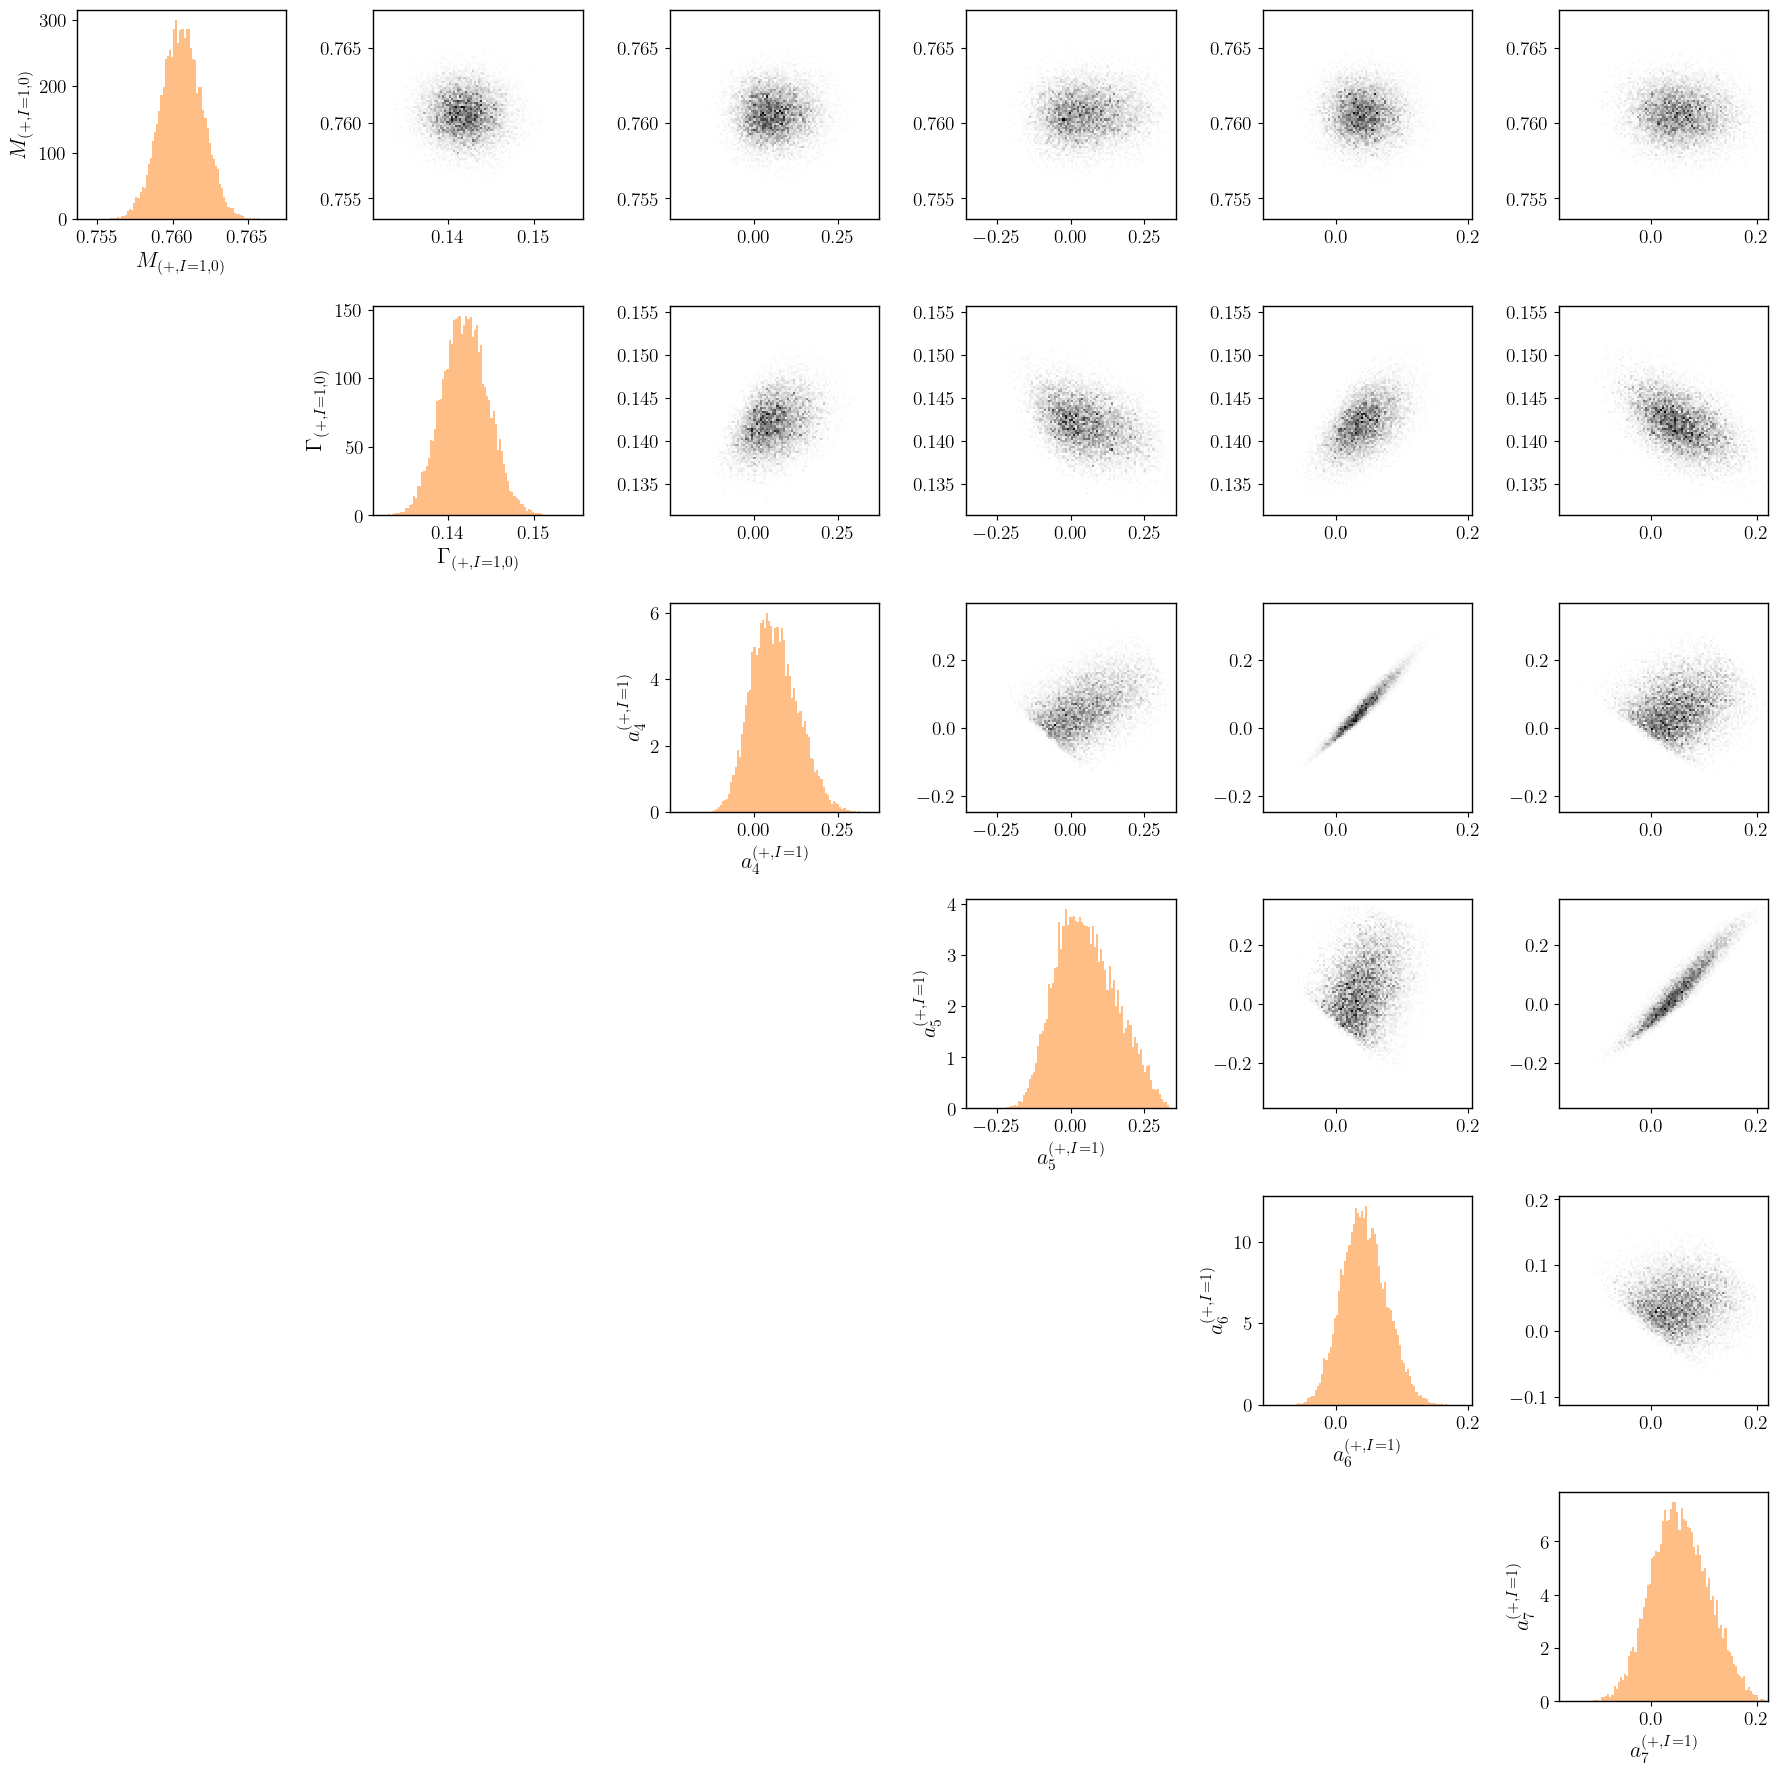

Creating analysis with 6 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 20 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order7-OPAL
Collected 14286 samples


[0.7616622129416892,
 0.1476278000134162,
 0.10391619382768397,
 0.04564061751576087,
 0.06810622766888272,
 0.03327281496085055]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.74662, 'max': 0.77701, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.11970, 'max': 0.17901, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.31176, 'max': 0.57513, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.58715, 'max': 0.65834, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.16085, 'max': 0.32781, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.36136, 'max': 0.39872, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-OP…

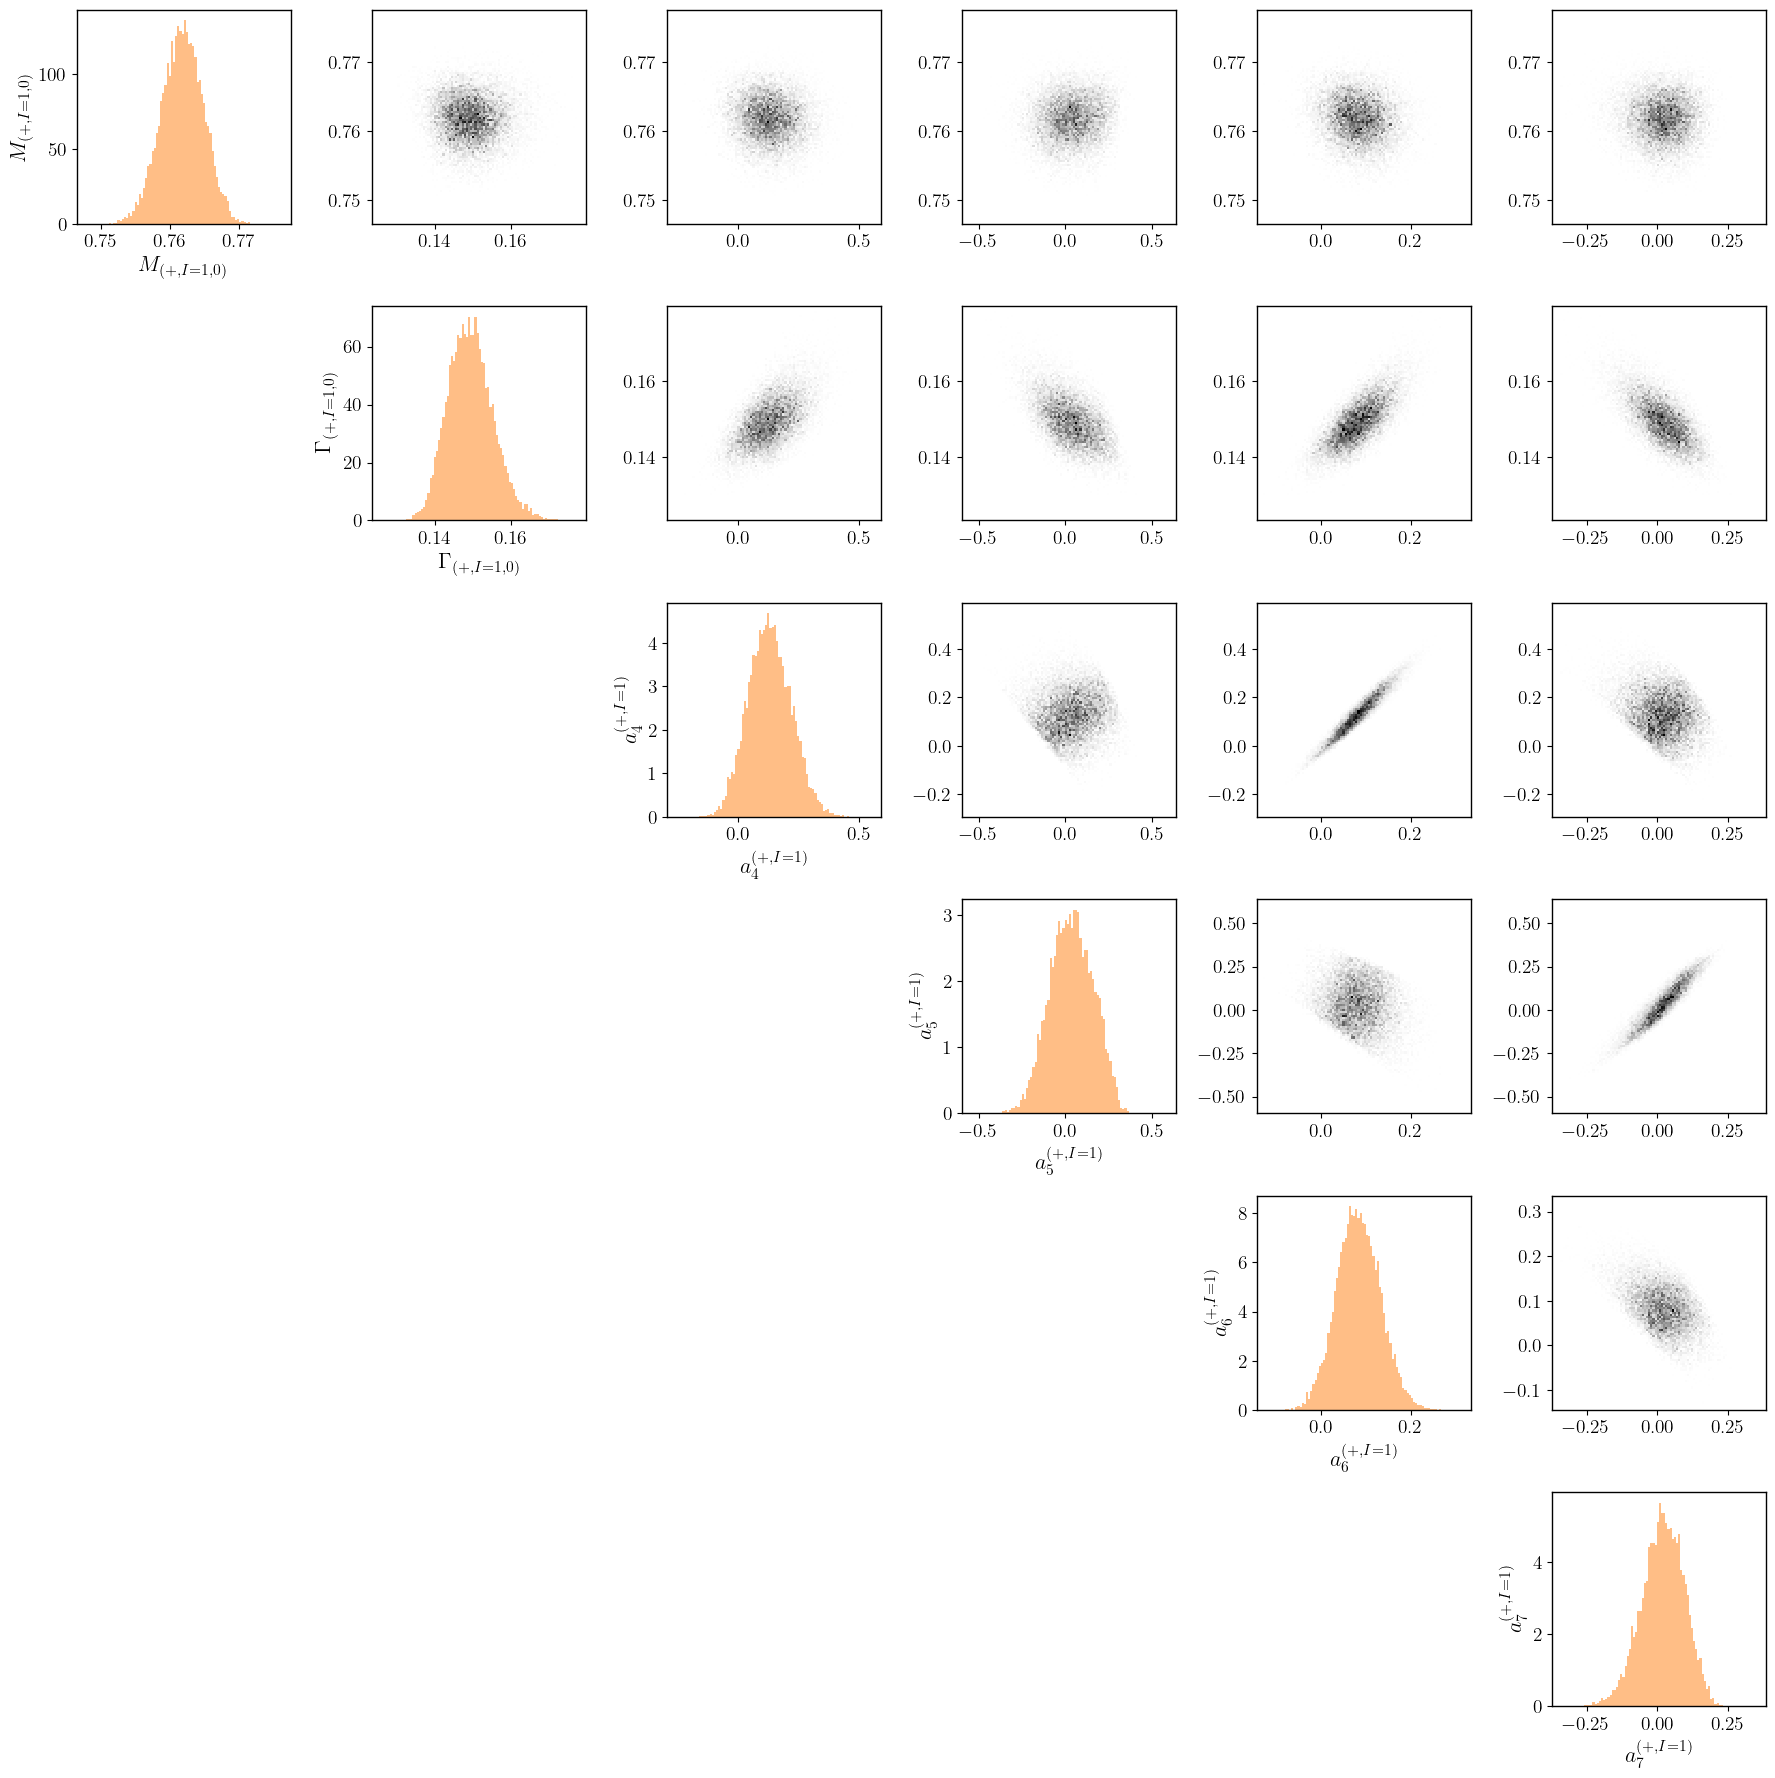

In [37]:
order = 7

fit_results.setdefault(order, {})

for experiment in EXPERIMENTS:
    fit_results[order][experiment] = prepare_fit(
        order,
        experiment,
        resample=resample,
        refit=False,
    )

    show_fit(fit_results[order][experiment])

Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


Belle rho mass  = 0.7631 ± 0.0007 GeV
Belle rho width = 0.1428 ± 0.0008 GeV
CLEO rho mass  = 0.7618 ± 0.0007 GeV
CLEO rho width = 0.1435 ± 0.0017 GeV
ALEPH rho mass  = 0.7606 ± 0.0014 GeV
ALEPH rho width = 0.1420 ± 0.0027 GeV
OPAL rho mass  = 0.7618 ± 0.0030 GeV
OPAL rho width = 0.1494 ± 0.0059 GeV


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


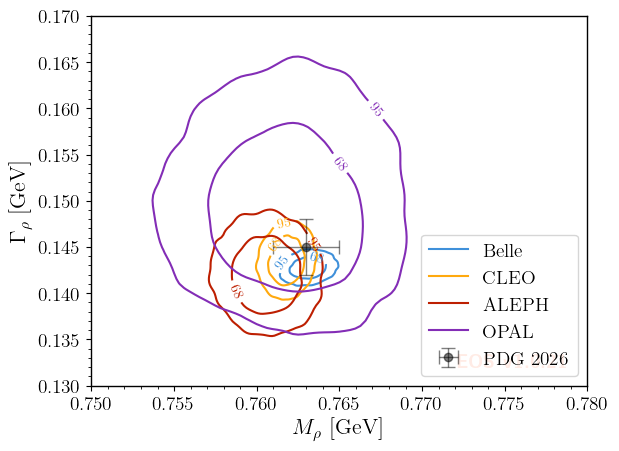

In [43]:
rho_figure_order7 = show_rho_mass_width(order)

Belle dispersive bound is 0.4556 ± 0.0052
CLEO dispersive bound is 0.4581 ± 0.0060
ALEPH dispersive bound is 0.4656 ± 0.0081
OPAL dispersive bound is 0.4535 ± 0.0101


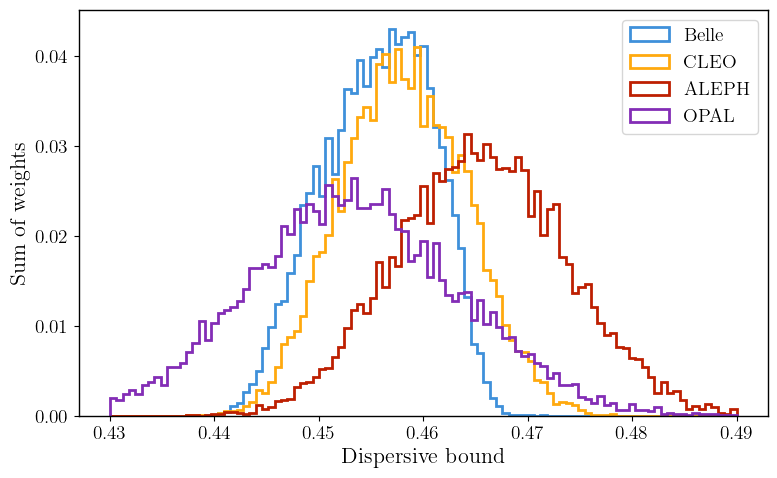

In [44]:
# Use recompute=True if the saved predictions need updating
# after changing samples or prediction definitions.
show_dispersive_bound(order, recompute=resample)

bins = np.linspace(0.43, 0.49, 100)

disp_hist_order7 = plot_dispersive_bound_histogram(
    order=order,
    bins=bins,
)

Belle, order 7: full


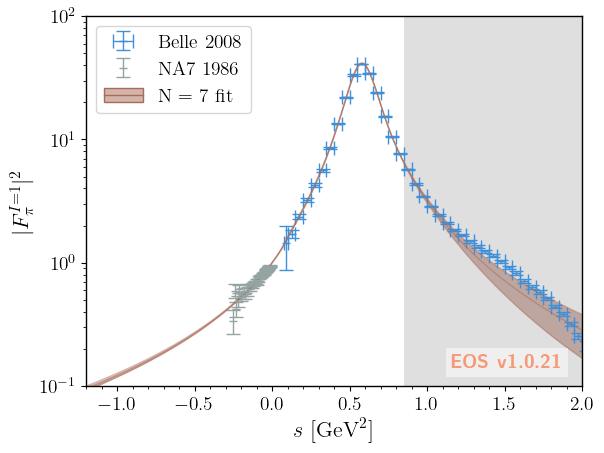

Belle, order 7: zoom


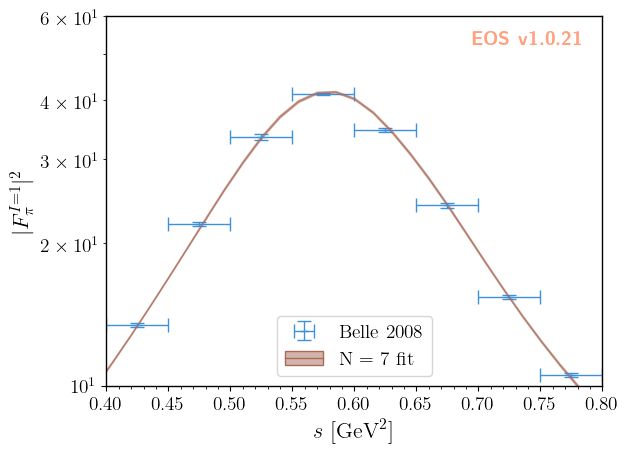

CLEO, order 7: full


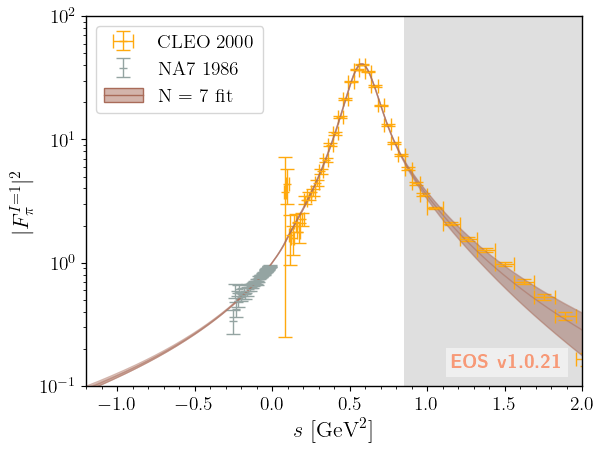

CLEO, order 7: zoom


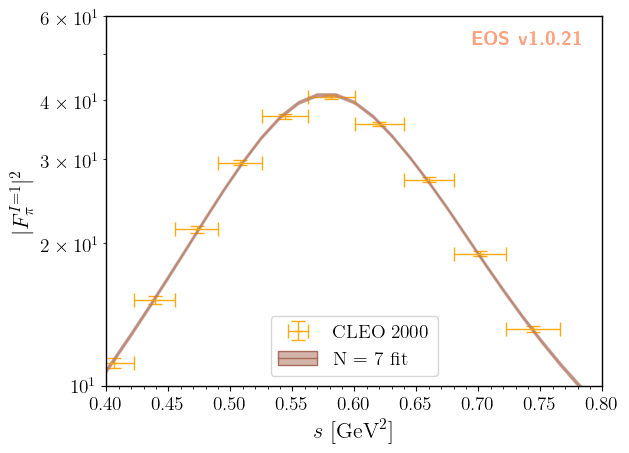

ALEPH, order 7: full


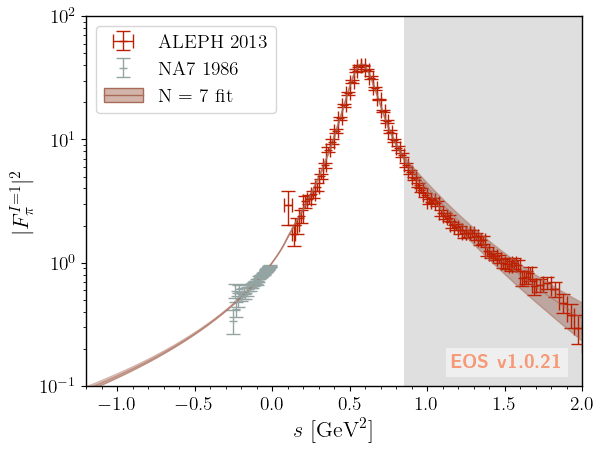

ALEPH, order 7: zoom


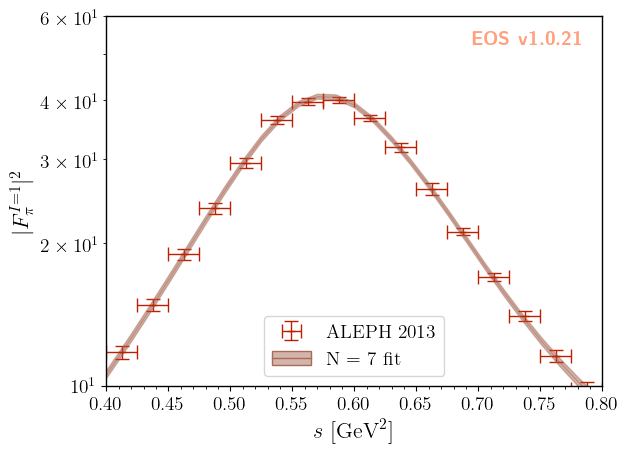

OPAL, order 7: full


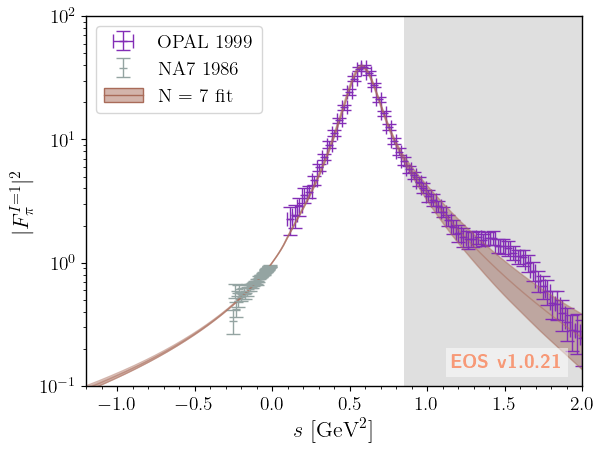

OPAL, order 7: zoom


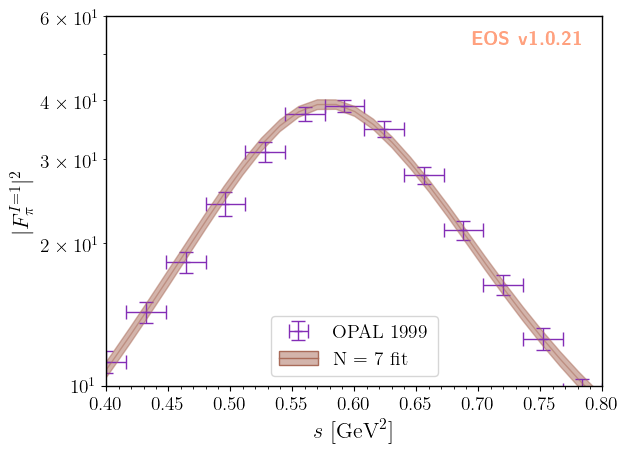

In [45]:
for experiment in EXPERIMENTS:
    plot_form_factor_squared(
        order=order,
        experiment=experiment,
        recompute=resample,
    )

Belle, order 7: residuals at the BFP


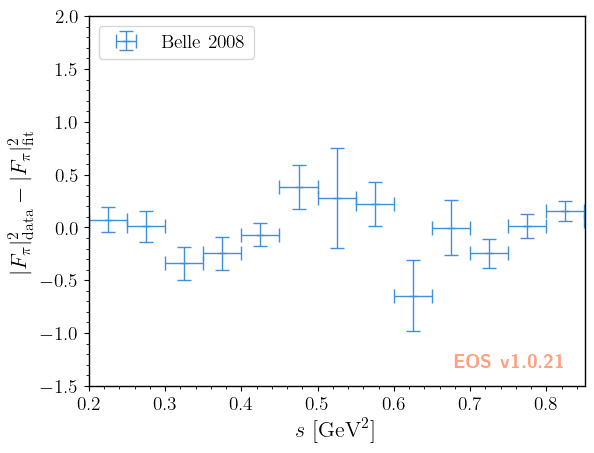

CLEO, order 7: residuals at the BFP


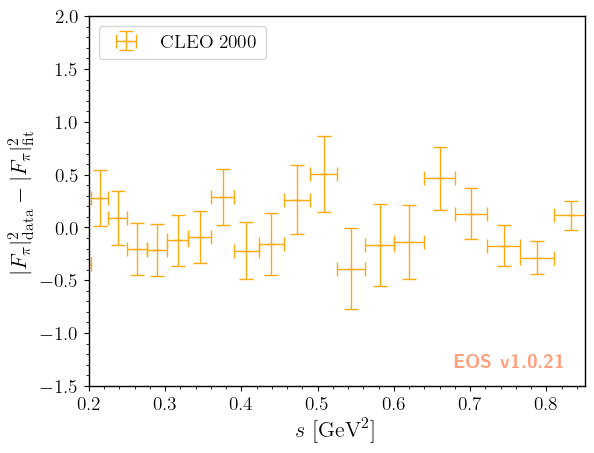

ALEPH, order 7: residuals at the BFP


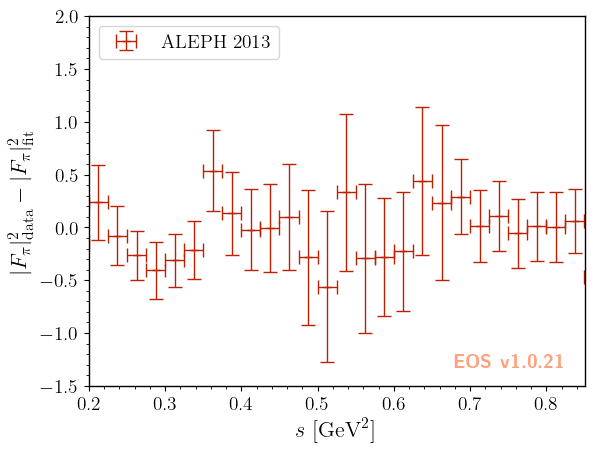

OPAL, order 7: residuals at the BFP


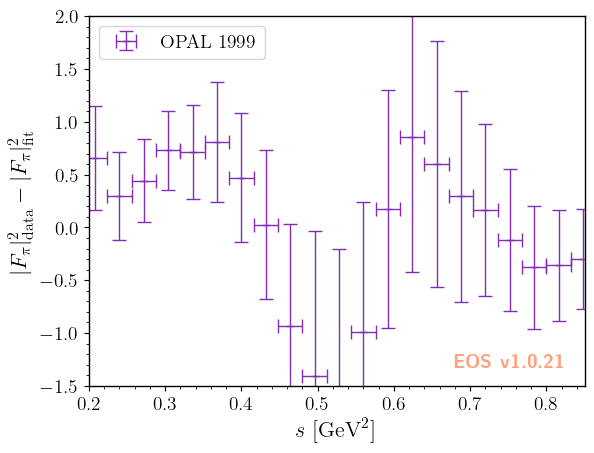

In [46]:
for experiment in EXPERIMENTS:
    plot_form_factor_residuals(
        order=order,
        experiment=experiment,
    )

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


Belle, order 7: phase in the psi plane


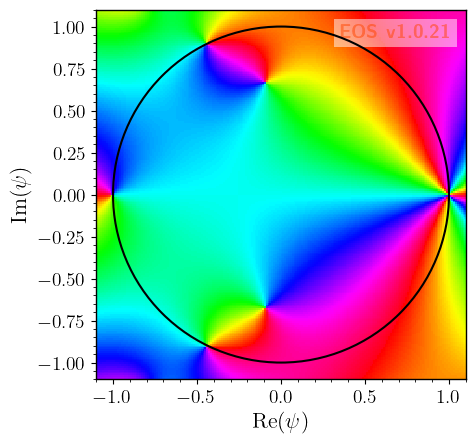

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


CLEO, order 7: phase in the psi plane


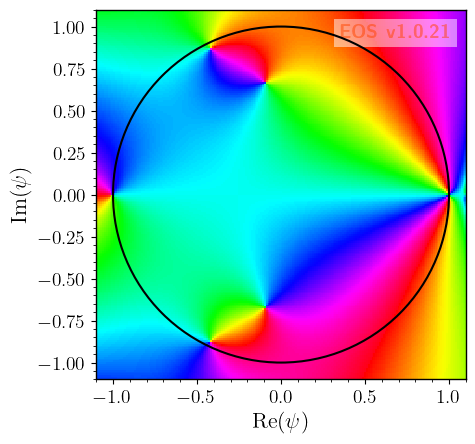

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


ALEPH, order 7: phase in the psi plane


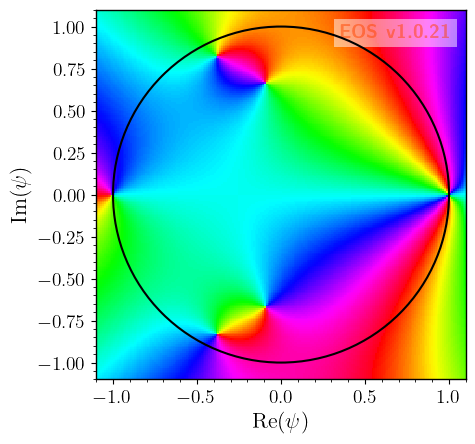

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


OPAL, order 7: phase in the psi plane


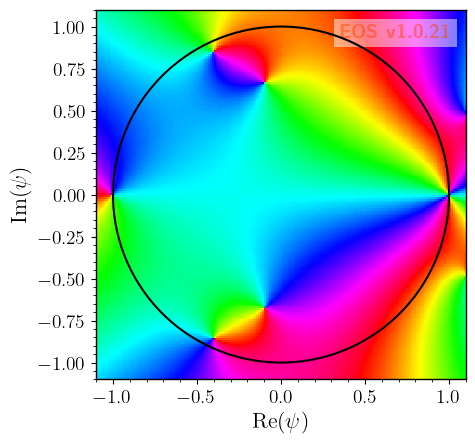

In [47]:
for experiment in EXPERIMENTS:
    plot_psi_phase(
        order=order,
        experiment=experiment,
        resolution=200,
    )

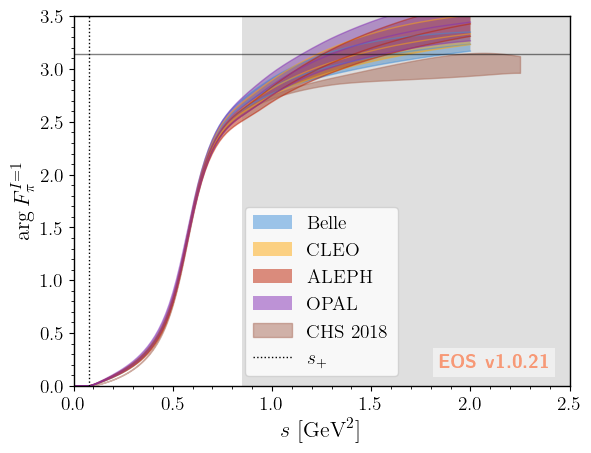

In [48]:
phase_figure_order7 = plot_timelike_phase(
    order=order,
    recompute=resample,
)

Belle, order 7: full


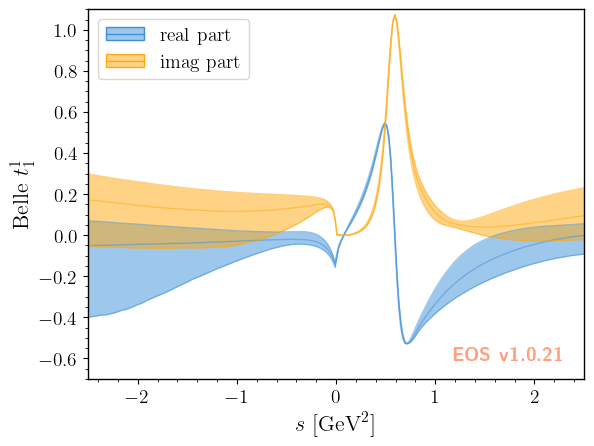

Belle, order 7: near zero


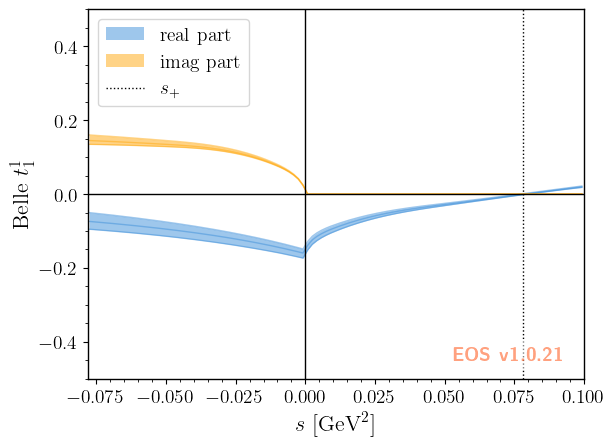

Belle, order 7: threshold


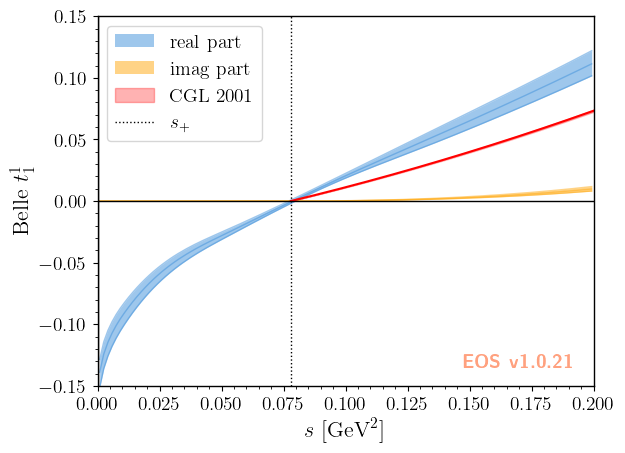

CLEO, order 7: full


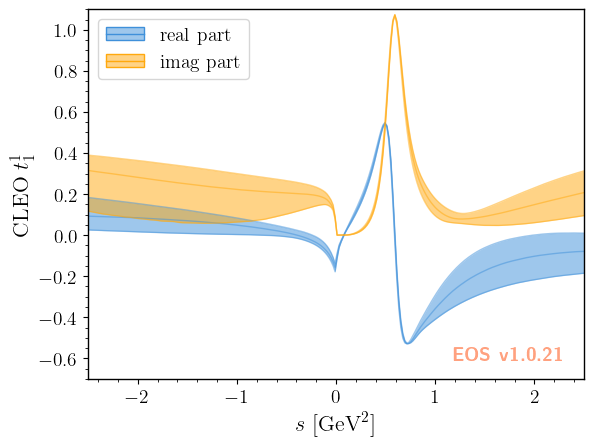

CLEO, order 7: near zero


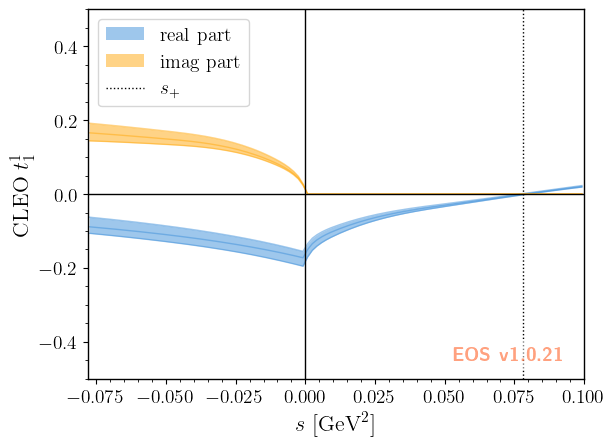

CLEO, order 7: threshold


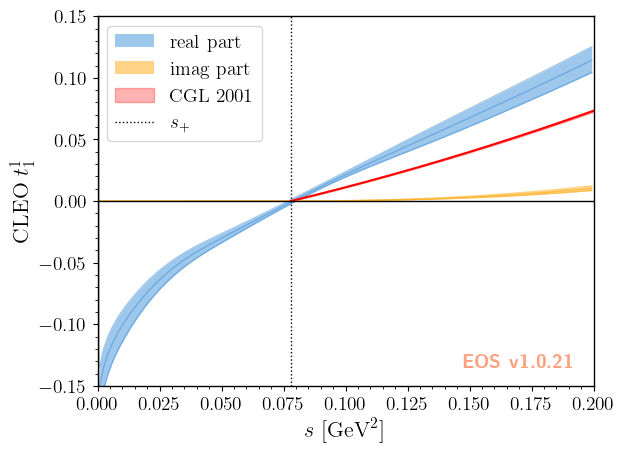

ALEPH, order 7: full


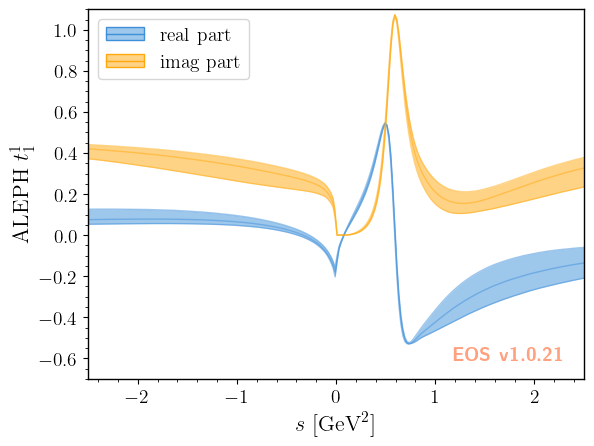

ALEPH, order 7: near zero


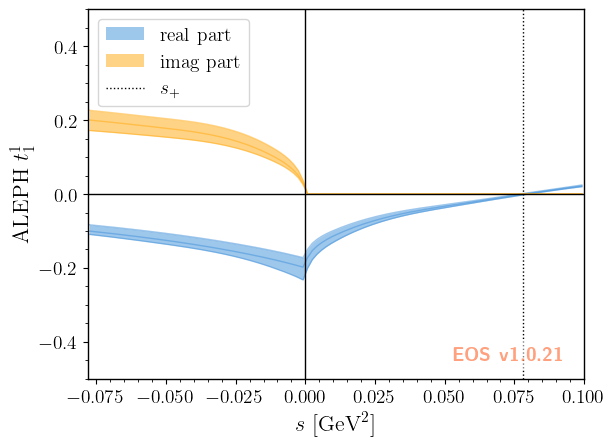

ALEPH, order 7: threshold


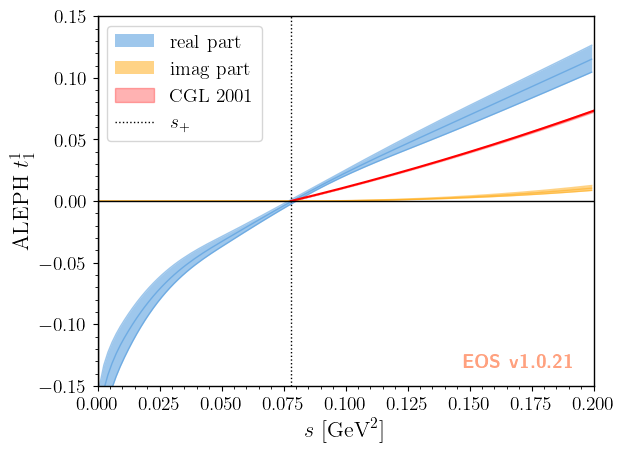

OPAL, order 7: full


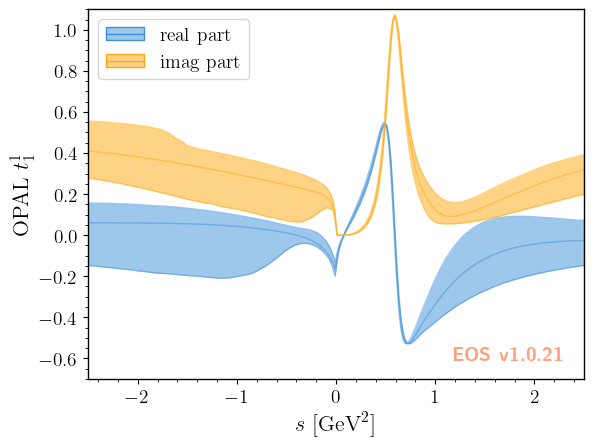

OPAL, order 7: near zero


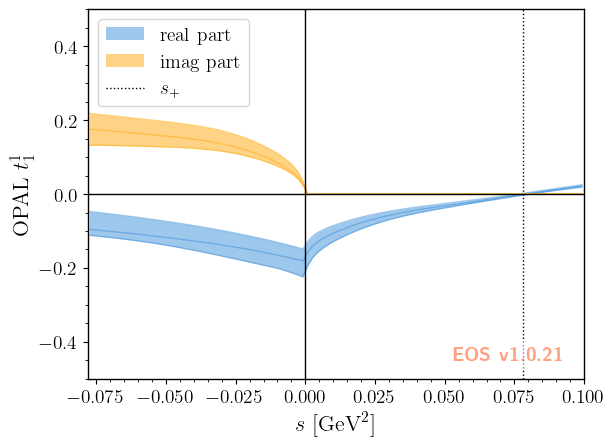

OPAL, order 7: threshold


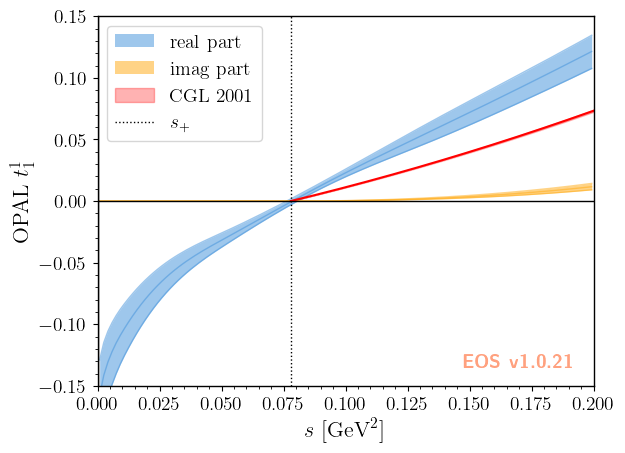

In [49]:
for experiment in EXPERIMENTS:
    plot_partial_waves(
        order=order,
        experiment=experiment,
        theory_band=partial_wave_theory,
        recompute=resample,
    )

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


Belle a11 = 0.0737 ± 0.0080
Belle b11 = -0.0079 ± 0.0012
CLEO a11 = 0.0781 ± 0.0093
CLEO b11 = -0.0102 ± 0.0024
ALEPH a11 = 0.0840 ± 0.0101
ALEPH b11 = -0.0147 ± 0.0033
OPAL a11 = 0.0822 ± 0.0137
OPAL b11 = -0.0101 ± 0.0057


Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


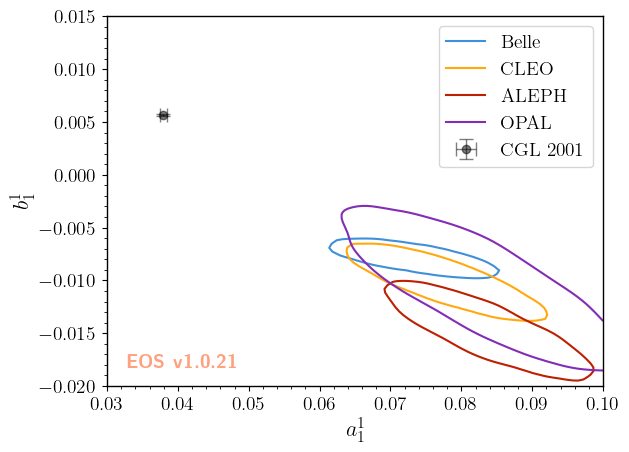

In [50]:
show_scattering_lengths(
    order=order,
    recompute=resample,
)

sl_figure_order7 = plot_scattering_lengths(
    order=order,
    xrange=(0.03, 0.1),
    yrange=(-0.02, 0.015),
)

In [51]:
show_charge_radius(
    order=order,
    recompute=resample,
)

Belle <r^2> = 0.4396 ± 0.0054 fm^2
CLEO <r^2> = 0.4411 ± 0.0054 fm^2
ALEPH <r^2> = 0.4411 ± 0.0057 fm^2
OPAL <r^2> = 0.4457 ± 0.0061 fm^2


In [52]:
export_rho_residues_psi(
    order=order,
    recompute=resample,
)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-Be…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-Be…

Belle: exported 14716 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_Belle7.wl


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-CL…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-CL…

...

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-AL…

ALEPH: exported 14020 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_ALEPH7.wl


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-OP…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order7-OP…

OPAL: exported 14286 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_OPAL7.wl


In [53]:
show_rho_couplings(order=order)

Belle: g_rho_gamma = (4.9009 ± 0.0101) + i * (-0.2614 ± 0.0171)
Belle: g_rho_pi_pi = (5.9492 ± 0.0480) + i * (-0.0960 ± 0.1808)
CLEO: g_rho_gamma = (4.9260 ± 0.0253) + i * (-0.2427 ± 0.0160)
CLEO: g_rho_pi_pi = (5.9331 ± 0.0780) + i * (-0.1776 ± 0.1649)
ALEPH: g_rho_gamma = (4.9885 ± 0.0359) + i * (-0.2103 ± 0.0249)
ALEPH: g_rho_pi_pi = (5.8008 ± 0.1135) + i * (-0.3945 ± 0.1843)
OPAL: g_rho_gamma = (4.9436 ± 0.0672) + i * (-0.2393 ± 0.0384)
OPAL: g_rho_pi_pi = (6.0788 ± 0.2294) + i * (-0.1137 ± 0.2876)


## order 8

Creating analysis with 1 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order8-Belle
Collected 13629 samples


[0.7640054267943055,
 0.1430711523739591,
 0.06730448244807644,
 -0.22084859683855038,
 0.4418063800332138,
 -0.11236716258934631,
 0.2597133194688285]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.76045, 'max': 0.76685, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.14003, 'max': 0.14650, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.21411, 'max': 0.38334, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.64773, 'max': 0.34064, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.47760, 'max': 0.98805, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.29925, 'max': 0.13485, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min': -0.38641, 'max': 0.64739, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-Be…

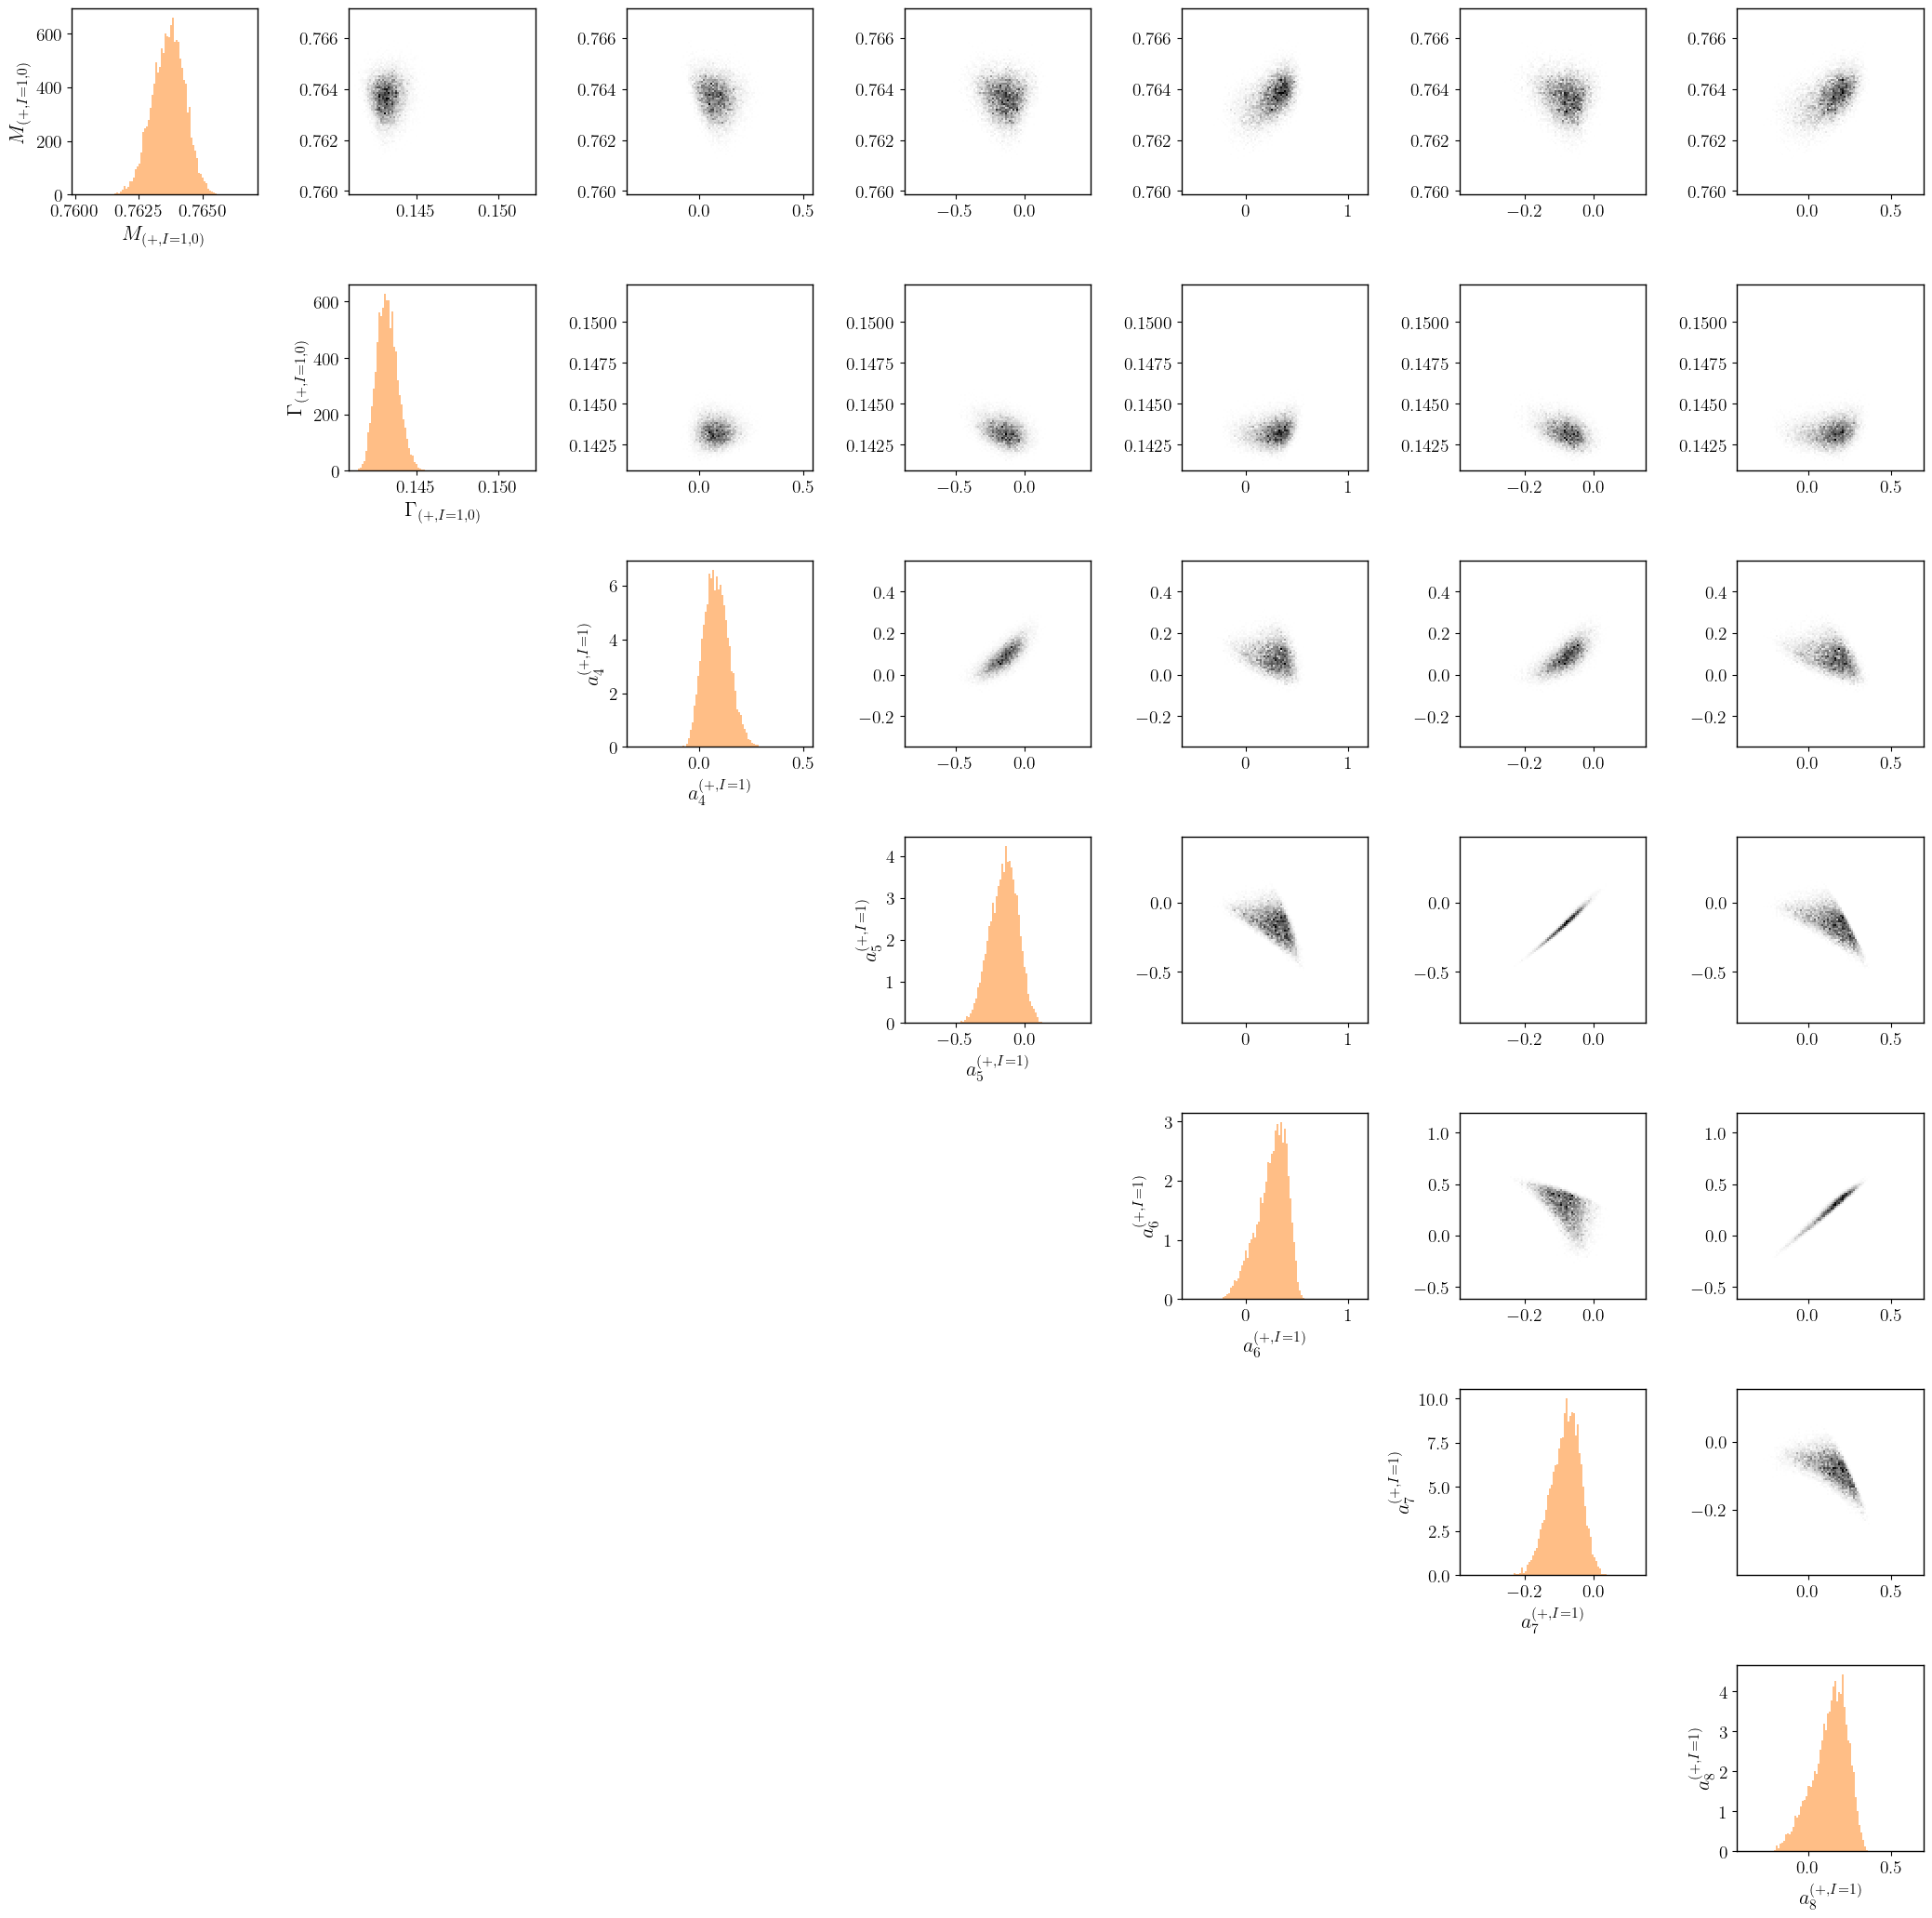

FF-fp-I1-order8-Belle: rotation diagnostics
Original parameter order:
p1: 0->pipi::M_(+,1,0)@BHKMNR2026
p2: 0->pipi::Gamma_(+,1,0)@BHKMNR2026
p3: 0->pipi::a_(+,1)^4@BHKMNR2026
p4: 0->pipi::a_(+,1)^5@BHKMNR2026
p5: 0->pipi::a_(+,1)^6@BHKMNR2026
p6: 0->pipi::a_(+,1)^7@BHKMNR2026
p7: 0->pipi::a_(+,1)^8@BHKMNR2026


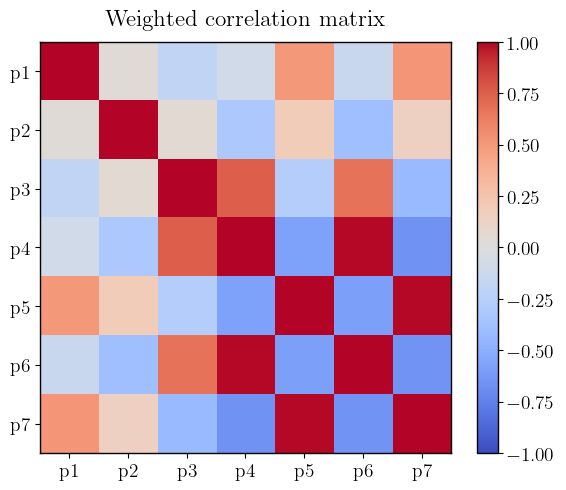

Transformation back to original parameters:


array([[ 1.34393062e-04, -5.17716637e-05, -1.00005599e-04,
         4.68022568e-04, -1.36406874e-04,  1.70819215e-04,
         3.34374432e-04],
       [ 0.00000000e+00,  2.35798446e-04, -4.57854010e-04,
         5.86815385e-05,  2.81803923e-04, -2.47497845e-04,
         9.38555826e-05],
       [ 0.00000000e+00,  0.00000000e+00,  1.34878602e-03,
         4.56422320e-03,  4.39742481e-02,  3.10120640e-02,
        -2.55290766e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.07886882e-02,  1.08160616e-02,  7.26430429e-02,
        -6.52632419e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.26757003e-02,  1.08848364e-02,
         1.44396876e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  3.28644111e-02,
        -2.83640458e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.0338471

Shift: zero, matching your original convention.
Lower bounds in transformed coordinates:


array([ 5.90810613e+03,  5.87341099e+02, -9.55316241e+00, -5.99611716e+00,
       -1.10414521e+00, -6.41150439e+00, -3.73757145e+00])

Upper bounds in transformed coordinates:


array([5.91810565e+03, 5.97340622e+02, 4.46360342e-01, 4.00340559e+00,
       8.89537755e+00, 3.58801845e+00, 6.26195038e+00])

Best-fit point in transformed coordinates:


array([ 5.91297733e+03,  5.92338564e+02, -3.83761934e+00, -9.48418793e-01,
        4.08733588e+00, -1.25100927e+00,  2.51210565e+00])

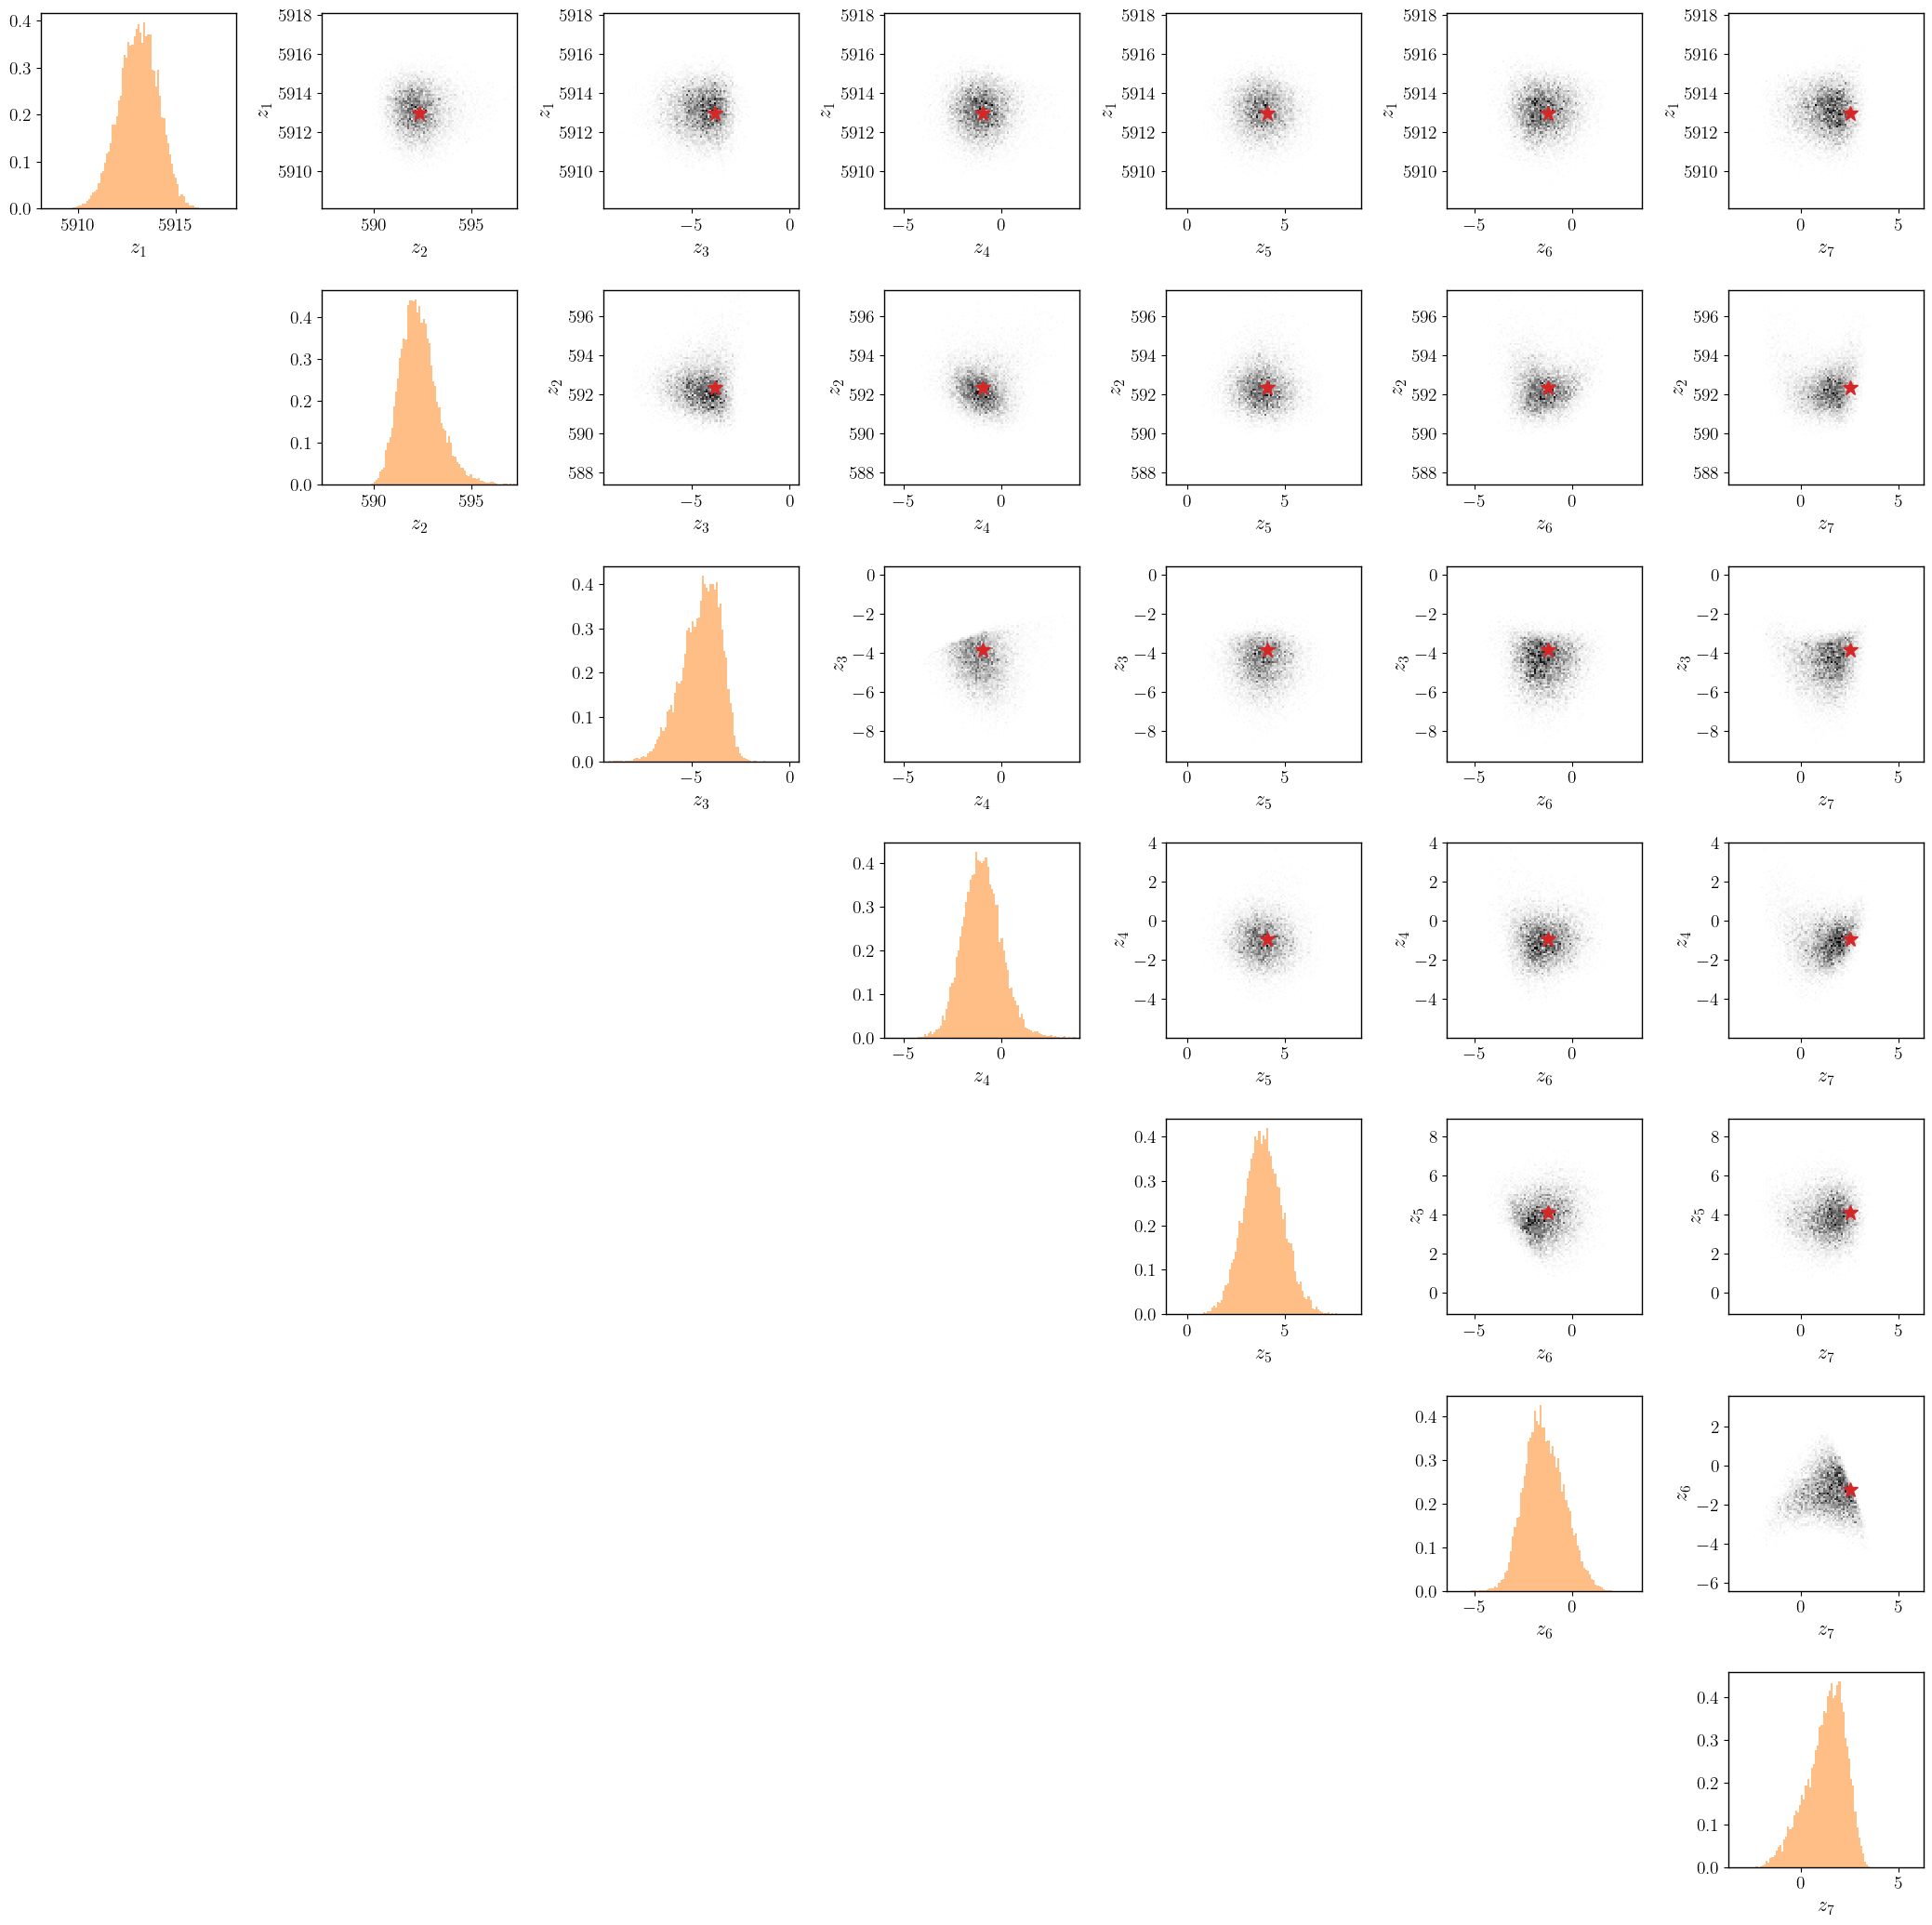

Creating analysis with 7 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order8-CLEO
Collected 16257 samples


[0.762177889894074,
 0.1435453470265024,
 0.07303352761976684,
 -0.1082470021824321,
 0.3063466393024039,
 -0.043931351344082215,
 0.16878749953156624]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75813, 'max': 0.76576, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.13496, 'max': 0.15221, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.23925, 'max': 0.44019, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.66307, 'max': 0.57284, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.89280, 'max': 1.09407, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.30699, 'max': 0.26515, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min': -0.67179, 'max': 0.71968, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-CL…

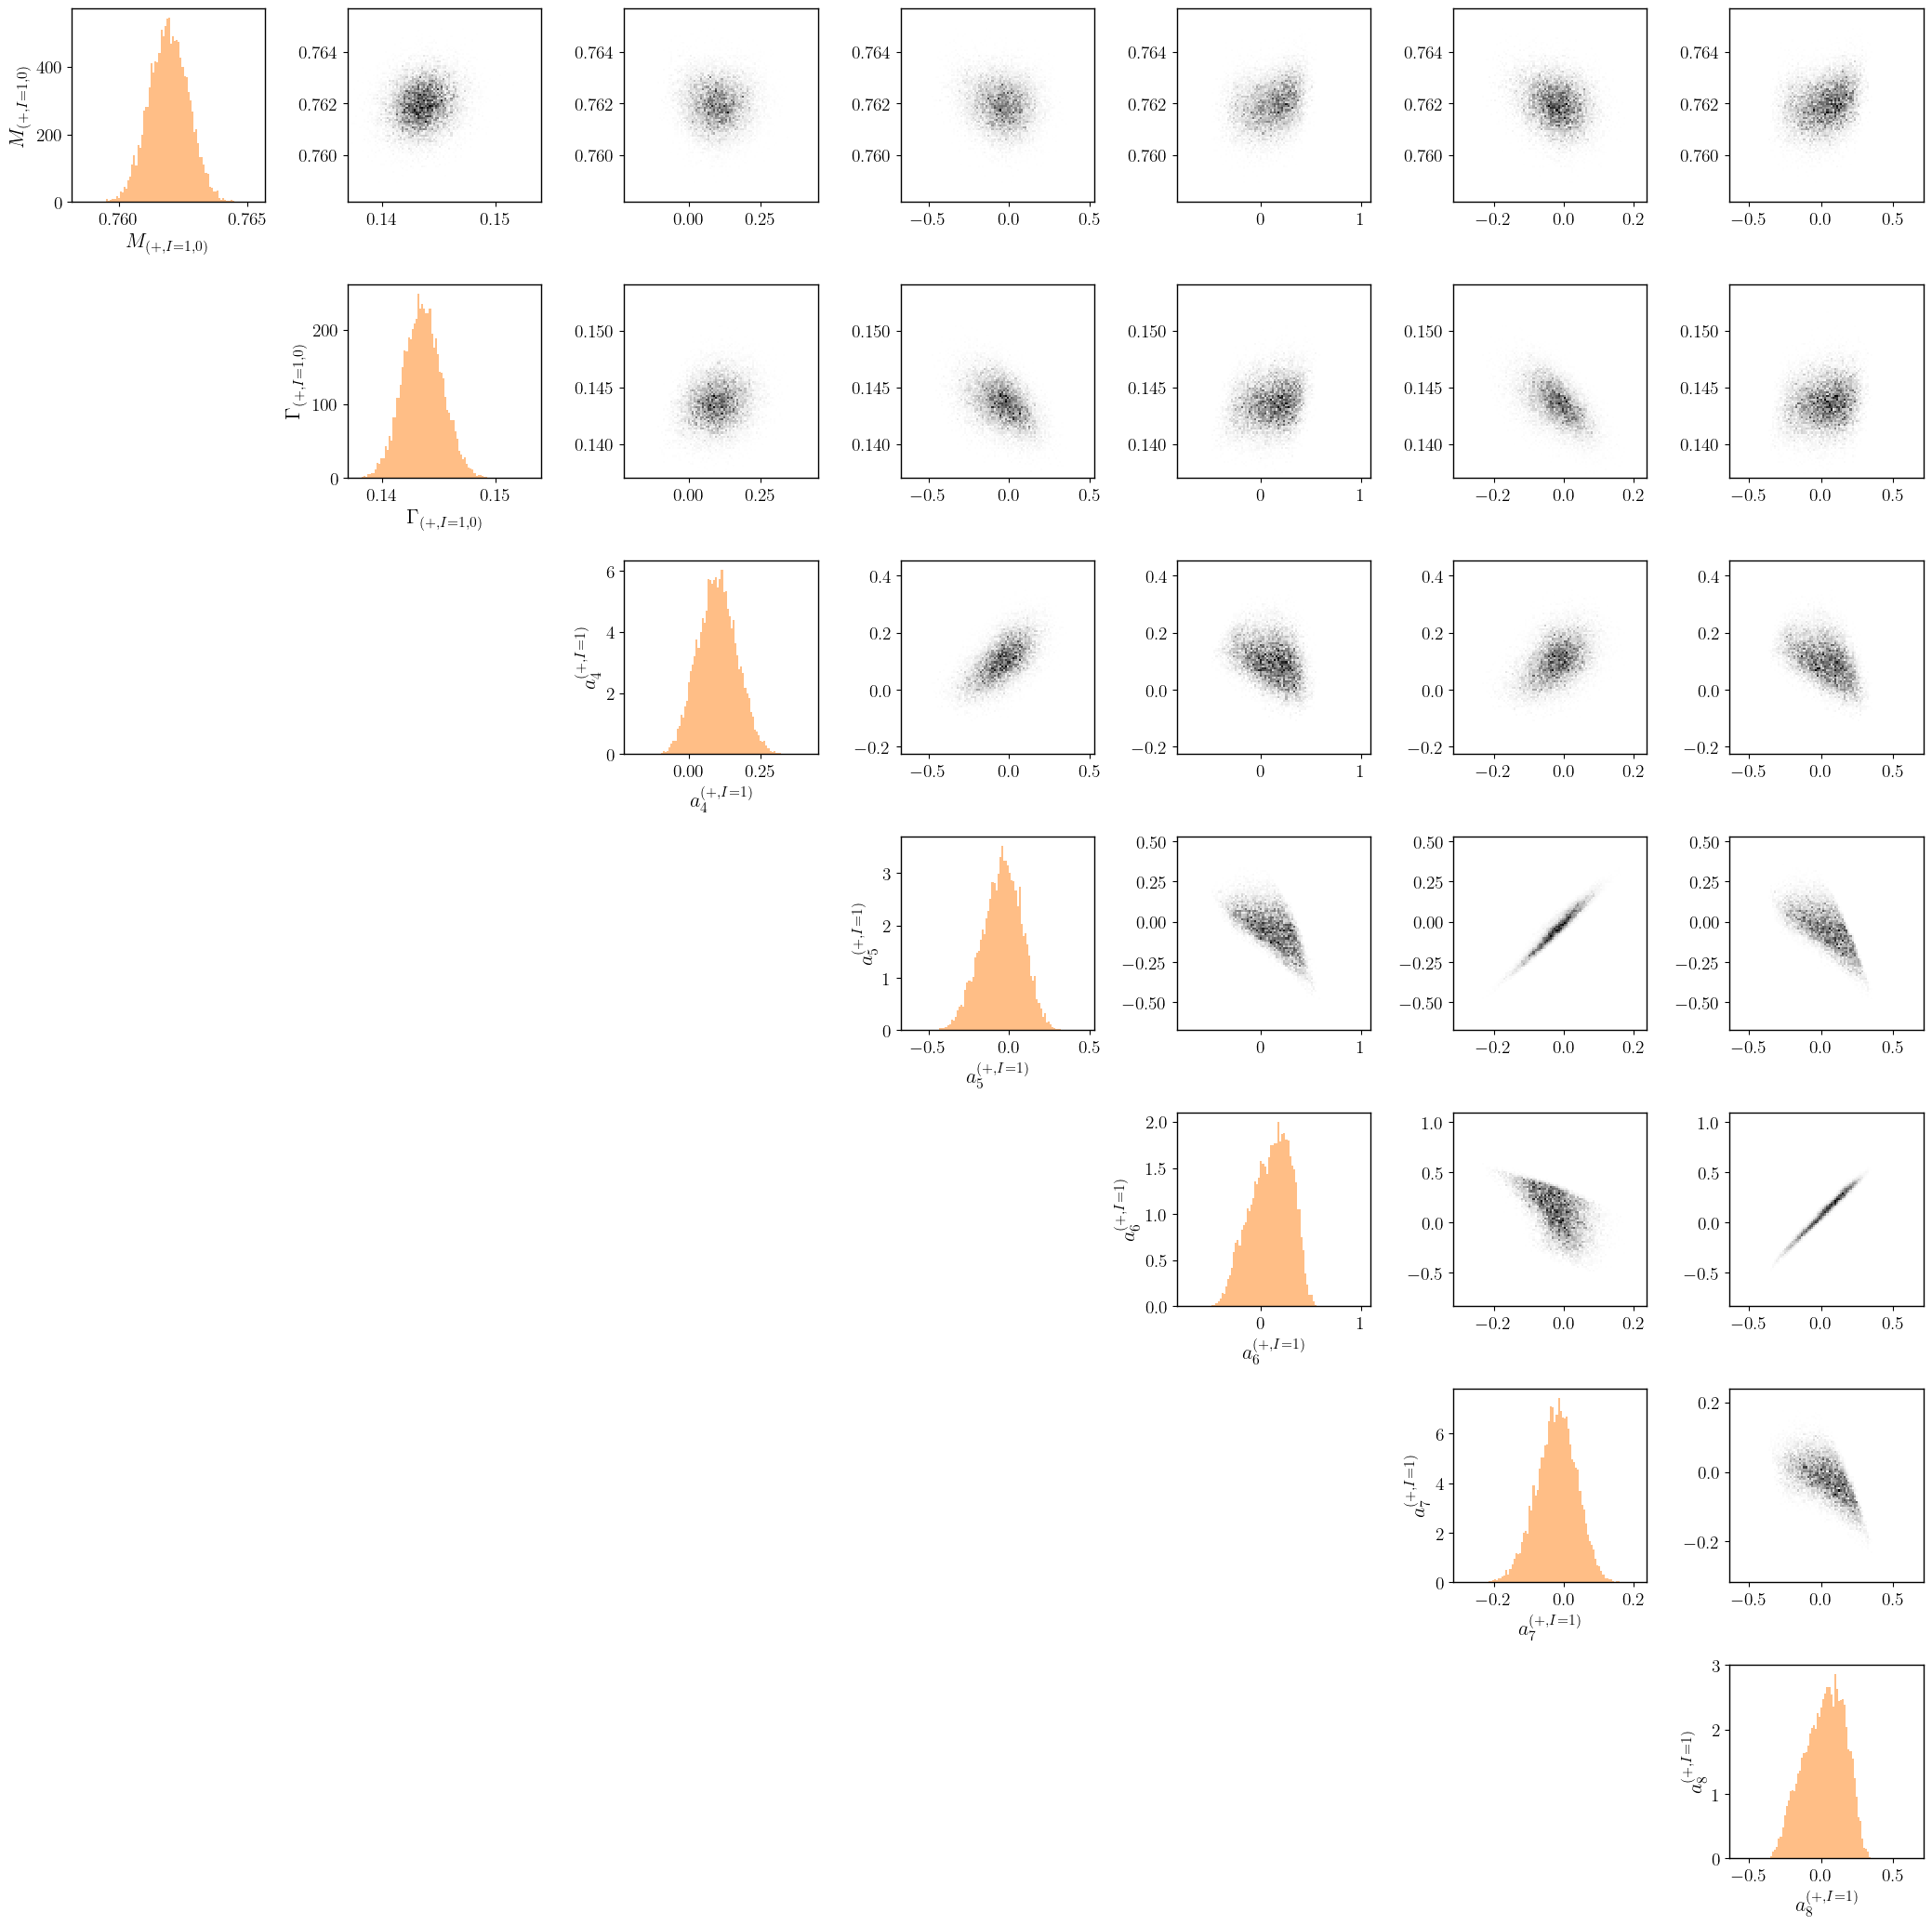

Creating analysis with 7 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order8-ALEPH
Collected 15202 samples


[0.7602142522706171,
 0.14186115810504232,
 0.030262872016885656,
 0.043691800551177384,
 -0.1869976474869124,
 0.05223445730125703,
 -0.14444572716449888]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.75348, 'max': 0.76769, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.12840, 'max': 0.15559, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.27241, 'max': 0.40802, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.56277, 'max': 0.68534, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -0.99737, 'max': 0.95286, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.26414, 'max': 0.37488, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min': -0.71983, 'max': 0.63037, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-AL…

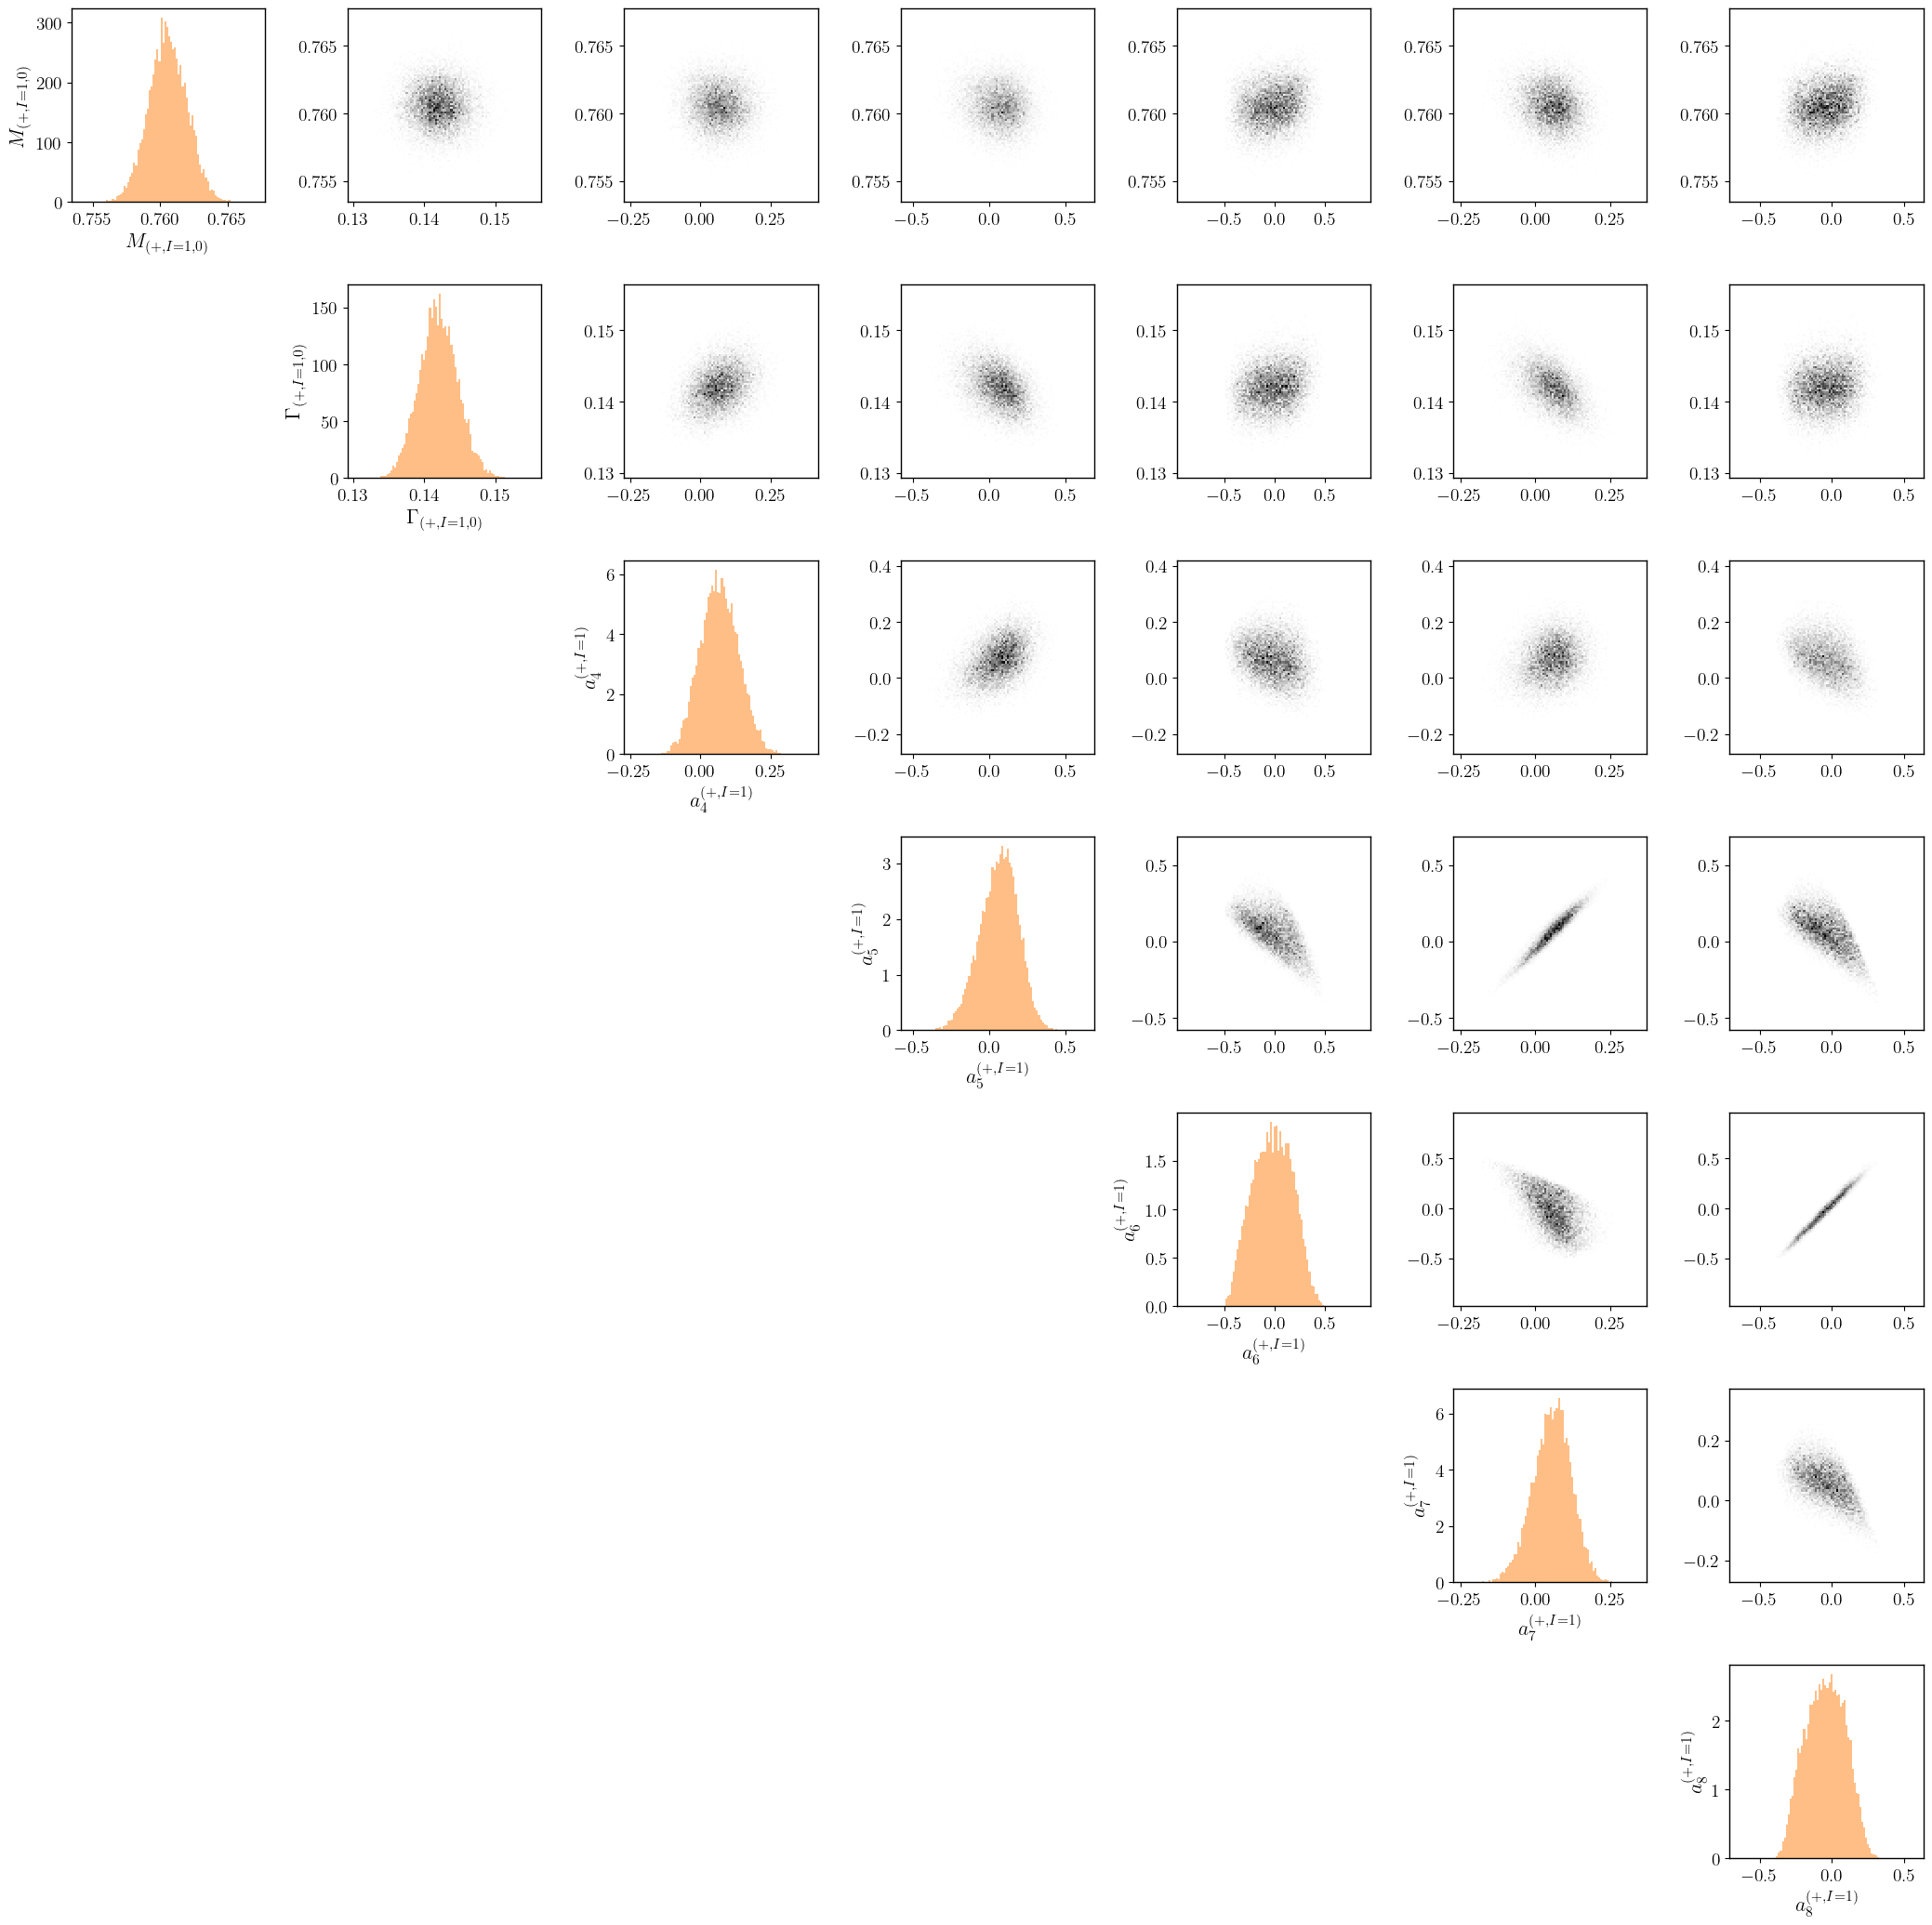

Creating analysis with 7 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 19 parameter(s) that do not appear in the prior; check prior?


FF-fp-I1-order8-OPAL
Collected 15135 samples


[0.7612970819744542,
 0.14790753869066062,
 0.10038487051972533,
 0.06013164784948033,
 -0.2719658187171967,
 0.02921979071435482,
 -0.22596245691778705]

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min': 0.74659, 'max': 0.77703, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min': 0.12018, 'max': 0.17836, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min': -0.29173, 'max': 0.55303, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min': -0.69886, 'max': 0.76135, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min': -1.03345, 'max': 1.07594, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min': -0.41152, 'max': 0.43677, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min': -0.74019, 'max': 0.65864, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-OP…

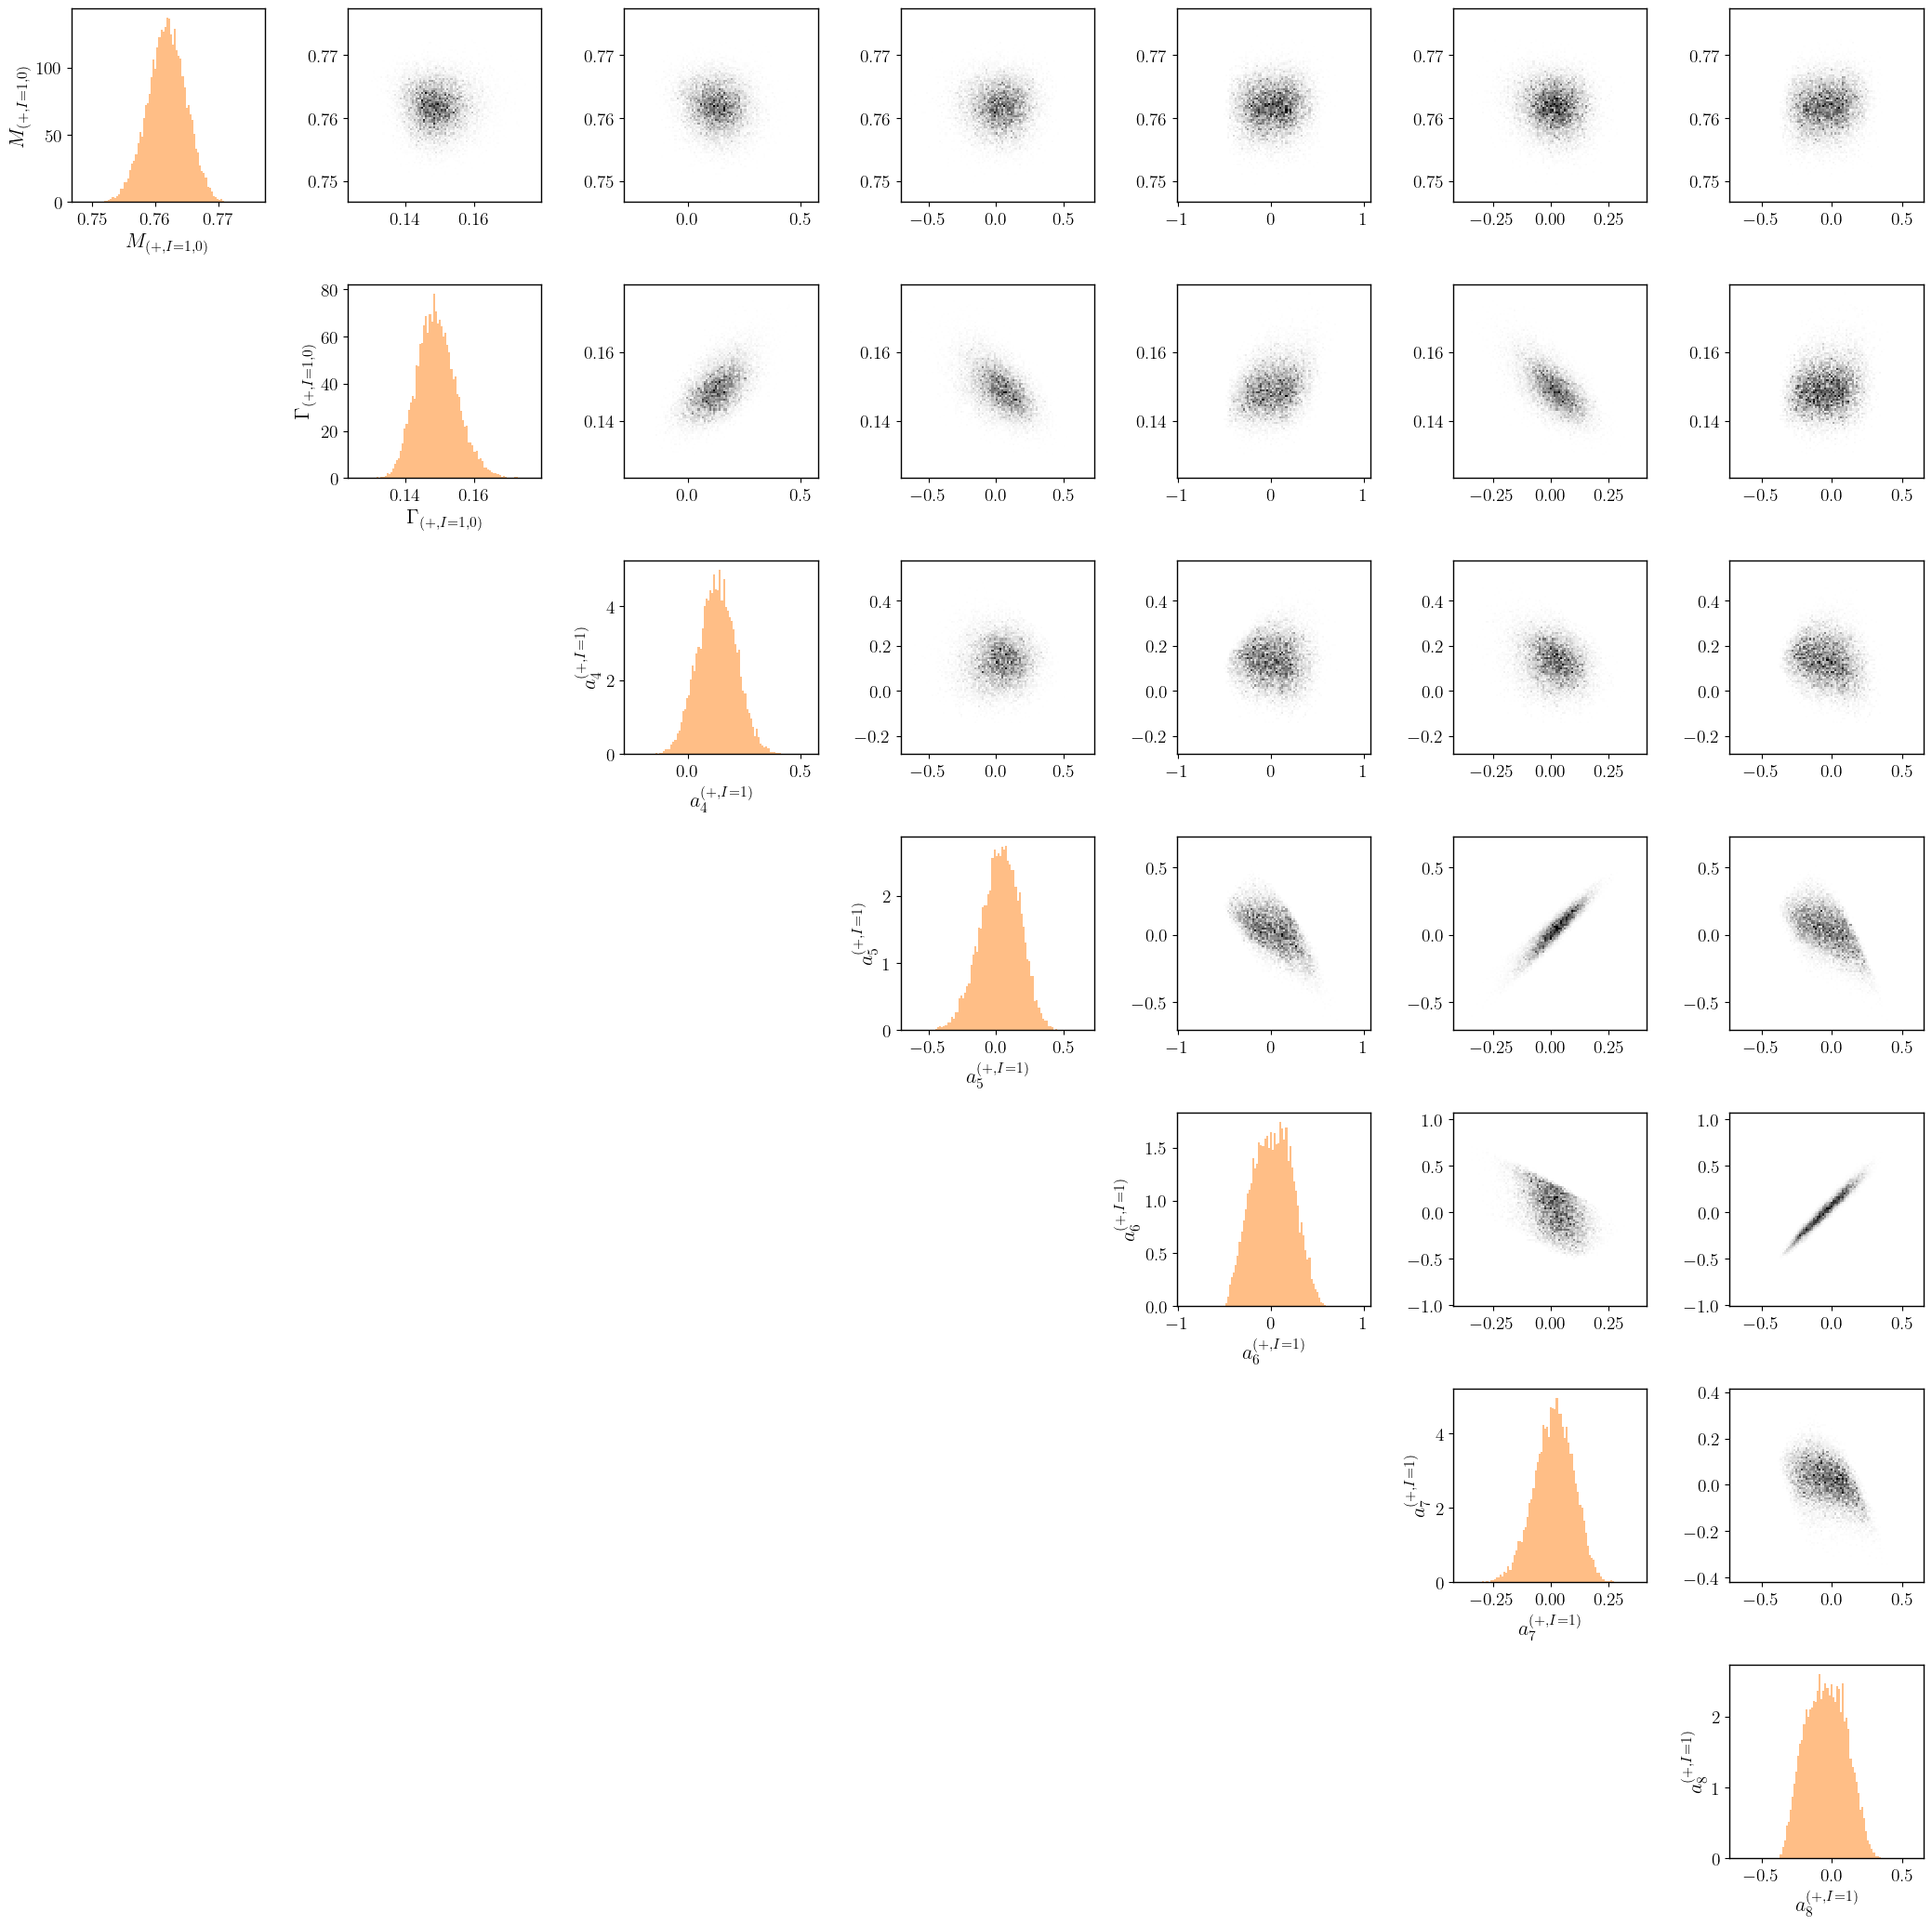

In [102]:
order = 8
fit_results.setdefault(order, {})

for experiment in EXPERIMENTS:
    result = prepare_fit(
        order,
        experiment,
        resample=resample,
        refit=False,
    )

    fit_results[order][experiment] = result

    show_fit(
        result,
        rotate=(order == 8 and experiment == "Belle"),
    )

Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


Belle rho mass  = 0.7637 ± 0.0006 GeV
Belle rho width = 0.1433 ± 0.0006 GeV
CLEO rho mass  = 0.7619 ± 0.0008 GeV
CLEO rho width = 0.1436 ± 0.0017 GeV
ALEPH rho mass  = 0.7606 ± 0.0014 GeV
ALEPH rho width = 0.1420 ± 0.0027 GeV
OPAL rho mass  = 0.7618 ± 0.0030 GeV
OPAL rho width = 0.1493 ± 0.0058 GeV


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'
Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


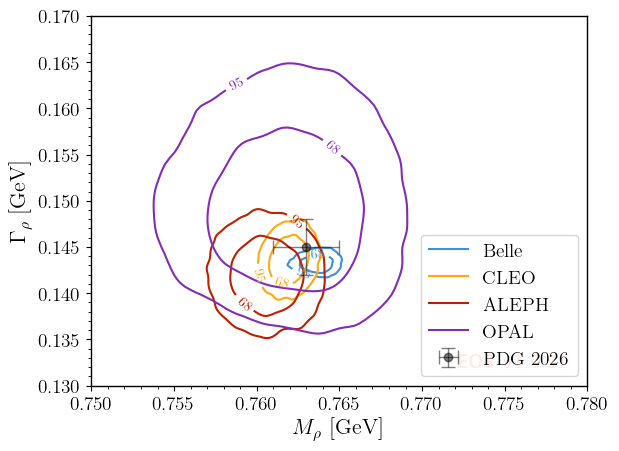

In [55]:
rho_figure_order8 = show_rho_mass_width(order)

Belle dispersive bound is 0.4813 ± 0.0218
CLEO dispersive bound is 0.4667 ± 0.0237
ALEPH dispersive bound is 0.4624 ± 0.0216
OPAL dispersive bound is 0.4521 ± 0.0201


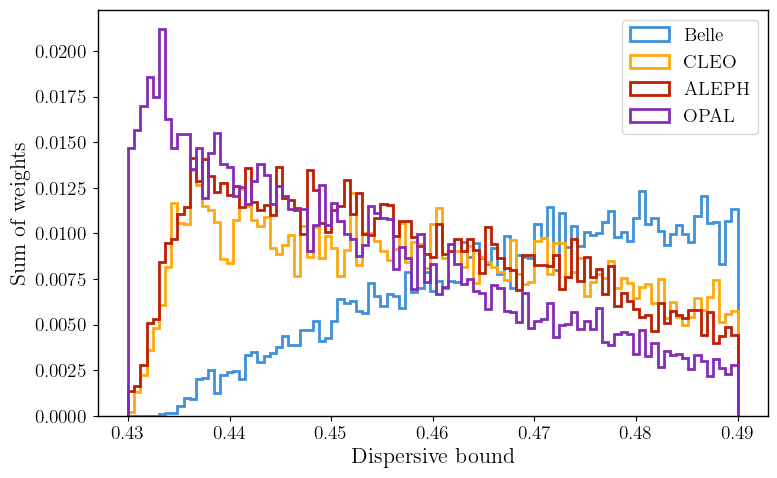

In [56]:
# Use recompute=True if the saved predictions need updating
# after changing samples or prediction definitions.
show_dispersive_bound(order, recompute=resample)

bins = np.linspace(0.43, 0.49, 100)

disp_hist_order8 = plot_dispersive_bound_histogram(
    order=order,
    bins=bins,
)

Belle, order 8: full


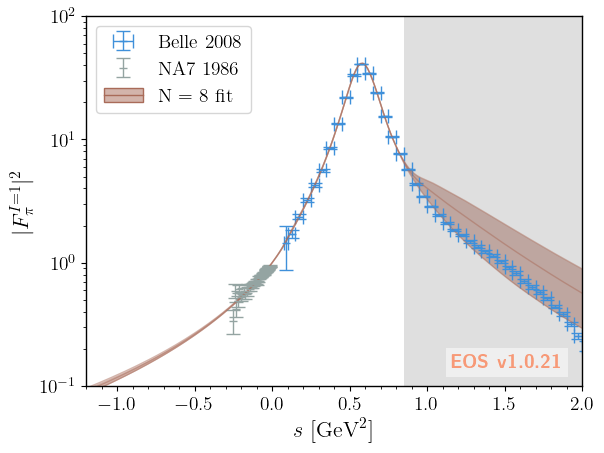

Belle, order 8: zoom


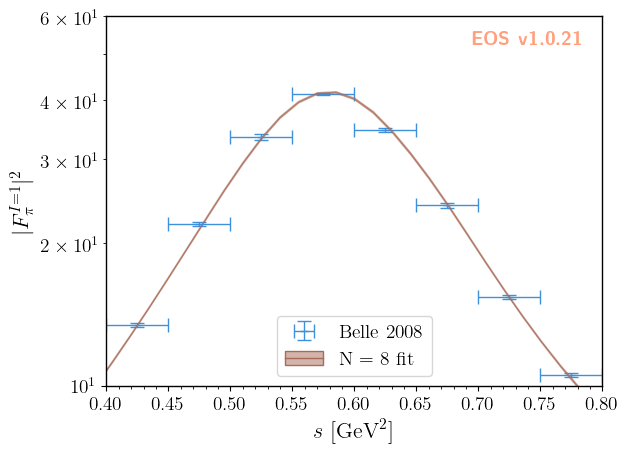

CLEO, order 8: full


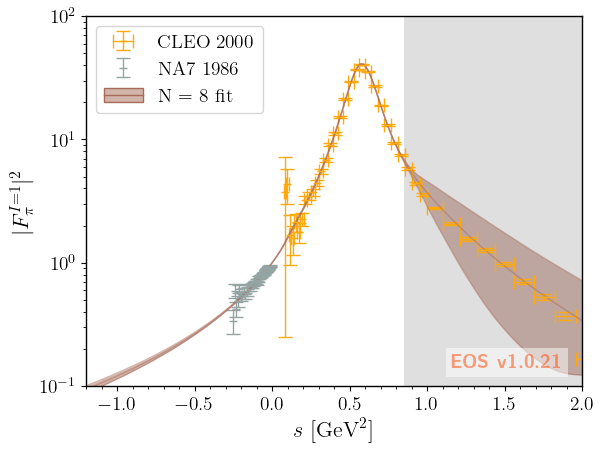

CLEO, order 8: zoom


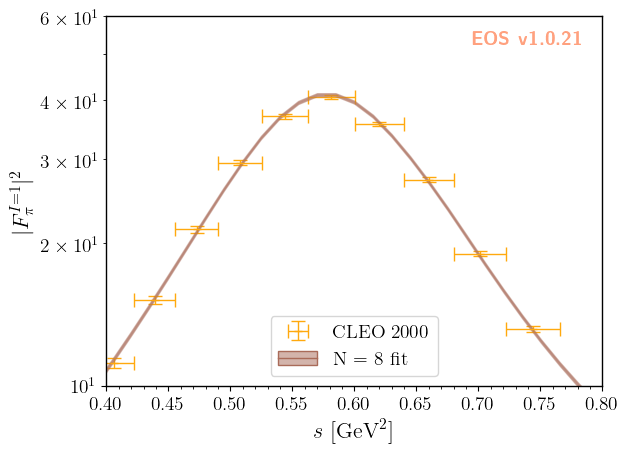

ALEPH, order 8: full


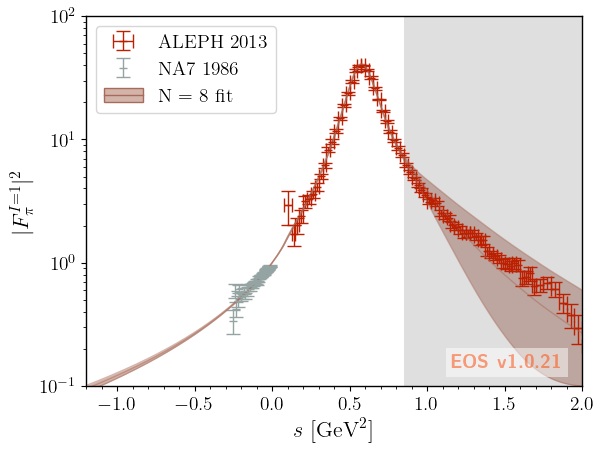

ALEPH, order 8: zoom


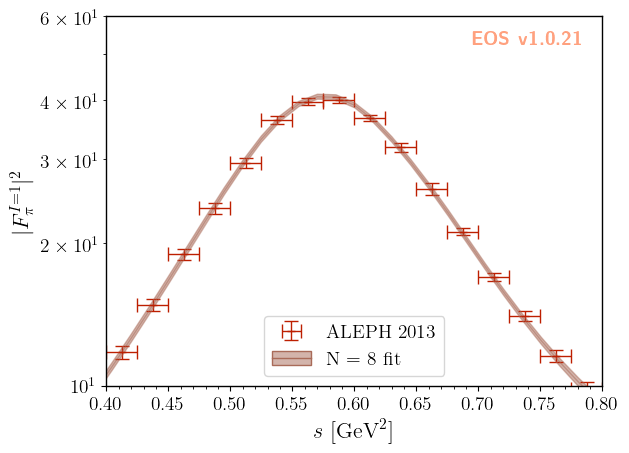

OPAL, order 8: full


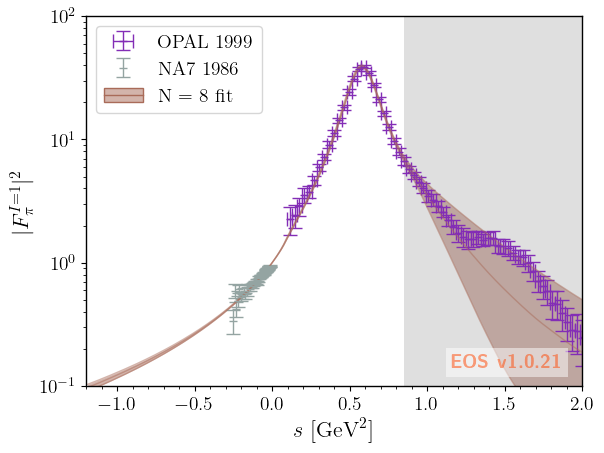

OPAL, order 8: zoom


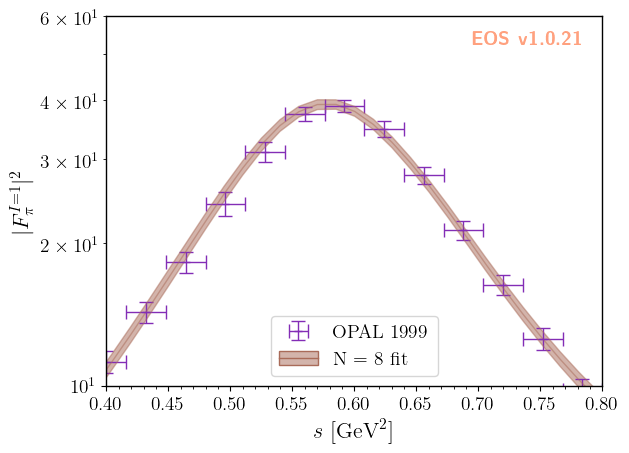

In [57]:
for experiment in EXPERIMENTS:
    plot_form_factor_squared(
        order=order,
        experiment=experiment,
        recompute=resample,
    )

Belle, order 8: residuals at the BFP


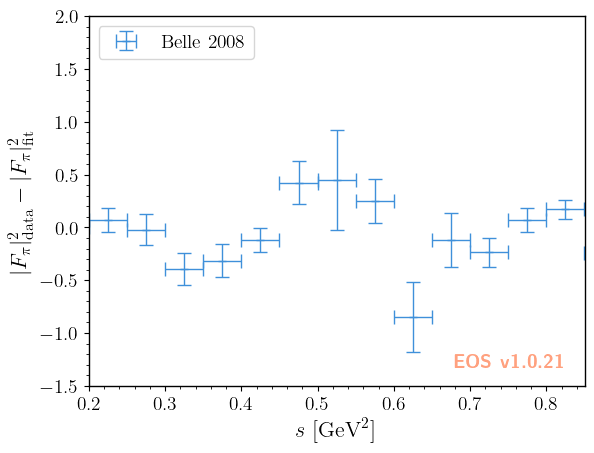

CLEO, order 8: residuals at the BFP


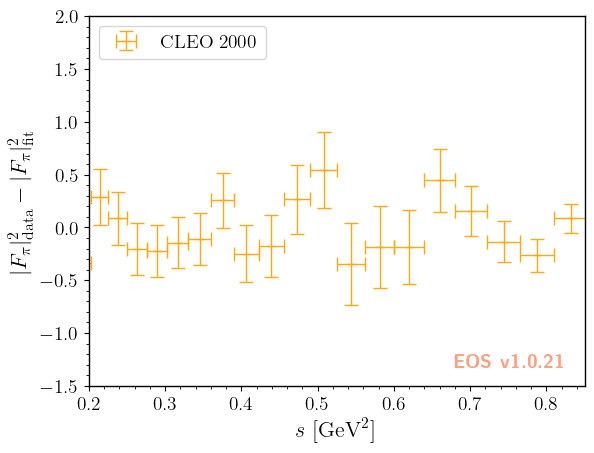

ALEPH, order 8: residuals at the BFP


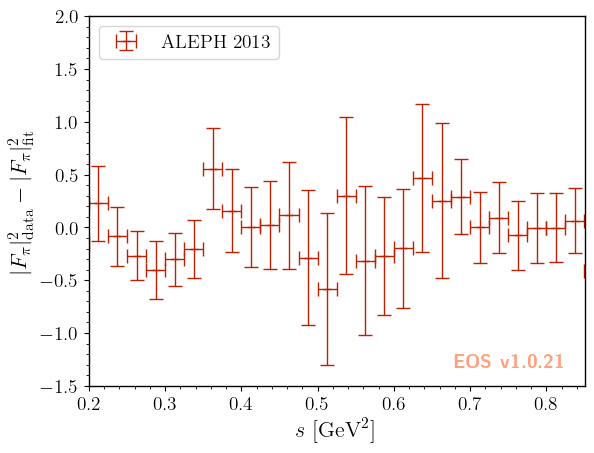

OPAL, order 8: residuals at the BFP


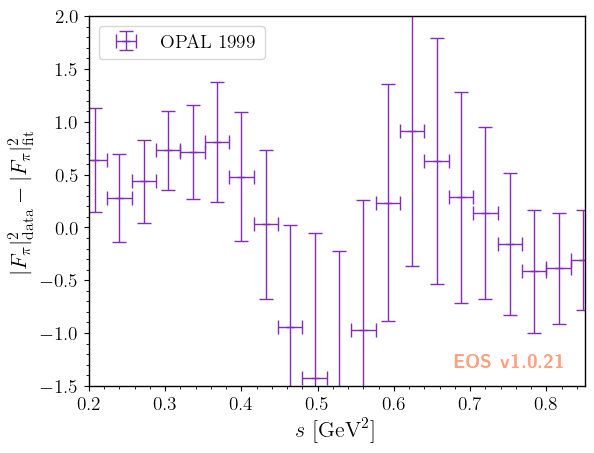

In [58]:
for experiment in EXPERIMENTS:
    plot_form_factor_residuals(
        order=order,
        experiment=experiment,
    )

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


Belle, order 8: phase in the psi plane


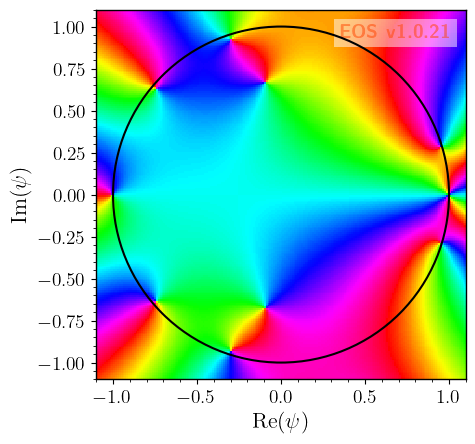

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


CLEO, order 8: phase in the psi plane


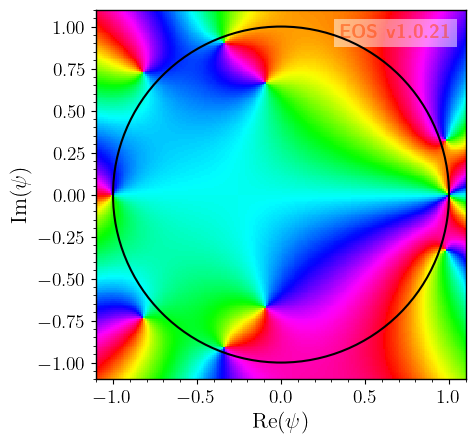

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


ALEPH, order 8: phase in the psi plane


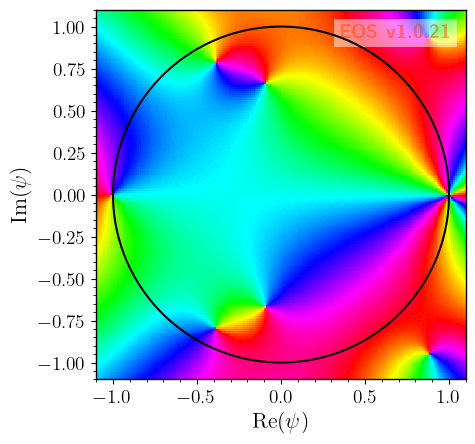

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


OPAL, order 8: phase in the psi plane


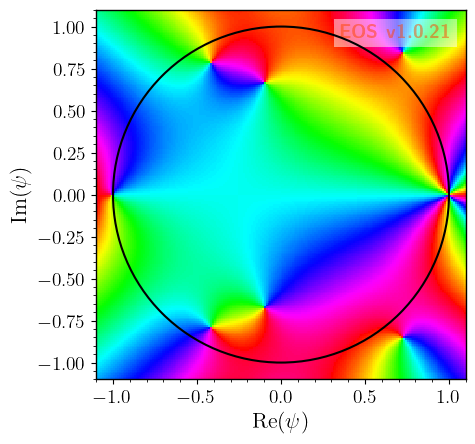

In [59]:
for experiment in EXPERIMENTS:
    plot_psi_phase(
        order=order,
        experiment=experiment,
        resolution=200,
    )

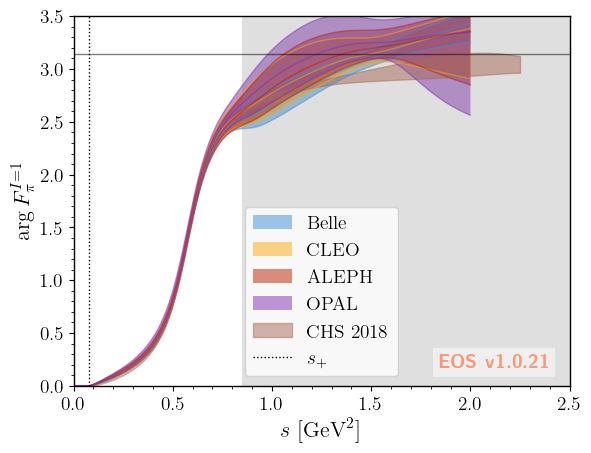

In [60]:
phase_figure_order8 = plot_timelike_phase(
    order=order,
    recompute=resample,
)

Belle, order 8: full


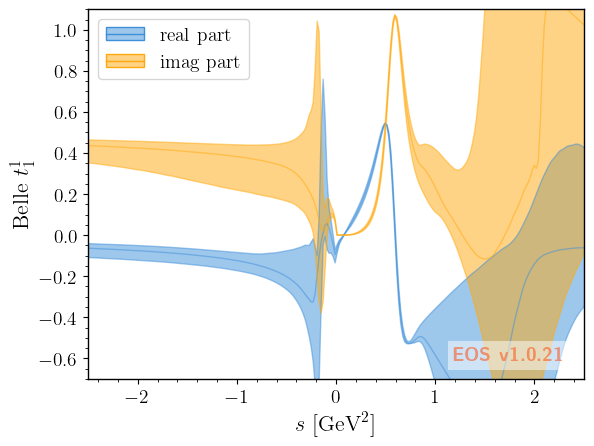

Belle, order 8: near zero


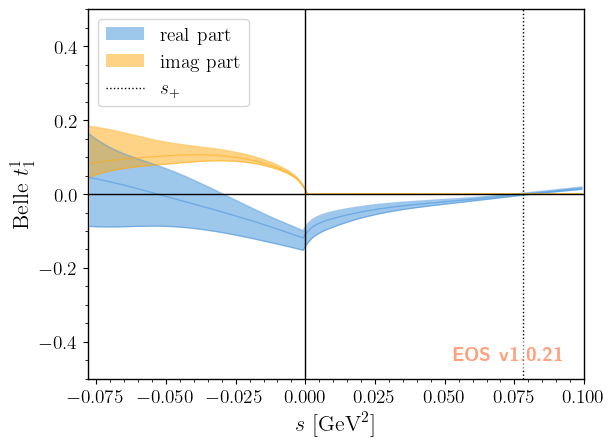

Belle, order 8: threshold


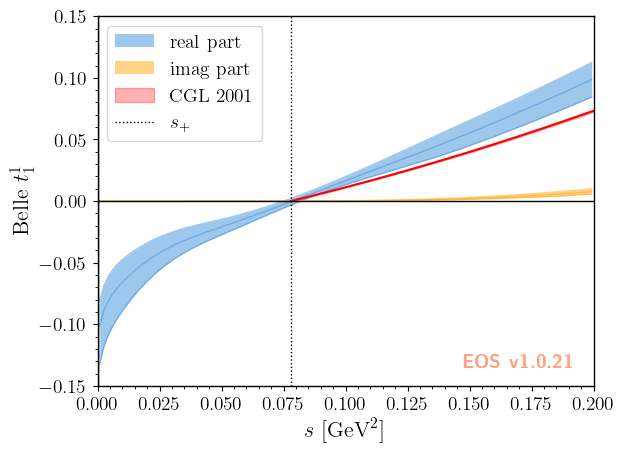

CLEO, order 8: full


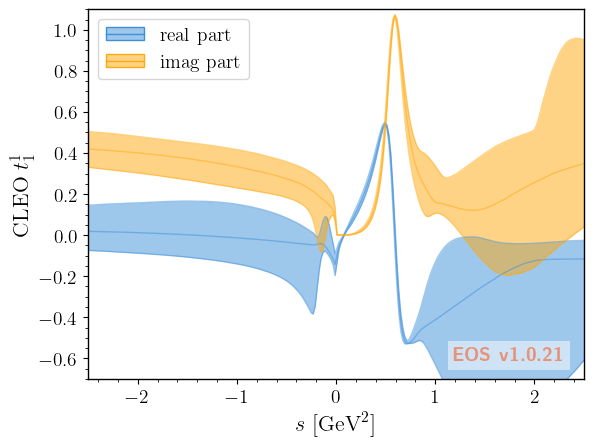

CLEO, order 8: near zero


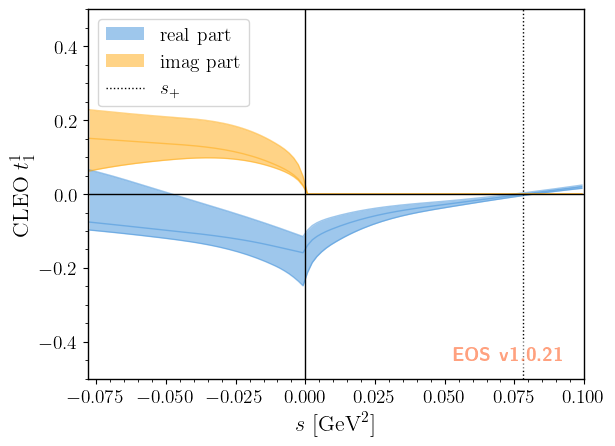

CLEO, order 8: threshold


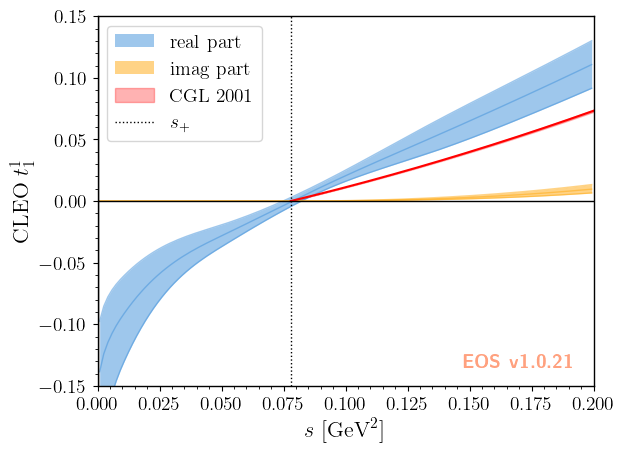

ALEPH, order 8: full


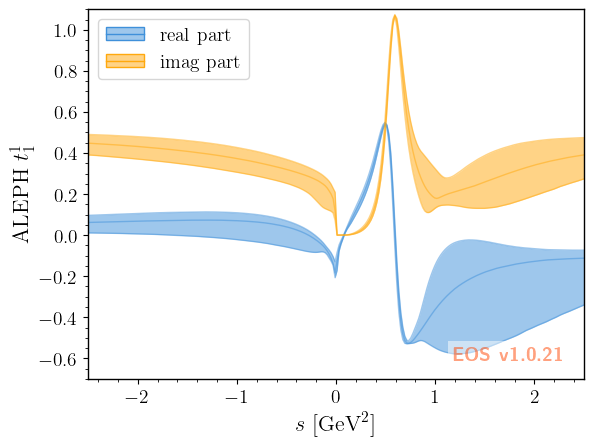

ALEPH, order 8: near zero


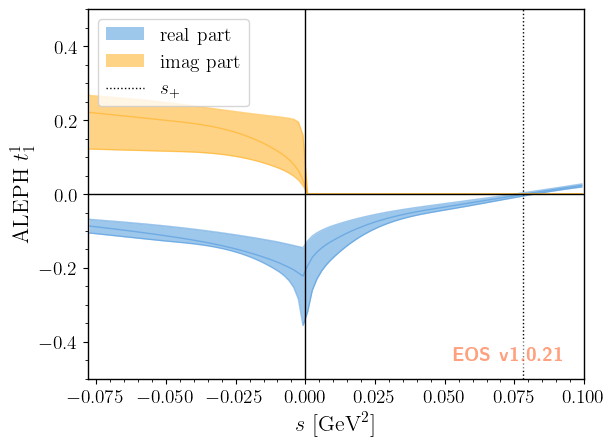

ALEPH, order 8: threshold


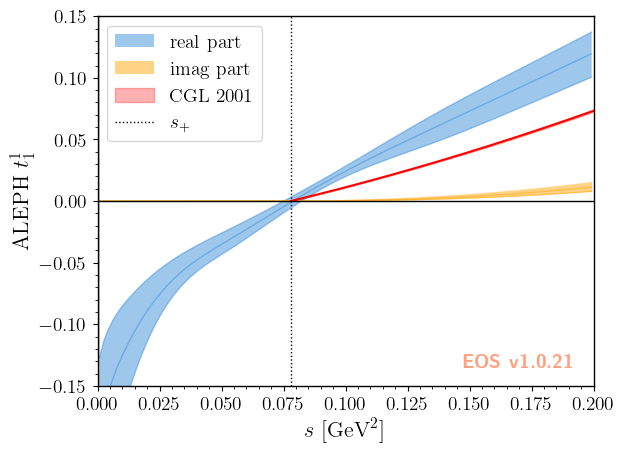

OPAL, order 8: full


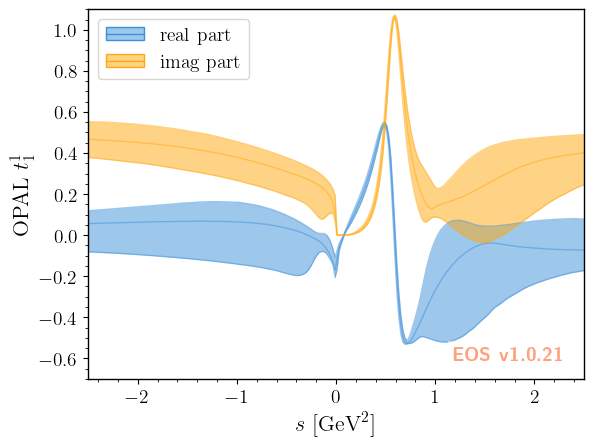

OPAL, order 8: near zero


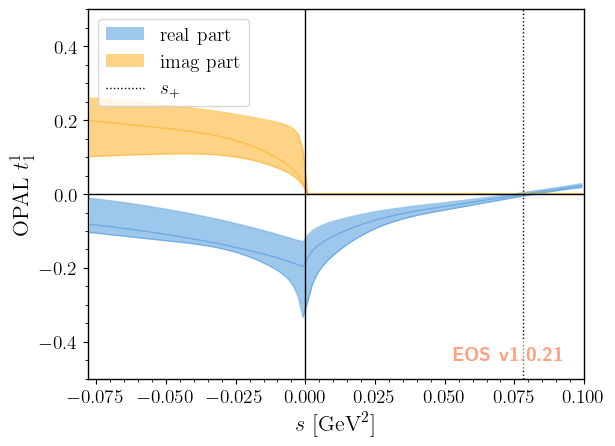

OPAL, order 8: threshold


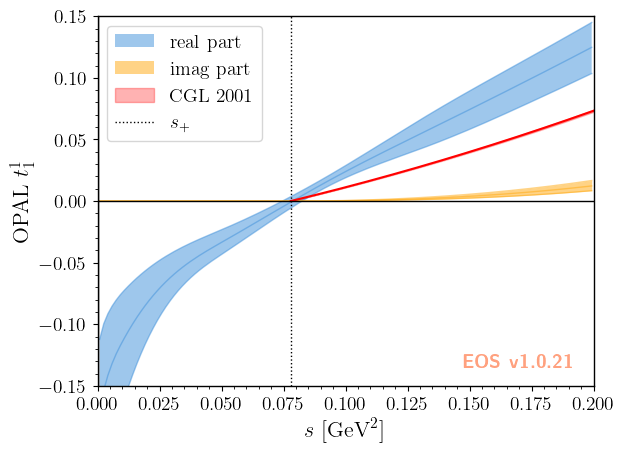

In [61]:
for experiment in EXPERIMENTS:
    plot_partial_waves(
        order=order,
        experiment=experiment,
        theory_band=partial_wave_theory,
        recompute=resample,
    )

Belle a11 = 0.0576 ± 0.0146
Belle b11 = -0.0003 ± 0.0059
CLEO a11 = 0.0737 ± 0.0201
CLEO b11 = -0.0084 ± 0.0082
ALEPH a11 = 0.0881 ± 0.0197
ALEPH b11 = -0.0169 ± 0.0088
OPAL a11 = 0.0856 ± 0.0228
OPAL b11 = -0.0120 ± 0.0104


Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'
Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


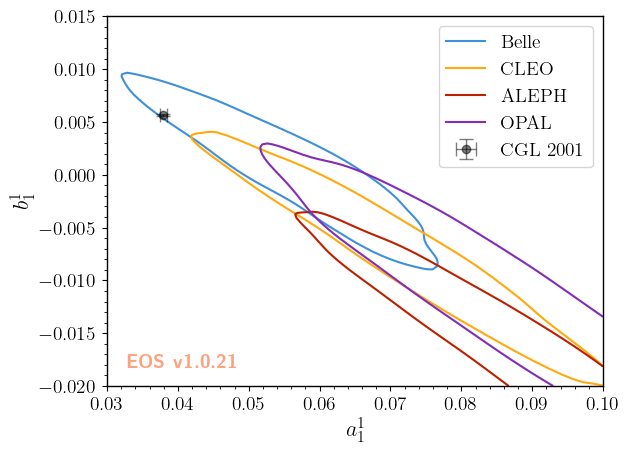

In [62]:
show_scattering_lengths(
    order=order,
    recompute=resample,
)

sl_figure_order8 = plot_scattering_lengths(
    order=order,
    xrange=(0.03, 0.1),
    yrange=(-0.02, 0.015),
)

In [63]:
show_charge_radius(
    order=order,
    recompute=resample,
)

Belle <r^2> = 0.4383 ± 0.0052 fm^2
CLEO <r^2> = 0.4407 ± 0.0061 fm^2
ALEPH <r^2> = 0.4415 ± 0.0062 fm^2
OPAL <r^2> = 0.4460 ± 0.0065 fm^2


In [64]:
export_rho_residues_psi(
    order=order,
    recompute=resample,
)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-Be…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-Be…

Belle: exported 13629 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_Belle8.wl


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-CL…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-CL…

...

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-AL…

ALEPH: exported 15202 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_ALEPH8.wl


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-OP…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order8-OP…

OPAL: exported 15135 samples to /homeijclab/nouri/eos/analysis/tau-data-seperate/residues_psi_OPAL8.wl


In [65]:
show_rho_couplings(order=order)

Belle: g_rho_gamma = (4.8920 ± 0.0104) + i * (-0.2787 ± 0.0183)
Belle: g_rho_pi_pi = (5.8760 ± 0.0790) + i * (-0.2604 ± 0.1942)
CLEO: g_rho_gamma = (4.9234 ± 0.0265) + i * (-0.2478 ± 0.0186)
CLEO: g_rho_pi_pi = (5.9195 ± 0.1218) + i * (-0.2033 ± 0.2792)
ALEPH: g_rho_gamma = (4.9884 ± 0.0360) + i * (-0.2096 ± 0.0283)
ALEPH: g_rho_pi_pi = (5.8324 ± 0.1402) + i * (-0.3252 ± 0.2649)
OPAL: g_rho_gamma = (4.9437 ± 0.0675) + i * (-0.2398 ± 0.0411)
OPAL: g_rho_pi_pi = (6.1042 ± 0.2333) + i * (-0.0480 ± 0.3483)


## Belle order 9


In [66]:
Belle_posterior = 'FF-fp-I1-order9-Belle'
Belle_analysis  = af.analysis(Belle_posterior)

Creating analysis with 1 priors, 2 EOS-wide constraints, 2 global options, 2 manually-entered constraints and 2 fixed parameters.
likelihood probably depends on 18 parameter(s) that do not appear in the prior; check prior?


In [67]:
Belle_start_point = [0.76441214,  0.14310241,  0.08128962, -0.23865707,  0.49612213,
       -0.15956245,  0.29386345, -0.02290487]
get_gof(Belle_analysis, Belle_start_point)

In [13]:
#Belle_bfp, Belle_gof = eos.tasks.find_mode(af, Belle_posterior, start_point=Belle_start_point, base_directory=BASE_DIRECTORY, optimizations=100)
Belle_bfp, Belle_gof  = eos.tasks.find_mode(af, Belle_posterior, importance_samples=True, base_directory=BASE_DIRECTORY, optimizations=100)
display(Belle_gof)
Belle_bfp.point

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

array([ 0.76441214,  0.14310241,  0.08128967, -0.23865712,  0.4961224 ,
       -0.1595627 ,  0.29386363, -0.022905  ])

In [68]:
if resample:
    eos.tasks.sample_nested(af, Belle_posterior, base_directory=BASE_DIRECTORY, bound='multi', nlive=200)

Belle_f = eos.data.ImportanceSamples(os.path.join(BASE_DIRECTORY, 'data', Belle_posterior, 'samples'))
print(f"Collected {Belle_f.samples.shape[0]} samples") #113.81

Collected 14494 samples


In [69]:
for i, p in enumerate(Belle_analysis.varied_parameters):
    mean = np.average(Belle_f.samples[:,i], weights=Belle_f.weights)
    std  = wstd(Belle_f.samples[:,i], weights=Belle_f.weights)
    print(f"      - {{ 'parameter': '{p.name()}', 'min':  {mean - 5*std:.5f}, 'max':  {mean + 5*std:.5f}, 'type': 'uniform'}}")

      - { 'parameter': '0->pipi::M_(+,1,0)@BHKMNR2026', 'min':  0.75666, 'max':  0.77187, 'type': 'uniform'}
      - { 'parameter': '0->pipi::Gamma_(+,1,0)@BHKMNR2026', 'min':  0.13904, 'max':  0.14690, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^4@BHKMNR2026', 'min':  -0.24797, 'max':  0.48701, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^5@BHKMNR2026', 'min':  -0.86434, 'max':  0.49264, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^6@BHKMNR2026', 'min':  -0.89884, 'max':  1.55233, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^7@BHKMNR2026', 'min':  -1.22205, 'max':  0.82987, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^8@BHKMNR2026', 'min':  -0.65487, 'max':  1.00161, 'type': 'uniform'}
      - { 'parameter': '0->pipi::a_(+,1)^9@BHKMNR2026', 'min':  -0.55234, 'max':  0.43294, 'type': 'uniform'}


Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

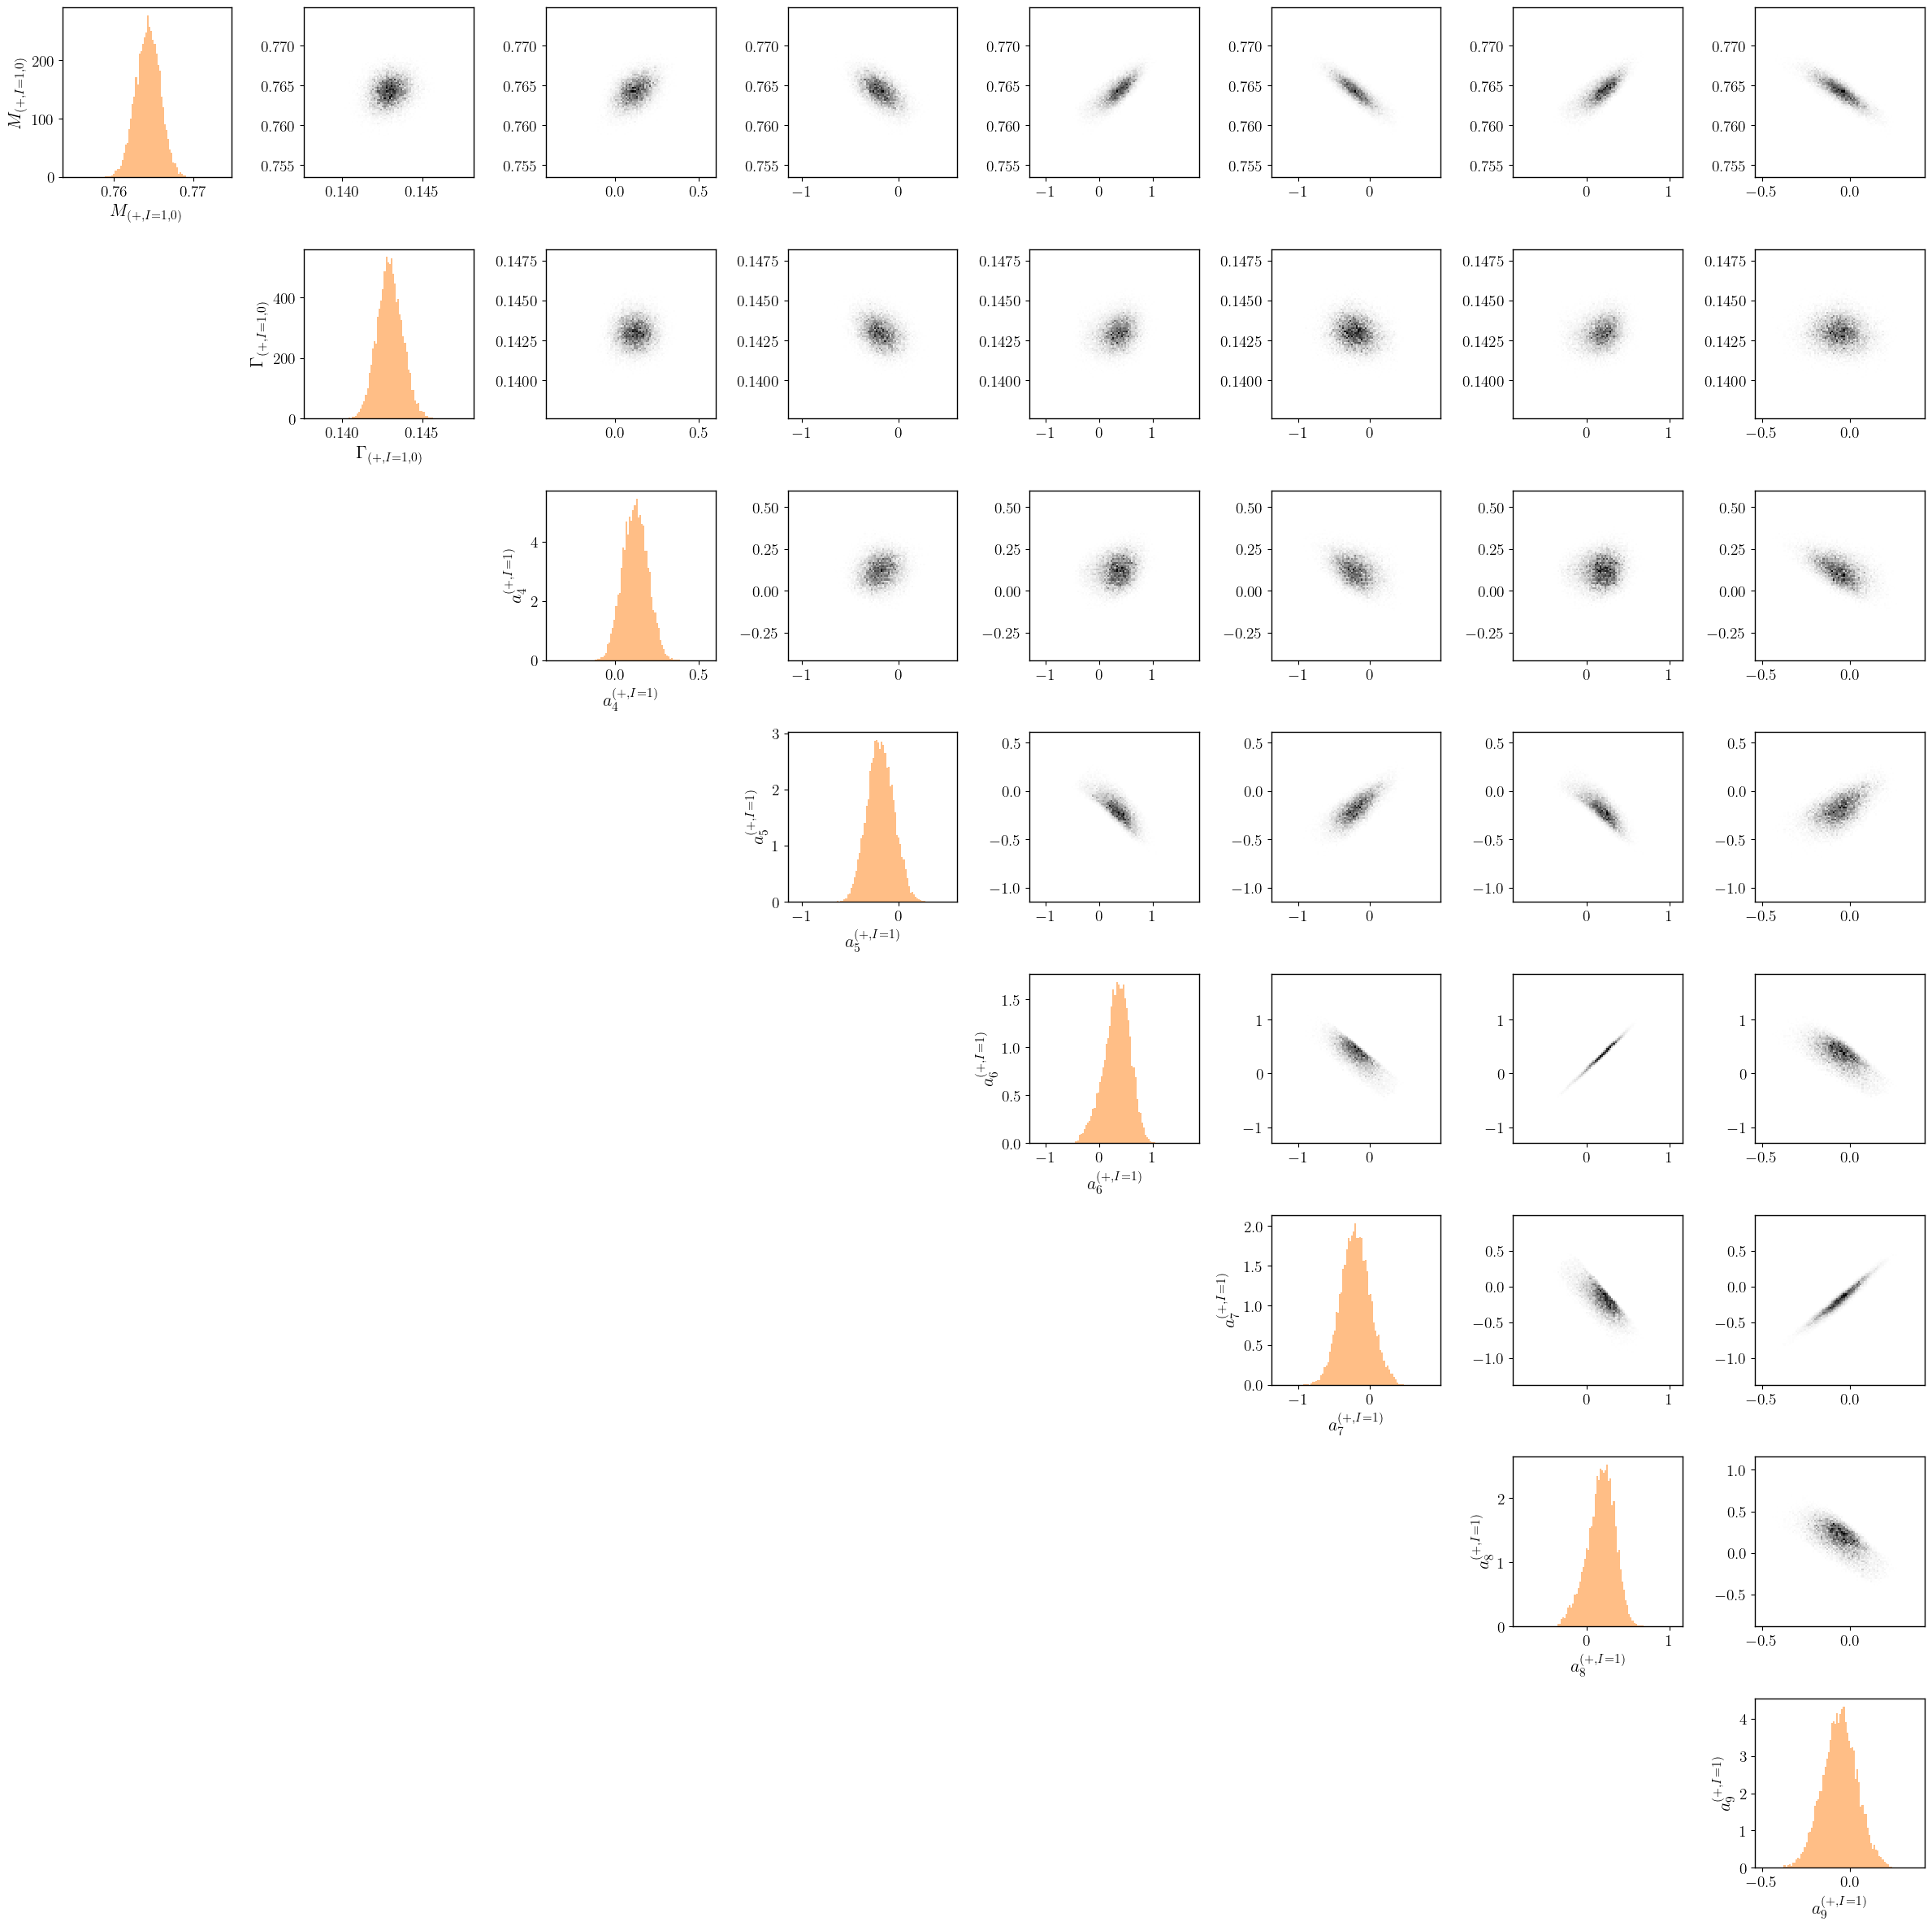

In [70]:
eos.tasks.corner_plot(af, Belle_posterior, base_directory=BASE_DIRECTORY)

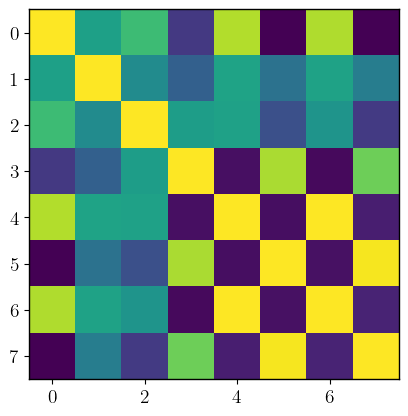

In [71]:
means = np.average(Belle_f.samples, weights=Belle_f.weights, axis=0)
cov = np.cov(Belle_f.samples, rowvar=False, aweights=Belle_f.weights)
corr = np.array([[cov[i,j] / np.sqrt(cov[i,i] * cov[j,j]) for j in range(len(cov))] for i in range(len(cov))])
plt.imshow(corr)
plt.show()

In [72]:
chol = np.linalg.cholesky(np.linalg.inv(cov))
display(np.linalg.inv(chol.transpose()))
decorrelated_samples = np.dot(Belle_f.samples, chol)
decorrelated_min = np.average(decorrelated_samples, weights=Belle_f.weights, axis=0) - 5 * wstd(decorrelated_samples, weights=Belle_f.weights, axis=0)
decorrelated_max = np.average(decorrelated_samples, weights=Belle_f.weights, axis=0) + 5 * wstd(decorrelated_samples, weights=Belle_f.weights, axis=0)
display(decorrelated_min, decorrelated_max)

array([[ 1.44267058e-04, -4.32274191e-05, -1.43683084e-04,
         5.73533965e-04, -1.14375348e-04,  1.74757543e-04,
         3.71304209e-04, -1.32706646e-03],
       [ 0.00000000e+00,  2.91525109e-04, -5.89323150e-04,
         1.55446938e-04,  2.49916312e-04, -2.61978715e-04,
         1.62103634e-04, -6.04996598e-05],
       [ 0.00000000e+00,  0.00000000e+00,  1.89025435e-03,
         5.28690211e-03,  4.61175813e-02,  2.78242588e-02,
        -2.83362964e-02, -4.08273330e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.28958415e-02,  1.20387565e-02,  7.44714771e-02,
        -7.89179494e-02,  7.95630699e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  2.35554791e-02,  9.09248019e-03,
         1.70424514e-01, -1.74371917e-01],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  3.44028358e-02,
        -3.43735058e-02,  1.99355090e-01],
       [ 0.00000000e+00,  0.000000

array([ 5.43482478e+03,  4.75419509e+02, -7.81871794e+00, -6.11731523e+00,
       -1.36997939e+00, -6.32338073e+00, -4.13354244e+00, -5.60564586e+00])

array([5.44482434e+03, 4.85419069e+02, 2.18084271e+00, 3.88224543e+00,
       8.62958128e+00, 3.67617999e+00, 5.86601726e+00, 4.39390988e+00])

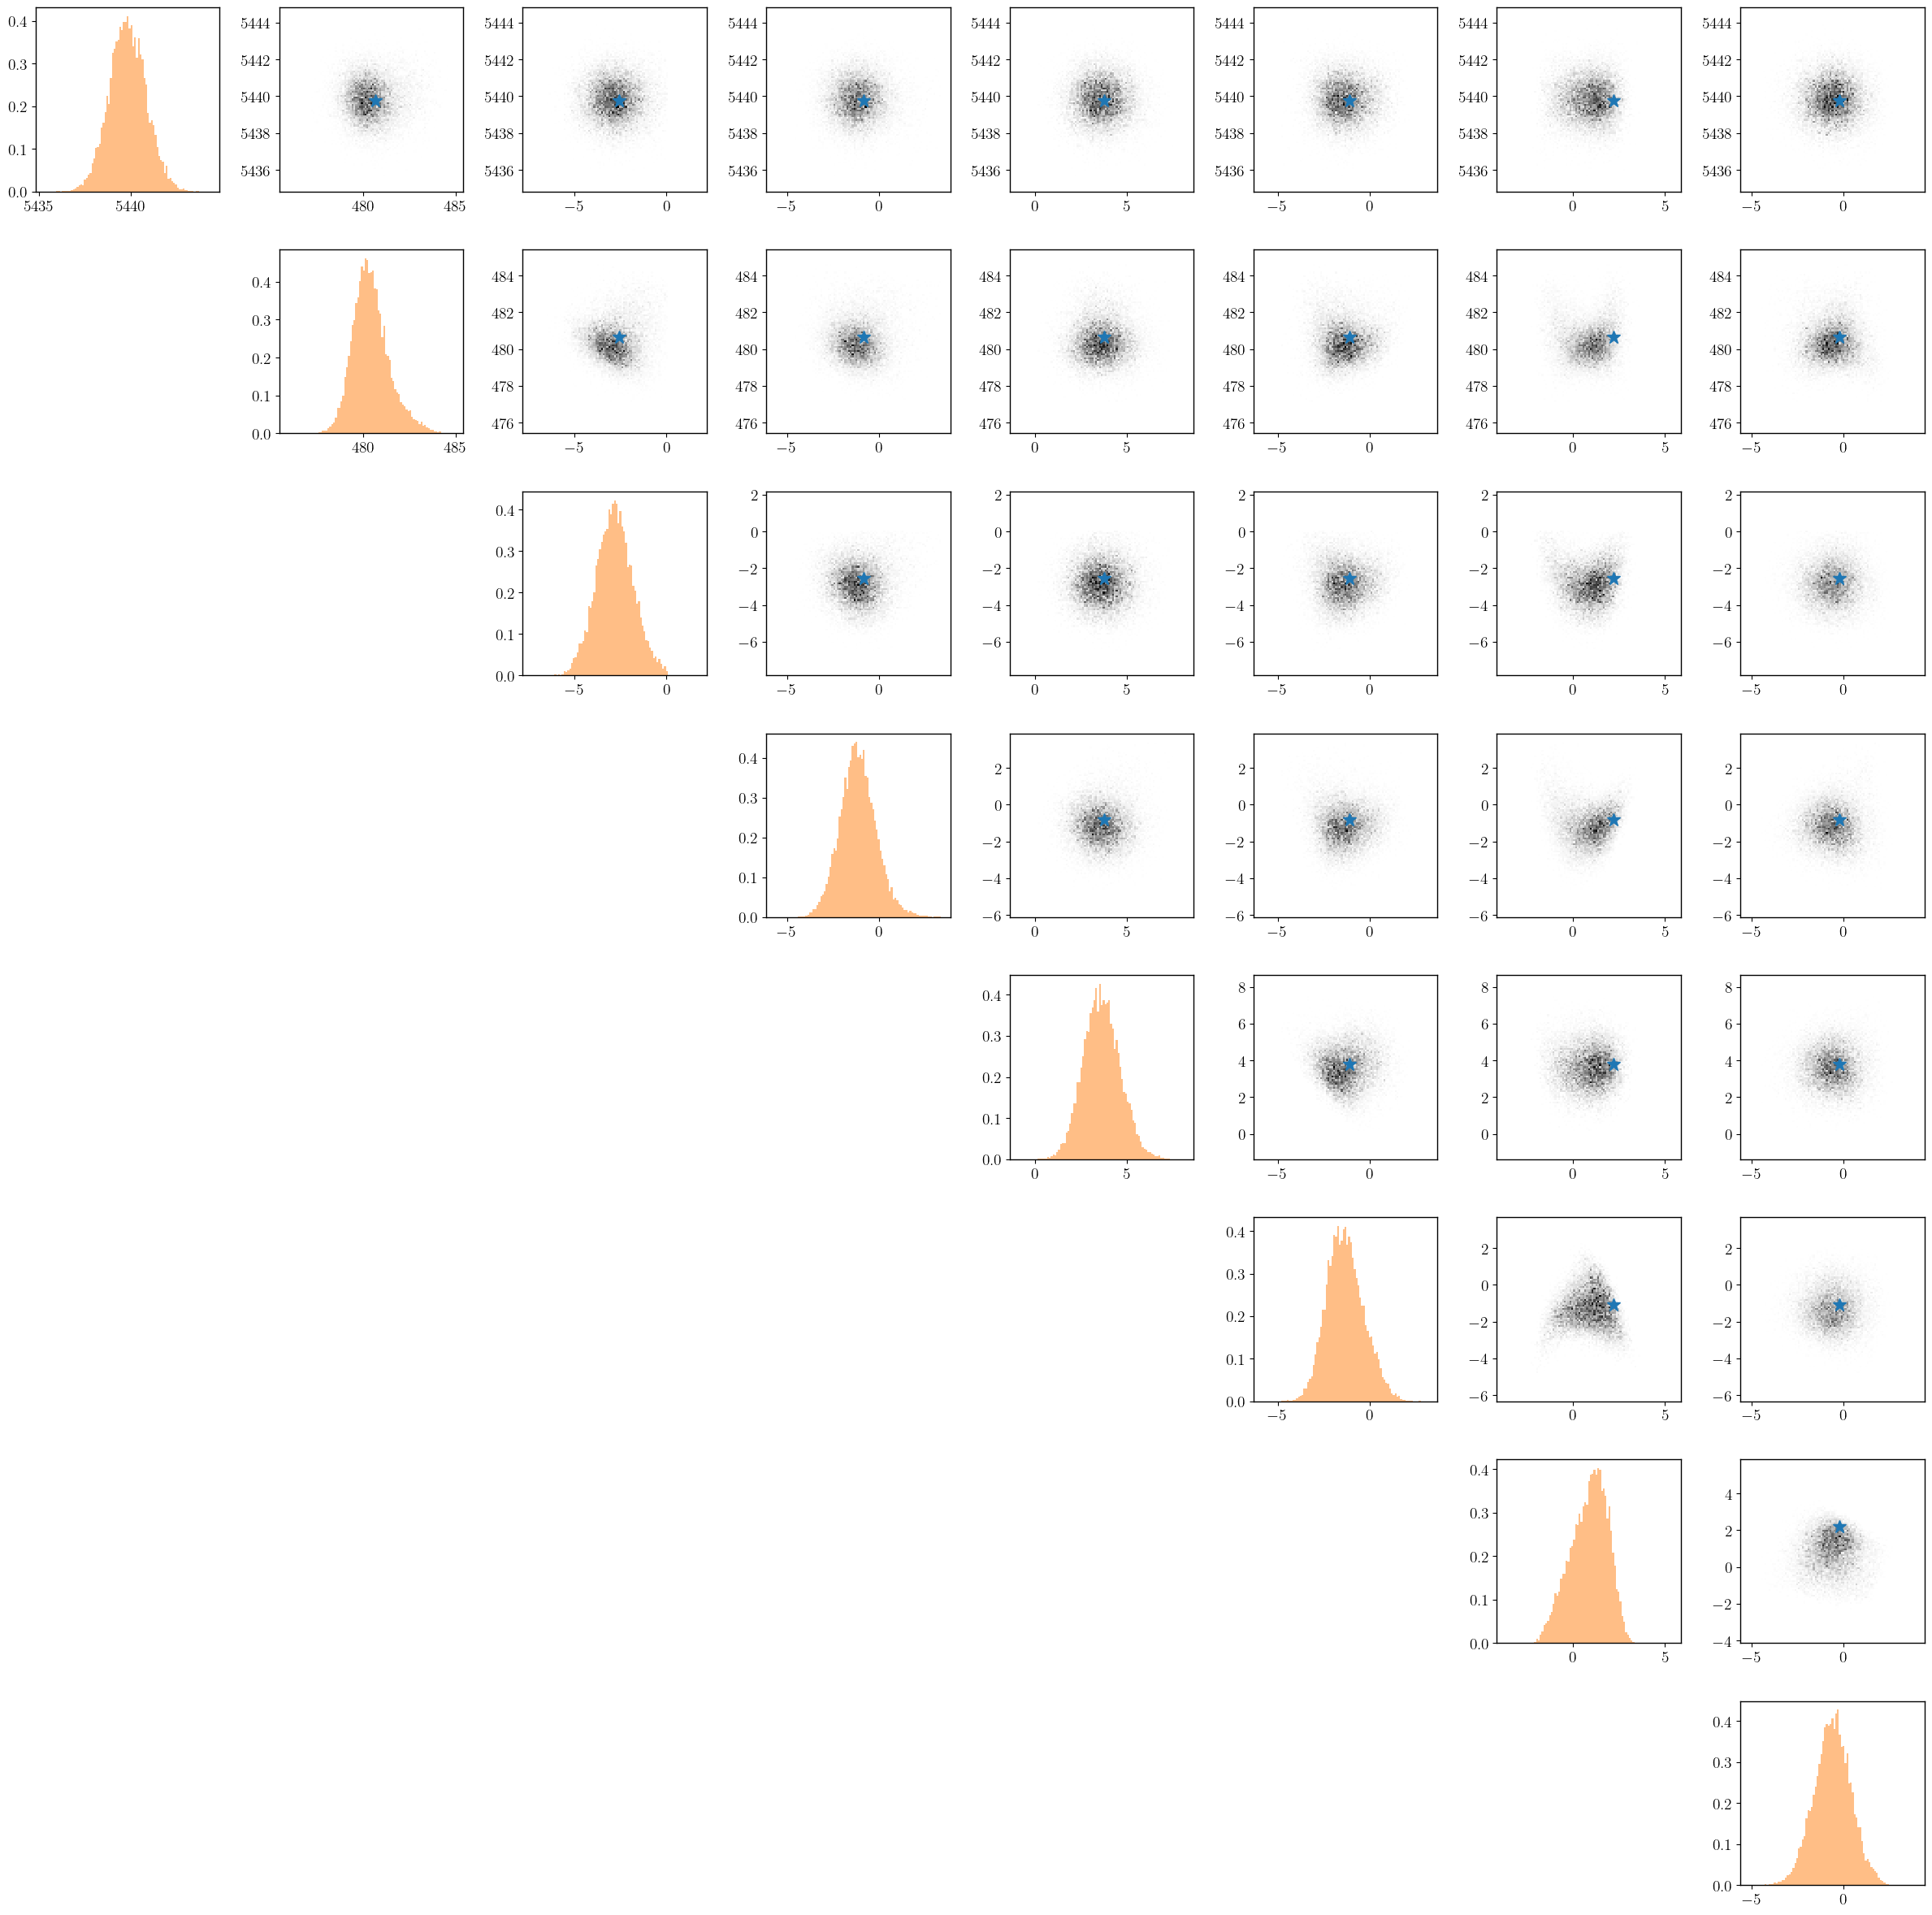

In [73]:
size = decorrelated_samples.shape[-1]
decorrelated_start_point = np.dot(Belle_start_point, chol)

fig, axes = plt.subplots(size, size, figsize=(3.0 * size, 3.0 * size), dpi=100)

for i in range(size):
    # diagonal
    ax = axes[i, i]
    variable_samples = decorrelated_samples[:, i] # For a single variable

    xmin = decorrelated_min[i]
    xmax = decorrelated_max[i]
    ax.hist(variable_samples, weights=Belle_f.weights, alpha=0.5, bins=np.linspace(xmin, xmax, 100), density=True, stacked=True, color='C1')
    ax.set_xlim((xmin, xmax))
    ax.set_aspect(np.diff((xmin, xmax))[0] / np.diff(ax.get_ylim())[0])

    for j in range(0, size):
        # off-diagonal
        if j < i:
            axes[i, j].set_axis_off()

        if j <= i:
            continue

        ax = axes[i, j]

        ax.plot(decorrelated_start_point[j], decorrelated_start_point[i], marker = "*", markersize=12)

        # Samples for two single variables as x and y data
        xsamples = decorrelated_samples[:, j]
        ysamples = decorrelated_samples[:, i]

        xmin = decorrelated_min[j]
        xmax = decorrelated_max[j]
        ymin = decorrelated_min[i]
        ymax = decorrelated_max[i]
        ax.hist2d(xsamples, ysamples, weights=Belle_f.weights, alpha=1.0, bins=[np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100)], cmap='Greys', rasterized=True)
        ax.set_xlim((xmin, xmax))
        ax.set_ylim((ymin, ymax))
        ax.set_aspect(np.diff((xmin, xmax))[0] / np.diff((ymin, ymax))[0])

fig.tight_layout()
fig.show()

In [74]:
print(f"rho mass  = {np.average(Belle_f.samples[:,0], weights=Belle_f.weights):.4f} ± {wstd(Belle_f.samples[:,0], weights=Belle_f.weights):.4f}")
print(f"rho width = {np.average(Belle_f.samples[:,1], weights=Belle_f.weights):.4f} ± {wstd(Belle_f.samples[:,1], weights=Belle_f.weights):.4f}")

rho mass  = 0.7643 ± 0.0015
rho width = 0.1430 ± 0.0008


Computing KDE for samples of variables '0->pipi::M_(+,1,0)@BHKMNR2026' and '0->pipi::Gamma_(+,1,0)@BHKMNR2026'


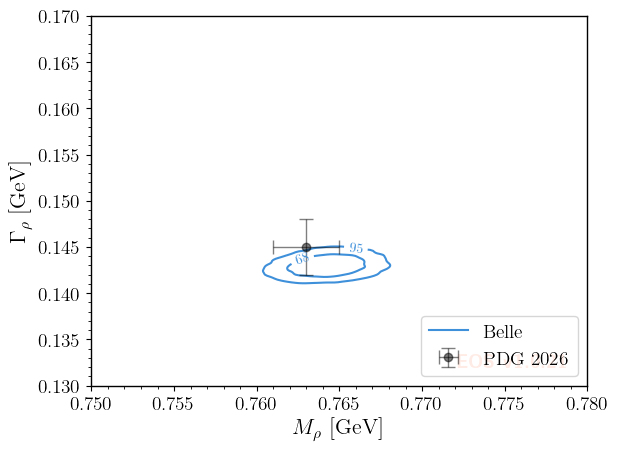

In [75]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': r'$M_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [0.75, 0.78] },
    'yaxis': { 'label': r'$\Gamma_\rho$', 'unit': '$\\mathrm{GeV}$', 'range': [ 0.13, 0.17] },
    'legend': { 'position': 'lower right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Belle', 'color': colors[0],
      'levels': [68, 95], 'contours': ['lines', 'labels'],
      'datafile': 'data/'+Belle_posterior+'/samples',
      'variables': ['0->pipi::M_(+,1,0)@BHKMNR2026', '0->pipi::Gamma_(+,1,0)@BHKMNR2026']
    },
    {'type': 'errorbars', 'positions': [[0.763, 0.145]], 'xerrors': [0.002], 'yerrors': [0.003], 'label': 'PDG 2026', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [21]:
# Dispersive bound computation
eos.tasks.predict_observables(af, Belle_posterior, "FF-fp-I1-dispersive-bound", base_directory=BASE_DIRECTORY)
preds = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', Belle_posterior, 'pred-FF-fp-I1-dispersive-bound'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

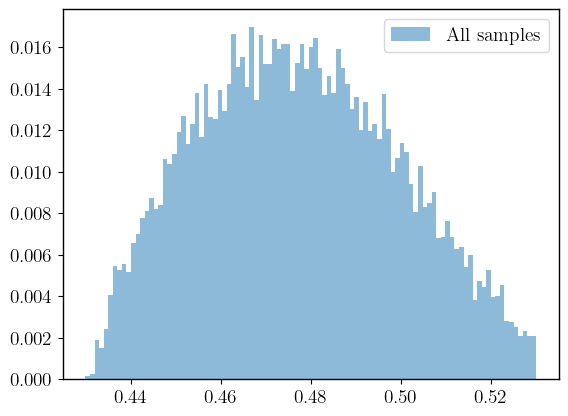

In [23]:
plt.hist(preds.samples, weights=preds.weights, bins=np.linspace(0.43,0.53,100), alpha=0.5, label='All samples')
plt.legend()
plt.show()

In [24]:
disp_values = np.array(preds.samples[:,0])
disp_mean   = np.average(disp_values, weights=preds.weights)
disp_std    = wstd(disp_values, weights=preds.weights)
print(f"Dispersive bound is {disp_mean:.4f} ± {disp_std:.4f}")

Dispersive bound is 0.4786 ± 0.0235


In [25]:
eos.tasks.predict_observables(af, Belle_posterior, "FF-fp2-I1-all", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

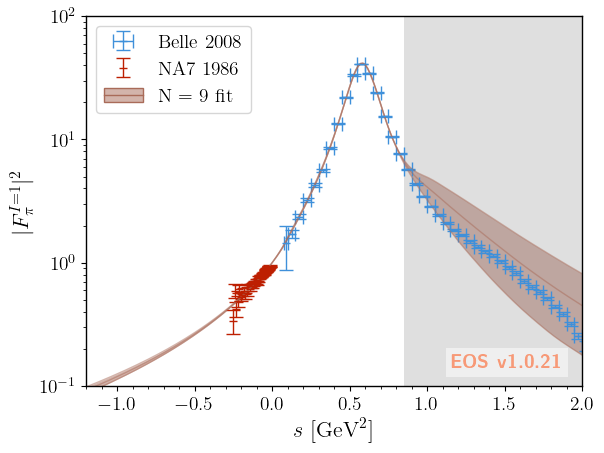

In [28]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-1.2, 2.0] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 0.1, 100.0], 'scale': 'log' },
    'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'constraint', 'label': 'NA7 1986', 'color': colors[2],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2)',
        'constraints': '0->pipi::Abs{f_+}^2@NA7:1986A',
    },
    { 'type': 'uncertainty', 'label': 'N = 9 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+Belle_posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    },
    { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.0], 'y': [0.0, 100]}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

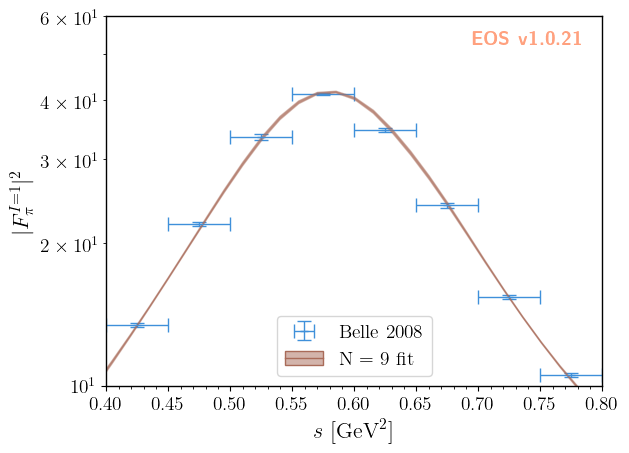

In [29]:
figure_args = {
'watermark': { 'position': 'upper right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.4, 0.8] },
    'yaxis': { 'label': r'$|F^{I=1}_\pi|^2$', 'range': [ 10.0, 60.0], 'scale': 'log' },
    'legend': { 'position': 'lower center' },
    'items': [
    { 'type': 'constraint', 'label': 'Belle 2008', 'color': colors[0],
        'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)',
        'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
    },
    { 'type': 'uncertainty', 'label': 'N = 9 fit', 'color': colors[5],
        'variable': 'q2', 'range': [-1.2, 2.0], 'interpolation': 'cubic',
        'datafile': 'data/'+Belle_posterior+'/pred-FF-fp2-I1-all', 'resolution': 300
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [30]:
get_gof(Belle_analysis, Belle_start_point)
param_dict = {p.name(): p.evaluate() for p in Belle_analysis.parameters}

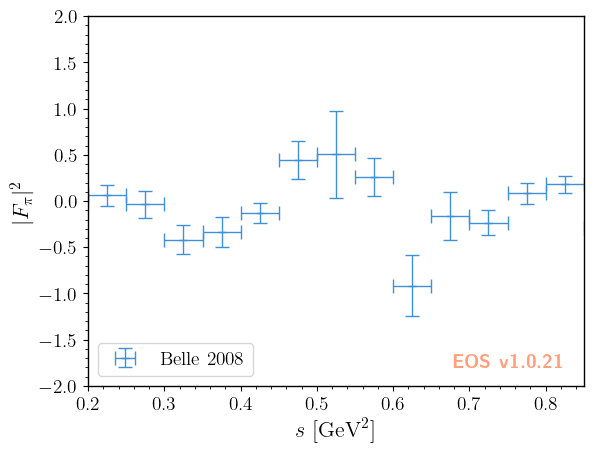

In [31]:
figure_args = {
'watermark': { 'position': 'lower right' },
'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.2, sIn] },
    'yaxis': { 'label': r'$|F_\pi|^2$', 'range': [ -2, 2], 'scale': 'linear' },
    'legend': { 'position': 'lower left' },
    'items': [
        { 'type': 'constraint-residue', 'label': 'Belle 2008', 'parameters': param_dict, 'options': {"form-factors": "BHKMNR2026"},
                  'color': colors[0],  'variable': 'q2', 'observable': '0->pipi::Abs{f_+}^2(q2_min,q2_max)', 'style': 'delta', 'constraints': '0->pipi::Abs{f_+}^2@Belle:2008C',
        }]}
        }
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [32]:
eos.tasks.predict_observables(af, Belle_posterior, "FF-arg-fp-I1-timelike", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

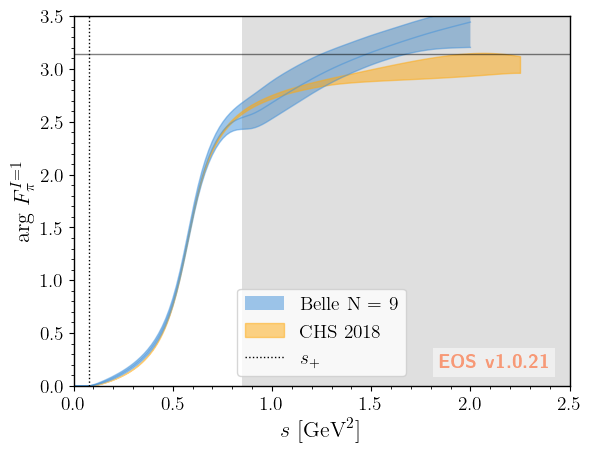

In [76]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [0.0, 2.5] },
    'yaxis': { 'label': r'arg $F^{I=1}_\pi$', 'range': [0.0 , 3.5] },
    'legend': { 'position': 'lower right' },
    'items': [
      { 'type': 'uncertainty', 'label': 'Belle N = 9', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+Belle_posterior+'/pred-FF-arg-fp-I1-timelike', 'color': colors[0]
      },
      { 'type': 'band', 'color': 'gray', 'alpha': 0.25, 'x': [sIn, 2.5], 'y': [0.0, 3.5]},
      { 'type': 'expression', 'expression': 'np.pi', 'range': [0, 2.5], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)

q2_over_mpisquared, phase, err = np.loadtxt("scripts/d11-central.txt", skiprows=1, unpack=True)
q2 = q2_over_mpisquared * mpi**2
figure.draw()

ax = figure._ax
ax.fill_between(q2, phase - err, phase + err, label="CHS 2018", alpha=0.5, color=colors[1])

ax.axvline(x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')

ax.legend(loc="lower center")

In [34]:
get_gof(Belle_analysis, Belle_start_point)
Belle_analysis.parameters.dump('data/'+Belle_posterior+'/mode-default/parameters.yaml')

Handling item to plot 0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026 in the complex plane


Overriding parameters from file
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::Gamma_(0,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,0)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,1)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(+,2)@KSvD2025' with central value '0'
[parameters.override] Overriding existing parameter '0->Kpi::M_(0,0)@KSvD2025' with central value '0'
[parameters.override] Overridi

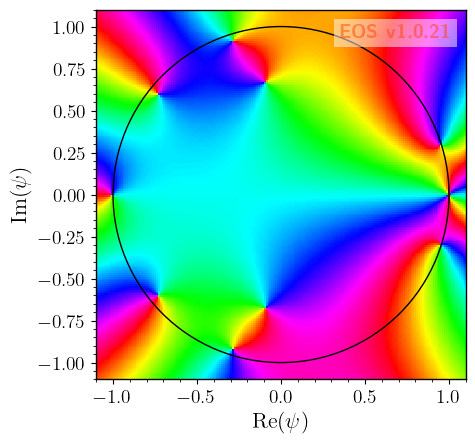

In [35]:
figure_args = {
'plot': {
    'xaxis': { 'label': r'$\mathrm{Re}(\psi)$', 'range': [-1.1, 1.1] },
    'yaxis': { 'label': r'$\mathrm{Im}(\psi)$', 'range': [-1.1, 1.1] },
    # 'legend': { 'position': 'upper left' },
    'items': [
    { 'type': 'complex-plane', 'label': 'N = 9 fit', 'colormap': 'hsv', 'ranges': ((-1.1, +1.1), (-1.1, +1.1)),
        'variables': ["Re{psi}", "Im{psi}"], 'observable': "0->pipi::Arg{f_+}(Re{psi},Im{psi})@BHKMNR2026",
        'fixed_parameters_from_file': 'data/'+Belle_posterior+'/mode-default/parameters.yaml', 'resolution': 200
    }
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
circle = plt.Circle((0, 0), 1.0, color='k', fill=False)
figure._ax.add_patch(circle)
figure._ax.set_aspect("equal", adjustable="box")


In [36]:
eos.tasks.predict_observables(af, Belle_posterior, "real-partial-wave-I1", base_directory=BASE_DIRECTORY)
eos.tasks.predict_observables(af, Belle_posterior, "imag-partial-wave-I1", base_directory=BASE_DIRECTORY)

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

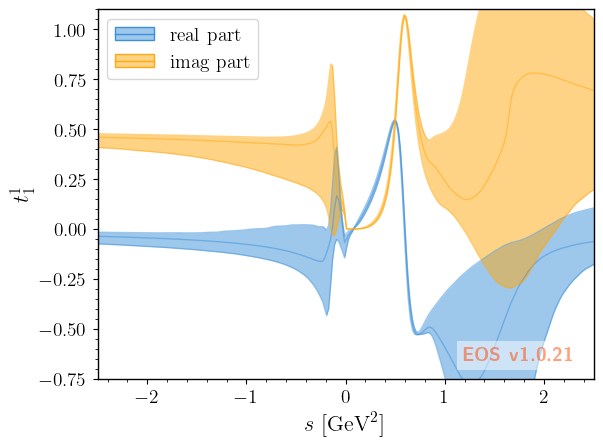

In [37]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-2.5, 2.5] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.75, 1.1]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+Belle_posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 250,
        'variable': 'q2', 'datafile': 'data/'+Belle_posterior+'/pred-imag-partial-wave-I1'
      },
    ]
  }
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

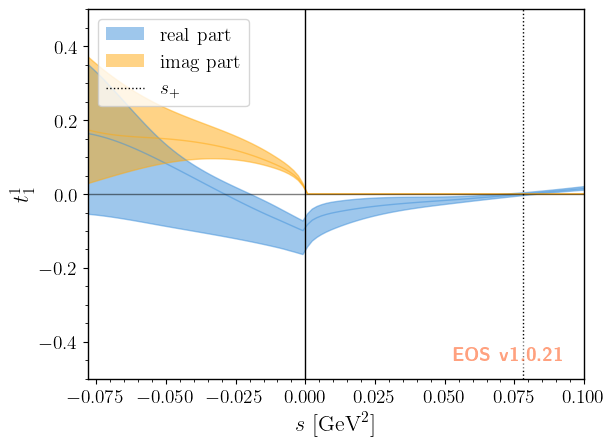

In [38]:
figure_args = {
  'watermark': { 'position': 'lower right' },
  'plot': {
    'xaxis': { 'label': '$s$', 'unit': '$\\mathrm{GeV}^2$', 'range': [-sPlus, 0.1] },
    'yaxis': { 'label': '$t_1^1$', 'range': [-0.5, 0.5]},
    'legend': { 'position': 'upper left' },
    'items': [
      { 'type': 'uncertainty', 'label': 'real part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+Belle_posterior+'/pred-real-partial-wave-I1'
      },
      { 'type': 'uncertainty', 'label': 'imag part', 'interpolation': 'cubic', 'resolution': 3000,
        'variable': 'q2', 'datafile': 'data/'+Belle_posterior+'/pred-imag-partial-wave-I1'
      },
      { 'type': 'expression', 'expression': '0', 'range': [-sPlus, 0.1], 'color': 'k'}
    ]
  }
}

figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()
ax = figure._ax
ax.axvline( x=0.0, color='k', linewidth=1.0)
ax.axvline( x=sPlus, color='k', linestyle=':', linewidth=1.0, label=r'$s_+$')
ax.legend(loc='upper left')

In [39]:
# Analytic value of a11 and b11
eos.tasks.predict_observables(af, Belle_posterior, "FF-fp-I1-scattering-length-params", base_directory=BASE_DIRECTORY)
Belle_sl_params = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', Belle_posterior, 'pred-FF-fp-I1-scattering-length-params'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

In [40]:
Belle_a11_values, Belle_b11_values = calculate_sl_values(Belle_sl_params)
(Belle_a11_mean, Belle_a11_std, Belle_b11_mean, Belle_b11_std) = summarize_sl_values("Belle", Belle_a11_values, Belle_b11_values, Belle_sl_params.weights)

Belle a11 = 0.0512 ± 0.0227
Belle b11 = 0.0059 ± 0.0146


In [41]:
Belle_sl_samples_path = save_sl_samples(Belle_posterior, Belle_a11_values, Belle_b11_values, Belle_sl_params.weights)

Computing KDE for samples of variables 'derived::a11' and 'derived::b11'


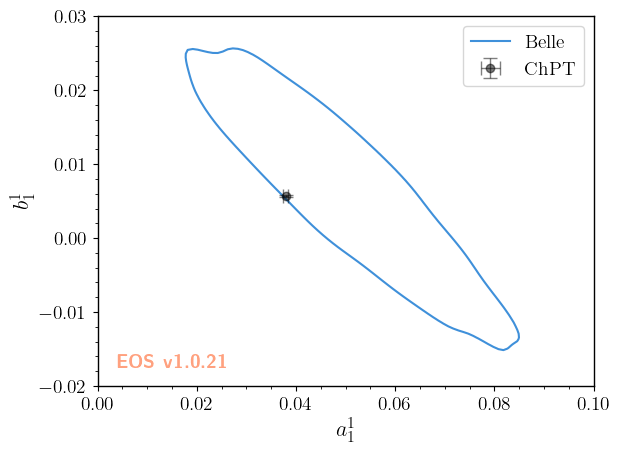

In [46]:
xrange = [0.0, 0.1]
yrange = [-0.02, 0.03]

figure_args = {
'watermark': { 'position': 'lower left' },
'plot': {
    'xaxis': { 'label': r'$a_1^1$', 'range': xrange },
    'yaxis': { 'label': r'$b_1^1$', 'range': yrange },
    'legend': { 'position': 'upper right' },
    'items': [
    { 'type': 'kde2D', 'label': 'Belle', 'color': colors[0],
      'levels': [68], 'contours': ['lines'], 'bandwidth': 1.0,
      'datafile': Belle_sl_samples_path, 'xrange': xrange, 'yrange': yrange,
      'variables': ['derived::a11', 'derived::b11']
    },
    {'type': 'errorbars', 'positions': [[0.0379, 0.00567]], 'xerrors': [0.0005], 'yerrors': [0.00013], 'label': 'ChPT', 'color': 'black'}
    ]
}
}
figure = eos.figure.FigureFactory.from_dict(**figure_args)
figure.draw()

In [43]:
# Charge radius
eos.tasks.predict_observables(af, Belle_posterior, "FF-fp-I1-pion-charge-radius-param", base_directory=BASE_DIRECTORY)
Belle_fprime_values = eos.data.Prediction(os.path.join(BASE_DIRECTORY, 'data', Belle_posterior, 'pred-FF-fp-I1-pion-charge-radius-param'))

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/FF-fp-I1-order9-Be…

In [44]:
Belle_charge_radius_squared_values = np.array(list(map(charge_radius_squared_calculator, Belle_fprime_values.samples[:, 0])))
Belle_radius_mean = np.average(Belle_charge_radius_squared_values, weights=Belle_fprime_values.weights)
Belle_radius_std  = wstd(Belle_charge_radius_squared_values, weights=Belle_fprime_values.weights)
print(f"Belle <r^2> = {Belle_radius_mean:.4f} ± {Belle_radius_std:.4f} fm^2")

Belle <r^2> = 0.4371 ± 0.0059 fm^2
